# 台股交易模型分析用前60天資料去預測 => 未來5天報酬率(Y，漲跌幅) 

## 永豐API

In [8]:
#import shioaji as sj

#api = sj.Shioaji()

#accounts = api.login(
    
#)

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import mplfinance as mpf
import ta
from datetime import datetime, timedelta

## line bot 串接

In [10]:
import requests

## ACCESS_TOKEN = ""

headers = {
    "Authorization": f"Bearer {ACCESS_TOKEN}",
    "Content-Type": "application/json"
}

data = {
    "messages": [
        {
            "type": "text",
            "text": "股票量化通知Bot測試成功 🎉"
        }
    ]
}

response = requests.post(
    "https://api.line.me/v2/bot/message/broadcast",
    headers=headers,
    json=data
)

print(response.status_code)
print(response.text)

200
{}


## 簡易傳播函式

In [11]:
def send_line(msg):

    headers = {
        "Authorization": f"Bearer {ACCESS_TOKEN}",
        "Content-Type": "application/json"
    }

    data = {
        "messages": [
            {
                "type": "text",
                "text": msg
            }
        ]
    }

    r = requests.post(
        "https://api.line.me/v2/bot/message/broadcast",
        headers=headers,
        json=data
    )

    print(r.status_code)

In [12]:
send_line("測試成功")

200


## 股票分析函數

In [13]:
def analyze_stock(symbol):
    # 下載台股近 6 個月資料
    df = yf.download(
        f"{symbol}.TW",
        period="6mo",
        auto_adjust=True,
        progress=False
    )

    # 檢查是否有抓到資料
    if df.empty:
        raise ValueError(f"找不到股票資料：{symbol}")

    # yfinance 有時會回傳二維欄位，先轉成 Series
    close = df["Close"].squeeze()
    volume = df["Volume"].squeeze()

    # RSI
    df["RSI"] = ta.momentum.RSIIndicator(
        close=close,
        window=14
    ).rsi()

    # MACD
    macd_indicator = ta.trend.MACD(close=close)

    df["MACD"] = macd_indicator.macd()
    df["MACD_signal"] = macd_indicator.macd_signal()

    # 布林通道
    bollinger = ta.volatility.BollingerBands(
        close=close,
        window=20,
        window_dev=2
    )

    df["BB_high"] = bollinger.bollinger_hband()
    df["BB_mid"] = bollinger.bollinger_mavg()
    df["BB_low"] = bollinger.bollinger_lband()

    # 移動平均線
    df["MA5"] = close.rolling(window=5).mean()
    df["MA20"] = close.rolling(window=20).mean()
    df["MA60"] = close.rolling(window=60).mean()

    # 成交量 均量
    df["Volume_MA5"] = volume.rolling(window=5).mean()
    df["Volume_MA20"] = volume.rolling(window=20).mean()

    # 刪除技術指標尚未形成的空值
    df = df.dropna()

    if df.empty:
        raise ValueError("歷史資料不足，無法計算完整技術指標")

    latest = df.iloc[-1]

    result = {
        "symbol": symbol,
        "close": round(float(latest["Close"]), 2),
        "volume": int(float(latest["Volume"])),

        "rsi": round(float(latest["RSI"]), 2),

        "macd": round(float(latest["MACD"]), 2),
        "macd_signal": round(float(latest["MACD_signal"]), 2),

        "bb_high": round(float(latest["BB_high"]), 2),
        "bb_mid": round(float(latest["BB_mid"]), 2),
        "bb_low": round(float(latest["BB_low"]), 2),

        "ma5": round(float(latest["MA5"]), 2),
        "ma20": round(float(latest["MA20"]), 2),
        "ma60": round(float(latest["MA60"]), 2),

        "volume_ma5": int(float(latest["Volume_MA5"])),
        "volume_ma20": int(float(latest["Volume_MA20"]))
    }

    return result

In [14]:
analyze_stock("2344")

C:\Users\User\AppData\Local\Temp\ipykernel_18504\3512982043.py:60: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "close": round(float(latest["Close"]), 2),
C:\Users\User\AppData\Local\Temp\ipykernel_18504\3512982043.py:61: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "volume": int(float(latest["Volume"])),
C:\Users\User\AppData\Local\Temp\ipykernel_18504\3512982043.py:63: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "rsi": round(float(latest["RSI"]), 2),
C:\Users\User\AppData\Local\Temp\ipykernel_18504\3512982043.py:65: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "macd": round(float(latest["MA

{'symbol': '2344',
 'close': 176.5,
 'volume': 33822591,
 'rsi': 52.45,
 'macd': -0.05,
 'macd_signal': -0.07,
 'bb_high': 187.32,
 'bb_mid': 173.88,
 'bb_low': 160.43,
 'ma5': 173.1,
 'ma20': 173.88,
 'ma60': 169.28,
 'volume_ma5': 58832516,
 'volume_ma20': 98905603}

## 訊號回傳函數

In [15]:
def make_signal(result):
    rsi = result["rsi"]
    macd = result["macd"]
    macd_signal = result["macd_signal"]

    close = result["close"]

    bb_high = result["bb_high"]
    bb_mid = result["bb_mid"]
    bb_low = result["bb_low"]

    ma5 = result["ma5"]
    ma20 = result["ma20"]
    ma60 = result["ma60"]

    volume = result["volume"]
    volume_ma5 = result["volume_ma5"]

    score = 0
    reasons = []

    # 1. RSI：最高 20 分
    if rsi <= 30:
        score += 20
        reasons.append("RSI進入超賣區，短線可能出現反彈")
    elif rsi < 50:
        score += 15
        reasons.append("RSI位於中性偏弱區")
    elif rsi < 70:
        score += 15
        reasons.append("RSI位於中性偏強區")
    else:
        score += 5
        reasons.append("RSI進入超買區，需注意拉回風險")

    # 2. MACD：最高 20 分
    if macd > macd_signal:
        score += 20
        reasons.append("MACD位於訊號線之上，動能偏多")
    else:
        reasons.append("MACD位於訊號線之下，動能偏空")

    # 3. 布林通道：最高 20 分
    if close <= bb_low * 1.02:
        score += 15
        reasons.append("股價接近布林下軌，可能出現技術性反彈")
    elif close >= bb_high * 0.98:
        score += 10
        reasons.append("股價接近布林上軌，走勢偏強但需注意過熱")
    elif close >= bb_mid:
        score += 20
        reasons.append("股價位於布林中軌之上，趨勢偏強")
    else:
        score += 5
        reasons.append("股價位於布林中軌之下，趨勢偏弱")

    # 4. 均線結構：最高 20 分
    if close > ma5 > ma20 > ma60:
        score += 20
        reasons.append("股價與均線呈多頭排列")
    elif ma5 > ma20 > ma60:
        score += 15
        reasons.append("短中長期均線呈多頭排列")
    elif close < ma5 < ma20 < ma60:
        reasons.append("股價與均線呈空頭排列")
    elif close > ma20:
        score += 10
        reasons.append("股價站上MA20")
    else:
        score += 5
        reasons.append("均線排列尚未形成明確趨勢")

    # 5. 成交量：最高 20 分
    volume_ma20 = result["volume_ma20"]
    volume_ratio = volume / volume_ma20 if volume_ma20 > 0 else 0

    if volume_ratio >= 1.5:
        score += 20
        reasons.append("成交量明顯放大")
    elif volume_ratio >= 1.0:
        score += 10
        reasons.append("成交量高於20日均量")
    else:
        score += 5
        reasons.append("成交量低於20日均量")

    # 最終訊號
    if score >= 80:
        signal = "偏多"
    elif score >= 60:
        signal = "觀察偏多"
    elif score >= 40:
        signal = "中性觀察"
    else:
        signal = "偏空"

    return {
        "score": score,
        "signal": signal,
        "volume_ratio": round(volume_ratio, 2),
        "reasons": reasons
    }

In [16]:
result = analyze_stock("2344")
result["conclusion"] = make_signal(result)
result

C:\Users\User\AppData\Local\Temp\ipykernel_18504\3512982043.py:60: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "close": round(float(latest["Close"]), 2),
C:\Users\User\AppData\Local\Temp\ipykernel_18504\3512982043.py:61: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "volume": int(float(latest["Volume"])),
C:\Users\User\AppData\Local\Temp\ipykernel_18504\3512982043.py:63: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "rsi": round(float(latest["RSI"]), 2),
C:\Users\User\AppData\Local\Temp\ipykernel_18504\3512982043.py:65: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "macd": round(float(latest["MA

{'symbol': '2344',
 'close': 176.5,
 'volume': 33822591,
 'rsi': 52.45,
 'macd': -0.05,
 'macd_signal': -0.07,
 'bb_high': 187.32,
 'bb_mid': 173.88,
 'bb_low': 160.43,
 'ma5': 173.1,
 'ma20': 173.88,
 'ma60': 169.28,
 'volume_ma5': 58832516,
 'volume_ma20': 98905603,
 'conclusion': {'score': 70,
  'signal': '觀察偏多',
  'volume_ratio': 0.34,
  'reasons': ['RSI位於中性偏強區',
   'MACD位於訊號線之上，動能偏多',
   '股價位於布林中軌之上，趨勢偏強',
   '股價站上MA20',
   '成交量低於20日均量']}}

### 結合成.py可呼叫

In [17]:
%%writefile stock_analyzer.py

import yfinance as yf
import ta
import pandas as pd


def analyze_stock(symbol):

    # 1. 下載近 6 個月資料
    
    df = yf.download(
        f"{symbol}.TW",
        period="6mo",
        auto_adjust=True,
        progress=False
    )

    if df.empty:
        raise ValueError(f"找不到股票資料：{symbol}")

    # yfinance 有時會回傳二維欄位，先轉成 Series
    close = df["Close"].squeeze()
    volume = df["Volume"].squeeze()

    # 2. RSI

    df["RSI"] = ta.momentum.RSIIndicator(
        close=close,
        window=14
    ).rsi()

    # 3. MACD

    macd_indicator = ta.trend.MACD(close=close)

    df["MACD"] = macd_indicator.macd()
    df["MACD_signal"] = macd_indicator.macd_signal()

    # 4. 布林通道

    bollinger = ta.volatility.BollingerBands(
        close=close,
        window=20,
        window_dev=2
    )

    df["BB_high"] = bollinger.bollinger_hband()
    df["BB_mid"] = bollinger.bollinger_mavg()
    df["BB_low"] = bollinger.bollinger_lband()

    # 5. 均線

    df["MA5"] = close.rolling(window=5).mean()
    df["MA20"] = close.rolling(window=20).mean()
    df["MA60"] = close.rolling(window=60).mean()

    # 6. 成交量均量

    df["Volume_MA5"] = volume.rolling(window=5).mean()
    df["Volume_MA20"] = volume.rolling(window=20).mean()

    # 7. 移除指標計算造成的空值

    df = df.dropna()

    if df.empty:
        raise ValueError("歷史資料不足，無法計算完整技術指標")

    latest = df.iloc[-1]

    # 8. 整理分析結果

    result = {

        "symbol": symbol,
        
        "close": round(float(latest["Close"].iloc[0]), 2)
            if hasattr(latest["Close"], "iloc")
            else round(float(latest["Close"]), 2),

        "volume": int(float(latest["Volume"].iloc[0]))
            if hasattr(latest["Volume"], "iloc")
            else int(float(latest["Volume"])),

        # RSI
        "rsi": round(float(latest["RSI"].iloc[0]), 2)
            if hasattr(latest["RSI"], "iloc")
            else round(float(latest["RSI"]), 2),

        # MACD
        "macd": round(float(latest["MACD"].iloc[0]), 2)
            if hasattr(latest["MACD"], "iloc")
            else round(float(latest["MACD"]), 2),

        "macd_signal": round(float(latest["MACD_signal"].iloc[0]), 2)
            if hasattr(latest["MACD_signal"], "iloc")
            else round(float(latest["MACD_signal"]), 2),

        # 布林
        "bb_high": round(float(latest["BB_high"].iloc[0]), 2)
            if hasattr(latest["BB_high"], "iloc")
            else round(float(latest["BB_high"]), 2),

        "bb_mid": round(float(latest["BB_mid"].iloc[0]), 2)
            if hasattr(latest["BB_mid"], "iloc")
            else round(float(latest["BB_mid"]), 2),

        "bb_low": round(float(latest["BB_low"].iloc[0]), 2)
            if hasattr(latest["BB_low"], "iloc")
            else round(float(latest["BB_low"]), 2),

        # 均線
        "ma5": round(float(latest["MA5"].iloc[0]), 2)
            if hasattr(latest["MA5"], "iloc")
            else round(float(latest["MA5"]), 2),

        "ma20": round(float(latest["MA20"].iloc[0]), 2)
            if hasattr(latest["MA20"], "iloc")
            else round(float(latest["MA20"]), 2),

        "ma60": round(float(latest["MA60"].iloc[0]), 2)
            if hasattr(latest["MA60"], "iloc")
            else round(float(latest["MA60"]), 2),

        # 成交量
        "volume_ma5": int(float(latest["Volume_MA5"].iloc[0]))
            if hasattr(latest["Volume_MA5"], "iloc")
            else int(float(latest["Volume_MA5"])),

        "volume_ma20": int(float(latest["Volume_MA20"].iloc[0]))
            if hasattr(latest["Volume_MA20"], "iloc")
            else int(float(latest["Volume_MA20"]))
    }


    # 9. 產生量化訊號

    result["conclusion"] = make_signal(result)

    return result

# 訊號評分


def make_signal(result):

    rsi = result["rsi"]

    macd = result["macd"]
    macd_signal = result["macd_signal"]

    close = result["close"]

    bb_high = result["bb_high"]
    bb_mid = result["bb_mid"]
    bb_low = result["bb_low"]

    ma5 = result["ma5"]
    ma20 = result["ma20"]
    ma60 = result["ma60"]

    volume = result["volume"]
    volume_ma20 = result["volume_ma20"]


    score = 0
    reasons = []

    # 1. RSI：最高 20 分

    if rsi <= 30:
        score += 20
        reasons.append("RSI進入超賣區")

    elif rsi < 50:
        score += 15
        reasons.append("RSI位於中性偏弱區")

    elif rsi < 70:
        score += 15
        reasons.append("RSI位於中性偏強區")

    else:
        score += 5
        reasons.append("RSI進入超買區")

    # 2. MACD：最高 20 分

    if macd > macd_signal:
        score += 20
        reasons.append("MACD位於訊號線之上，動能偏多")

    else:
        reasons.append("MACD位於訊號線之下，動能偏空")

    # 3. 布林通道：最高 20 分

    if close <= bb_low * 1.02:

        score += 20
        reasons.append("股價接近布林下軌，留意短線反彈")

    elif close >= bb_high * 0.98:

        score += 10
        reasons.append("股價接近布林上軌，留意短線過熱")

    elif close >= bb_mid:

        score += 15
        reasons.append("股價位於布林中軌之上")

    else:

        score += 5
        reasons.append("股價位於布林中軌之下")

    # 4. 均線：最高 20 分

    if close > ma5 > ma20 > ma60:

        score += 20
        reasons.append("股價與短中長期均線呈多頭排列")

    elif ma5 > ma20 > ma60:

        score += 15
        reasons.append("短中長期均線呈多頭排列")

    elif close < ma5 < ma20 < ma60:

        reasons.append("股價與短中長期均線呈空頭排列")

    elif close > ma20:

        score += 10
        reasons.append("股價位於MA20之上")

    else:

        score += 5
        reasons.append("均線結構偏弱")

    # 5. 成交量：最高 20 分

    volume_ratio = (
        volume / volume_ma20
        if volume_ma20 > 0
        else 0
    )

    if volume_ratio >= 1.5:

        score += 20
        reasons.append("成交量明顯高於20日均量")

    elif volume_ratio >= 1.0:

        score += 10
        reasons.append("成交量高於20日均量")

    else:

        score += 5
        reasons.append("成交量低於20日均量")

    # 6. 最終訊號

    if score >= 80:

        signal = "偏多"

    elif score >= 60:

        signal = "觀察偏多"

    elif score >= 40:

        signal = "中性觀察"

    else:

        signal = "偏空"


    return {
        "score": score,
        "signal": signal,
        "volume_ratio": round(volume_ratio, 2),
        "reasons": reasons
    }

Overwriting stock_analyzer.py


In [18]:
from stock_analyzer import analyze_stock

analyze_stock("2344")

{'symbol': '2344',
 'close': 176.5,
 'volume': 33822591,
 'rsi': 52.45,
 'macd': -0.05,
 'macd_signal': -0.07,
 'bb_high': 187.32,
 'bb_mid': 173.88,
 'bb_low': 160.43,
 'ma5': 173.1,
 'ma20': 173.88,
 'ma60': 169.28,
 'volume_ma5': 58832516,
 'volume_ma20': 98905603,
 'conclusion': {'score': 65,
  'signal': '觀察偏多',
  'volume_ratio': 0.34,
  'reasons': ['RSI位於中性偏強區',
   'MACD位於訊號線之上，動能偏多',
   '股價位於布林中軌之上',
   '股價位於MA20之上',
   '成交量低於20日均量']}}

## python api 

In [19]:
%%writefile api.py

from fastapi import FastAPI
from stock_analyzer import analyze_stock

app = FastAPI()

@app.get("/")
def home():
    return {"message": "Stock API is running"}

@app.get("/analyze")
def analyze(symbol: str):
    result = analyze_stock(symbol)
    return result

Overwriting api.py


# 參數調整

## rolling backtest

In [20]:
%%writefile backtest.py

import yfinance as yf
import pandas as pd
import ta

# 1. 計算分數

def calculate_score(row):

    score = 0

    # RSI
    if row["RSI"] <= 30:
        score += 20
    elif row["RSI"] <= 50:
        score += 15
    elif row["RSI"] <= 70:
        score += 10
    else:
        score += 5

    # MACD
    if row["MACD"] > row["MACD_signal"]:
        score += 20

    # 布林
    if row["Close"] <= row["BB_low"] * 1.02:
        score += 20
    elif row["Close"] >= row["BB_high"] * 0.98:
        score += 10
    elif row["Close"] >= row["BB_mid"]:
        score += 15
    else:
        score += 5

    # 均線
    if row["MA5"] > row["MA20"] > row["MA60"]:
        score += 20
    elif row["MA5"] > row["MA20"]:
        score += 15
    elif row["Close"] > row["MA20"]:
        score += 10
    else:
        score += 5

    # 成交量
    volume_ratio = (
        row["Volume"] / row["Volume_MA20"]
        if row["Volume_MA20"] > 0
        else 0
    )

    if volume_ratio >= 1.5:
        score += 20
    elif volume_ratio >= 1.0:
        score += 10
    else:
        score += 5

    return score

# 2. 分數轉訊號

def score_to_signal(score):

    if score >= 80:
        return "偏多"
    elif score >= 60:
        return "觀察偏多"
    elif score >= 40:
        return "中性觀察"
    else:
        return "偏空"

# 3. 判斷是否預測成功

def check_win(row):

    if pd.isna(row["future_return_5d"]):
        return None

    if row["signal"] == "偏多":
        return row["future_return_5d"] > 0

    elif row["signal"] == "偏空":
        return row["future_return_5d"] < 0

    else:
        return None

# 4. Rolling Backtest

def rolling_backtest(symbol):

    df = yf.download(
        f"{symbol}.TW",
        period="2y",
        auto_adjust=True,
        progress=False
    )

    # MultiIndex 攤平
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    if df.empty:
        raise ValueError(f"找不到股票資料：{symbol}")

    close = df["Close"]
    volume = df["Volume"]

    # RSI
    df["RSI"] = ta.momentum.RSIIndicator(
        close=close,
        window=14
    ).rsi()

    # MACD
    macd_indicator = ta.trend.MACD(close=close)

    df["MACD"] = macd_indicator.macd()
    df["MACD_signal"] = macd_indicator.macd_signal()
    df["MACD_hist"] = df["MACD"] - df["MACD_signal"]

    # 布林
    bollinger = ta.volatility.BollingerBands(
        close=close,
        window=20,
        window_dev=2
    )

    df["BB_high"] = bollinger.bollinger_hband()
    df["BB_mid"] = bollinger.bollinger_mavg()
    df["BB_low"] = bollinger.bollinger_lband()

    # 均線
    df["MA5"] = close.rolling(5).mean()
    df["MA20"] = close.rolling(20).mean()
    df["MA60"] = close.rolling(60).mean()

    # 成交量
    df["Volume_MA5"] = volume.rolling(5).mean()
    df["Volume_MA20"] = volume.rolling(20).mean()

    # 未來 5 個交易日報酬
    df["future_return_5d"] = close.shift(-5) / close - 1

    # 分數
    df["score"] = df.apply(calculate_score, axis=1)

    # 訊號
    df["signal"] = df["score"].apply(score_to_signal)

    # 是否成功
    df["win"] = df.apply(check_win, axis=1)

    return df

Overwriting backtest.py


In [21]:
import importlib
import backtest

importlib.reload(backtest)

<module 'backtest' from 'C:\\Users\\User\\Desktop\\nschool 專案\\第二次專案\\backtest.py'>

In [22]:
df_bt = backtest.rolling_backtest("2344")

print(df_bt.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'RSI', 'MACD', 'MACD_signal',
       'MACD_hist', 'BB_high', 'BB_mid', 'BB_low', 'MA5', 'MA20', 'MA60',
       'Volume_MA5', 'Volume_MA20', 'future_return_5d', 'score', 'signal',
       'win'],
      dtype='object', name='Price')


In [23]:
df_bt[[
    "Close",
    "score",
    "signal",
    "future_return_5d",
    "win"
]].tail(30)

Price,Close,score,signal,future_return_5d,win
2026-08-18,176.5,70,觀察偏多,0.014164,None
2026-08-19,168.0,65,觀察偏多,0.080357,None
2026-08-20,176.5,65,觀察偏多,0.053824,None
2026-08-21,181.0,65,觀察偏多,0.002762,None
2026-08-24,177.0,65,觀察偏多,0.031073,None
2026-08-25,179.0,65,觀察偏多,-0.016760,None
2026-08-26,181.5,65,觀察偏多,-0.013774,None
2026-08-27,186.0,65,觀察偏多,-0.091398,None
2026-08-28,181.5,65,觀察偏多,-0.041322,None
2026-08-31,182.5,85,偏多,-0.013699,False


### 勝率

In [24]:
trades = df_bt[df_bt["win"].notna()].copy()

# 各訊號勝率
signal_stats = (
    trades
    .groupby("signal")["win"]
    .agg(["count", "sum", "mean"])
)

signal_stats.columns = [
    "訊號次數",
    "成功次數",
    "勝率"
]

signal_stats["勝率"] = (
    signal_stats["勝率"] * 100
)

signal_stats

,訊號次數,成功次數,勝率
signal,,,
偏多,24,10,41.666667
偏空,118,66,55.932203


In [25]:
df_test = df_bt[df_bt["future_return_5d"].notna()].copy()

df_test["score_group"] = pd.cut(
    df_test["score"],
    bins=[0, 40, 50, 60, 70, 80, 100],
    include_lowest=True
)

score_stats = (
    df_test
    .groupby("score_group", observed=True)
    .agg(
        樣本數=("future_return_5d", "count"),
        平均5日報酬=("future_return_5d", "mean"),
        上漲機率=("future_return_5d", lambda x: (x > 0).mean())
    )
)

score_stats["平均5日報酬"] *= 100
score_stats["上漲機率"] *= 100

score_stats

,樣本數,平均5日報酬,上漲機率
score_group,,,
"(-0.001, 40.0]",136,-0.919051,38.970588
"(40.0, 50.0]",74,3.106530,55.405405
"(50.0, 60.0]",48,2.906853,54.166667
"(60.0, 70.0]",151,5.557128,62.251656
"(70.0, 80.0]",65,3.520899,53.846154
"(80.0, 100.0]",6,8.908192,83.333333


In [26]:
trades = df_bt[df_bt["win"].notna()].copy()

# 整體回測結果
total_trades = len(trades)
wins = trades["win"].sum()
losses = total_trades - wins
win_rate = wins / total_trades

print("整體回測結果")
print("訊號次數:", total_trades)
print("成功次數:", wins)
print("失敗次數:", losses)
print(f"5日方向勝率: {win_rate:.2%}")

整體回測結果
訊號次數: 142
成功次數: 76
失敗次數: 66
5日方向勝率: 53.52%


### 動態rolling backtest

In [27]:
%%writefile dynamic_backtest.py

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from backtest import rolling_backtest

# 1. Rolling 近期勝率

def dynamic_backtest(symbol, window=60):

    # 取得靜態回測結果
    df = rolling_backtest(symbol).copy()

    # True / False 轉成 1 / 0
    df["win_numeric"] = df["win"].map({
        True: 1,
        False: 0
    })

    # 因為 win 要等未來5日才知道
    # 所以延後5個交易日再使用
    df["resolved_win"] = (
        df["win_numeric"].shift(5)
    )

    # 過去 N 個交易日的勝率
    df["dynamic_win_rate"] = (
        df["resolved_win"]
        .rolling(
            window=window,
            min_periods=10
        )
        .mean()
    )

    # 過去 N 個交易日有效訊號數
    df["dynamic_signal_count"] = (
        df["resolved_win"]
        .rolling(
            window=window,
            min_periods=1
        )
        .count()
    )

    return df

Overwriting dynamic_backtest.py


In [28]:
import importlib
import dynamic_backtest

importlib.reload(dynamic_backtest)

df_dynamic = dynamic_backtest.dynamic_backtest(
    "2344",
    window=60
)

df_dynamic[[
    "Close",
    "signal",
    "dynamic_win_rate",
    "dynamic_signal_count"
]].tail(30)

Price,Close,signal,dynamic_win_rate,dynamic_signal_count
2026-08-18,176.5,觀察偏多,0.750000,20.0
2026-08-19,168.0,觀察偏多,0.714286,21.0
2026-08-20,176.5,觀察偏多,0.681818,22.0
2026-08-21,181.0,觀察偏多,0.652174,23.0
2026-08-24,177.0,觀察偏多,0.652174,23.0
2026-08-25,179.0,觀察偏多,0.636364,22.0
2026-08-26,181.5,觀察偏多,0.636364,22.0
2026-08-27,186.0,觀察偏多,0.636364,22.0
2026-08-28,181.5,觀察偏多,0.636364,22.0
2026-08-31,182.5,偏多,0.636364,22.0


In [29]:
dynamic_valid = df_dynamic[
    df_dynamic["dynamic_win_rate"].notna()
].copy()

dynamic_avg_win_rate = (
    dynamic_valid["dynamic_win_rate"].mean() * 100
)

# 最新一期 Rolling 勝率
latest_dynamic_win_rate = (
    dynamic_valid["dynamic_win_rate"].iloc[-1] * 100
)

print(f"動態回測平均勝率：{dynamic_avg_win_rate:.2f}%")
print(f"最新60日動態勝率：{latest_dynamic_win_rate:.2f}%")

動態回測平均勝率：54.23%
最新60日動態勝率：55.56%


圖表起始日期： 2024-10-23
圖表結束日期： 2026-09-30
資料筆數： 409


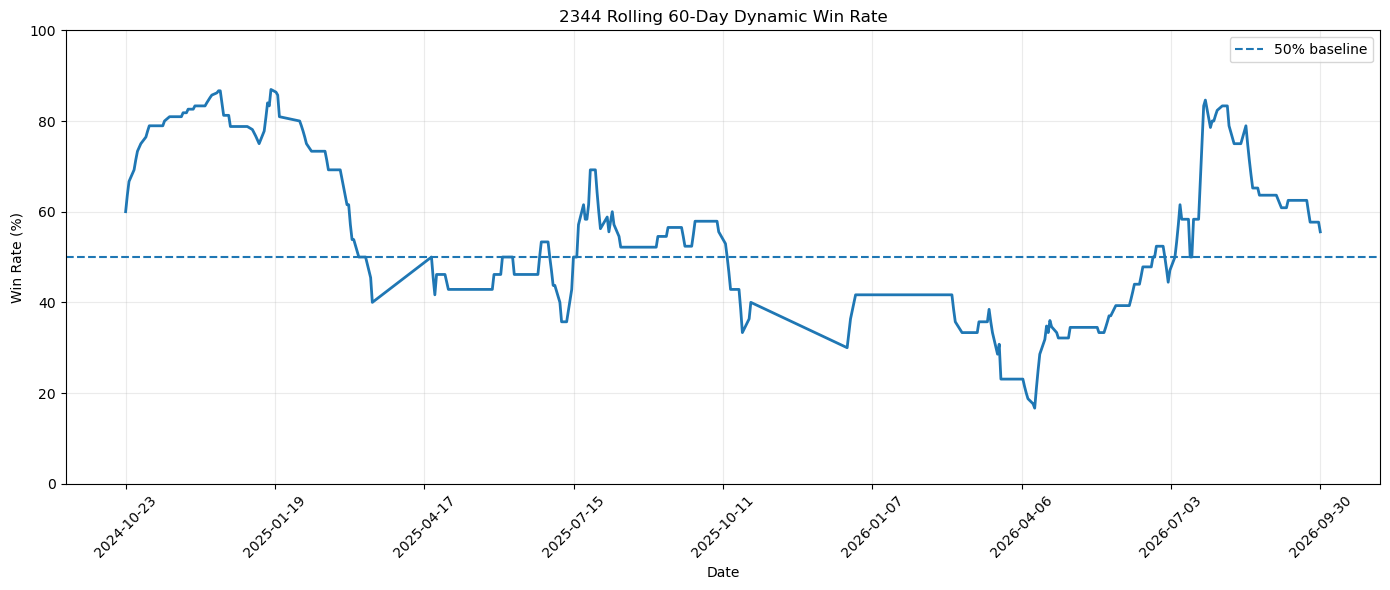

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# 複製動態回測結果
plot_df = df_dynamic.copy()

# 確保 index 真的是日期格式
plot_df.index = pd.to_datetime(plot_df.index)

# 去掉尚未產生動態勝率的資料
plot_df = plot_df[
    plot_df["dynamic_win_rate"].notna()
].copy()

# 以資料最後一個交易日為基準，往前抓兩年
end_date = plot_df.index.max()
start_date = end_date - pd.DateOffset(years=2)

plot_df = plot_df.loc[
    (plot_df.index >= start_date) &
    (plot_df.index <= end_date)
]

# 確認實際日期
print("圖表起始日期：", plot_df.index.min().date())
print("圖表結束日期：", plot_df.index.max().date())
print("資料筆數：", len(plot_df))

# 畫圖
plt.figure(figsize=(14, 6))

plt.plot(
    plot_df.index,
    plot_df["dynamic_win_rate"] * 100,
    linewidth=2
)

# 50% 基準線
plt.axhline(
    50,
    linestyle="--",
    linewidth=1.5,
    label="50% baseline"
)

plt.title("2344 Rolling 60-Day Dynamic Win Rate")
plt.xlabel("Date")
plt.ylabel("Win Rate (%)")

plt.ylim(0, 100)
plt.grid(alpha=0.25)
plt.legend()

# 日期直接由實際資料範圍產生
date_ticks = pd.date_range(
    start=plot_df.index.min(),
    end=plot_df.index.max(),
    periods=9
)

plt.xticks(
    date_ticks,
    [d.strftime("%Y-%m-%d") for d in date_ticks],
    rotation=45
)

plt.tight_layout()
plt.show()

## Feature 重選

### 技術面

In [31]:
%%writefile technical_features.py

import pandas as pd
import numpy as np
import yfinance as yf


TECHNICAL_FEATURES = [
    "return_1d",
    "return_5d",
    "high_low_range",
    "MA5_MA20_gap",
    "MA20_MA60_gap",
    "RSI",
    "MACD_hist",
    "BB_position",
    "volatility_5d",
    "volume_ratio_5",
    "volume_ratio_20",
    "TAIEX_return_1d",
    "TAIEX_return_5d",
    "relative_strength_5d"
]


def make_technical_features(df):

    df = df.copy()

    # =========================
    # 1. 價格
    # =========================

    df["return_1d"] = df["Close"].pct_change(1)

    df["return_5d"] = df["Close"].pct_change(5)

    df["high_low_range"] = (
        (df["High"] - df["Low"]) / df["Close"]
    )


    # =========================
    # 2. 趨勢
    # =========================

    df["MA5_MA20_gap"] = (
        df["MA5"] / df["MA20"] - 1
    )

    df["MA20_MA60_gap"] = (
        df["MA20"] / df["MA60"] - 1
    )


    # =========================
    # 3. 動能
    # =========================

    # RSI 已經由 backtest.py 計算

    df["MACD_hist"] = (
        df["MACD"] - df["MACD_signal"]
    )


    # =========================
    # 4. Bollinger Band
    # =========================

    bb_width = df["BB_high"] - df["BB_low"]

    df["BB_position"] = np.where(
        bb_width != 0,
        (df["Close"] - df["BB_low"]) / bb_width,
        np.nan
    )


    # =========================
    # 5. 波動
    # =========================

    df["volatility_5d"] = (
        df["return_1d"]
        .rolling(5)
        .std()
    )


    # =========================
    # 6. 成交量
    # =========================

    df["volume_ratio_5"] = (
        df["Volume"] / df["Volume_MA5"]
    )

    df["volume_ratio_20"] = (
        df["Volume"] / df["Volume_MA20"]
    )


    # =========================
    # 7. 大盤
    # =========================

    market = yf.download(
        "^TWII",
        start=df.index.min(),
        end=df.index.max() + pd.Timedelta(days=1),
        auto_adjust=True,
        progress=False
    )

    if isinstance(market.columns, pd.MultiIndex):
        market.columns = market.columns.get_level_values(0)

    market["TAIEX_return_1d"] = (
        market["Close"].pct_change(1)
    )

    market["TAIEX_return_5d"] = (
        market["Close"].pct_change(5)
    )

    df = df.join(
        market[
            [
                "TAIEX_return_1d",
                "TAIEX_return_5d"
            ]
        ],
        how="left"
    )


    # =========================
    # 8. 個股相對大盤強弱
    # =========================

    df["relative_strength_5d"] = (
        df["return_5d"]
        - df["TAIEX_return_5d"]
    )


    return df

Overwriting technical_features.py


In [32]:
import importlib
import technical_features

importlib.reload(technical_features)

df = backtest.rolling_backtest("2344")

df_technical = technical_features.make_technical_features(df)

In [33]:
df_technical[
    technical_features.TECHNICAL_FEATURES
].tail(10)

Price,return_1d,return_5d,high_low_range,MA5_MA20_gap,MA20_MA60_gap,RSI,MACD_hist,BB_position,volatility_5d,volume_ratio_5,volume_ratio_20,TAIEX_return_1d,TAIEX_return_5d,relative_strength_5d
2026-09-15,-0.003125,-0.151596,0.034483,-0.033546,0.020806,40.869520,-2.611555,-0.070596,0.024574,0.740885,0.541286,-0.007654,-0.033845,-0.117751
2026-09-16,0.059561,-0.076503,0.035503,-0.049667,0.024648,47.366636,-2.300606,0.242402,0.048222,0.989976,0.641210,0.007414,-0.028282,-0.048220
2026-09-17,0.005917,-0.052925,0.058824,-0.058690,0.027681,48.014160,-1.933663,0.290833,0.048963,1.290585,0.952567,0.009577,-0.013900,-0.039024
2026-09-18,0.055882,0.046647,0.033426,-0.049213,0.029944,53.825838,-1.004004,0.606779,0.051691,1.300339,1.082735,0.019287,0.021563,0.025084
2026-09-21,-0.030641,0.087500,0.034483,-0.032505,0.031982,50.318573,-0.725356,0.429771,0.039113,0.785117,0.605042,0.011405,0.040476,0.047024
2026-09-22,-0.017241,0.072100,0.058480,-0.017214,0.033322,48.463604,-0.708159,0.344843,0.041418,0.943955,0.766757,0.001704,0.050288,0.021812
2026-09-23,0.008772,0.020710,0.028986,-0.010697,0.032446,49.466696,-0.566942,0.407796,0.033045,0.704799,0.563487,0.007471,0.050348,-0.029638
2026-09-24,-0.005797,0.008824,0.029155,-0.004870,0.029389,48.784975,-0.513646,0.393278,0.033337,0.583355,0.416346,-0.002755,0.037517,-0.028694
2026-09-29,0.014577,-0.030641,0.045977,-0.009043,0.028238,50.617261,-0.293720,0.493718,0.018542,0.672410,0.395235,-0.008176,0.009563,-0.040204
2026-09-30,0.014368,0.014368,0.016997,-0.004457,0.027124,52.449312,0.019788,0.597588,0.013997,0.575320,0.342249,0.015444,0.013595,0.000773


### 基本面  (短線先不用)

In [34]:
%%writefile fundamental_data.py

import requests
import pandas as pd


def get_monthly_revenue(symbol):

    url = "https://openapi.twse.com.tw/v1/opendata/t187ap05_L"

    response = requests.get(
        url,
        timeout=20
    )

    response.raise_for_status()

    data = response.json()

    df = pd.DataFrame(data)

    # 找指定股票
    result = df[
        df["公司代號"].astype(str).str.strip()
        == str(symbol)
    ].copy()

    if result.empty:
        return None

    return result

Overwriting fundamental_data.py


In [35]:
import importlib
import fundamental_data

importlib.reload(fundamental_data)

<module 'fundamental_data' from 'C:\\Users\\User\\Desktop\\nschool 專案\\第二次專案\\fundamental_data.py'>

In [36]:
revenue = fundamental_data.get_monthly_revenue("2344")

revenue

,出表日期,資料年月,公司代號,公司名稱,產業別,營業收入-當月營收,營業收入-上月營收,營業收入-去年當月營收,營業收入-上月比較增減(%),營業收入-去年同月增減(%),累計營業收入-當月累計營收,累計營業收入-去年累計營收,累計營業收入-前期比較增減(%),備註
287,1150917,11508,2344,華邦電,半導體業,27308717,26773179,7012528,2.000277964749722,289.42756449599915,152178225,54860887,177.3892901148317,受市場供需影響。


In [37]:
row = revenue.iloc[0]

revenue_feature = {
    "report_date": row["出表日期"],
    "year_month": row["資料年月"],
    "revenue_mom": float(row["營業收入-上月比較增減(%)"]),
    "revenue_yoy": float(row["營業收入-去年同月增減(%)"])
}

revenue_feature

{'report_date': '1150917',
 'year_month': '11508',
 'revenue_mom': 2.000277964749722,
 'revenue_yoy': 289.42756449599915}

In [38]:
import requests
import pandas as pd

url = "https://mops.twse.com.tw/mops/api/t05st10_ifrs"

payload = {
    "year": "115",
    "month": "08",
    "TYPEK": "sii",
    "step": "1"
}

headers = {
    "User-Agent": "Mozilla/5.0",
    "Referer": "https://mops.twse.com.tw/"
}

r = requests.post(
    url,
    data=payload,
    headers=headers,
    timeout=20
)

print("status:", r.status_code)
print(r.text[:500])

status: 200
{"code":406,"message":"查無相符資料","result":null,"datetime":"115/09/30 10:30:22"}


### 籌碼面

In [39]:
%%writefile chip_data.py

import requests
import pandas as pd


def get_chip_data(date, symbol):

    url = "https://www.twse.com.tw/rwd/zh/fund/T86"

    params = {
        "date": date,
        "selectType": "ALLBUT0999",
        "response": "json"
    }

    r = requests.get(
        url,
        params=params,
        timeout=20
    )

    r.raise_for_status()

    data = r.json()

    if "data" not in data or len(data["data"]) == 0:
        return None

    df = pd.DataFrame(
        data["data"],
        columns=data["fields"]
    )

    # 清理股票代號
    df["證券代號"] = (
        df["證券代號"]
        .astype(str)
        .str.strip()
    )

    # 找指定股票
    stock = df[
        df["證券代號"] == str(symbol)
    ]

    if stock.empty:
        return None

    return stock

Overwriting chip_data.py


In [40]:
import importlib
import chip_data

importlib.reload(chip_data)

<module 'chip_data' from 'C:\\Users\\User\\Desktop\\nschool 專案\\第二次專案\\chip_data.py'>

In [41]:
test = chip_data.get_chip_data(
    "20260918",
    "2344"
)

test

,證券代號,證券名稱,外陸資買進股數(不含外資自營商),外陸資賣出股數(不含外資自營商),外陸資買賣超股數(不含外資自營商),外資自營商買進股數,外資自營商賣出股數,外資自營商買賣超股數,投信買進股數,投信賣出股數,投信買賣超股數,自營商買賣超股數,自營商買進股數(自行買賣),自營商賣出股數(自行買賣),自營商買賣超股數(自行買賣),自營商買進股數(避險),自營商賣出股數(避險),自營商買賣超股數(避險),三大法人買賣超股數
6,2344,華邦電,"76,481,124","33,706,892","42,774,232",0,0,0,"254,114","463,000","-208,886","3,489,976","3,547,583","526,415","3,021,168","596,249","127,441","468,808","46,055,322"


In [42]:
row = test.iloc[0]

foreign_net = int(
    str(row["外陸資買賣超股數(不含外資自營商)"])
    .replace(",", "")
)

trust_net = int(
    str(row["投信買賣超股數"])
    .replace(",", "")
)

institution_net = int(
    str(row["三大法人買賣超股數"])
    .replace(",", "")
)

print("外資買賣超：", foreign_net)
print("投信買賣超：", trust_net)
print("三大法人買賣超：", institution_net)

外資買賣超： 42774232
投信買賣超： -208886
三大法人買賣超： 46055322


In [43]:
import pandas as pd
import time

dates = df_technical.tail(10).index

rows = []

for date in dates:

    date_str = pd.to_datetime(date).strftime("%Y%m%d")

    test = chip_data.get_chip_data(
        date_str,
        "2344"
    )

    if test is not None:

        row = test.iloc[0]

        foreign_net = int(
            str(row["外陸資買賣超股數(不含外資自營商)"])
            .replace(",", "")
        )

        trust_net = int(
            str(row["投信買賣超股數"])
            .replace(",", "")
        )

        institution_net = int(
            str(row["三大法人買賣超股數"])
            .replace(",", "")
        )

        rows.append({
            "Date": pd.to_datetime(date),
            "foreign_net": foreign_net,
            "trust_net": trust_net,
            "institution_net": institution_net
        })

    time.sleep(0.5)


chip_history = pd.DataFrame(rows)

chip_history

,Date,foreign_net,trust_net,institution_net
0,2026-09-15,-4095284,-5474000,-8531557
1,2026-09-16,18474026,177000,20912043
2,2026-09-17,-10245462,-51000,-9238479
3,2026-09-18,42774232,-208886,46055322
4,2026-09-21,-23211982,-855220,-25301315
5,2026-09-22,7783688,-15494573,-8053564
6,2026-09-23,10124159,-3272000,6946172
7,2026-09-24,-17824356,-162001,-17995000
8,2026-09-29,7390748,-2002000,6055992


In [44]:
chip_history = chip_history.set_index("Date")

chip_history = chip_history.join(
    df_technical[["Volume"]],
    how="left"
)

chip_history[
    ["foreign_net", "trust_net", "institution_net", "Volume"]
]

,foreign_net,trust_net,institution_net,Volume
Date,,,,
2026-09-15,-4095284,-5474000,-8531557,68960432
2026-09-16,18474026,177000,20912043,80794263
2026-09-17,-10245462,-51000,-9238479,118596329
2026-09-18,42774232,-208886,46055322,136049588
2026-09-21,-23211982,-855220,-25301315,75328732
2026-09-22,7783688,-15494573,-8053564,95597411
2026-09-23,10124159,-3272000,6946172,69832023
2026-09-24,-17824356,-162001,-17995000,49769170
2026-09-29,7390748,-2002000,6055992,45141385


In [45]:
chip_history["foreign_net_ratio"] = (
    chip_history["foreign_net"] / chip_history["Volume"]
)

chip_history["trust_net_ratio"] = (
    chip_history["trust_net"] / chip_history["Volume"]
)

chip_history["institution_net_ratio"] = (
    chip_history["institution_net"] / chip_history["Volume"]
)

chip_history[[
    "foreign_net_ratio",
    "trust_net_ratio",
    "institution_net_ratio"
]]

,foreign_net_ratio,trust_net_ratio,institution_net_ratio
Date,,,
2026-09-15,-0.059386,-0.079379,-0.123717
2026-09-16,0.228655,0.002191,0.258831
2026-09-17,-0.086389,-0.000430,-0.077899
2026-09-18,0.314402,-0.001535,0.338519
2026-09-21,-0.308142,-0.011353,-0.335879
2026-09-22,0.081422,-0.162082,-0.084245
2026-09-23,0.144979,-0.046855,0.099470
2026-09-24,-0.358141,-0.003255,-0.361569
2026-09-29,0.163724,-0.044350,0.134156


In [46]:
volume_5d = chip_history["Volume"].rolling(5).sum()

chip_history["foreign_net_ratio_5d"] = (
    chip_history["foreign_net"].rolling(5).sum()
    / volume_5d
)

chip_history["trust_net_ratio_5d"] = (
    chip_history["trust_net"].rolling(5).sum()
    / volume_5d
)

chip_history["institution_net_ratio_5d"] = (
    chip_history["institution_net"].rolling(5).sum()
    / volume_5d
)

In [47]:
chip_features = [
    "foreign_net_ratio",
    "trust_net_ratio",
    "institution_net_ratio",
    "foreign_net_ratio_5d",
    "trust_net_ratio_5d",
    "institution_net_ratio_5d"
]

chip_history[chip_features]

,foreign_net_ratio,trust_net_ratio,institution_net_ratio,foreign_net_ratio_5d,trust_net_ratio_5d,institution_net_ratio_5d
Date,,,,,,
2026-09-15,-0.059386,-0.079379,-0.123717,NaN,NaN,NaN
2026-09-16,0.228655,0.002191,0.258831,NaN,NaN,NaN
2026-09-17,-0.086389,-0.000430,-0.077899,NaN,NaN,NaN
2026-09-18,0.314402,-0.001535,0.338519,NaN,NaN,NaN
2026-09-21,-0.308142,-0.011353,-0.335879,0.049394,-0.013366,0.049811
2026-09-22,0.081422,-0.162082,-0.084245,0.070254,-0.032452,0.048135
2026-09-23,0.144979,-0.046855,0.099470,0.054954,-0.040132,0.021009
2026-09-24,-0.358141,-0.003255,-0.361569,0.046054,-0.046868,0.003872
2026-09-29,0.163724,-0.044350,0.134156,-0.046885,-0.064903,-0.114243


In [48]:
%%writefile chip_data.py

import os
import time
import random
import requests
import pandas as pd


CHIP_FEATURES = [
    "foreign_net_ratio",
    "trust_net_ratio",
    "institution_net_ratio",
    "foreign_net_ratio_5d",
    "trust_net_ratio_5d",
    "institution_net_ratio_5d"
]


def _to_number(value):
    return pd.to_numeric(
        str(value).replace(",", ""),
        errors="coerce"
    )


# =========================================================
# 抓單日法人資料
# =========================================================
def get_chip_data(date, symbol, max_retries=3):

    url = "https://www.twse.com.tw/rwd/zh/fund/T86"

    params = {
        "date": date,
        "selectType": "ALLBUT0999",
        "response": "json"
    }

    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 Chrome/120 Safari/537.36"
        )
    }

    for attempt in range(max_retries):

        try:
            r = requests.get(
                url,
                params=params,
                headers=headers,
                timeout=30
            )

            # 被限制時先休息
            if r.status_code in [428, 429]:
                wait = 10 * (attempt + 1)
                print(f"{date} 被限制，等待 {wait} 秒...")
                time.sleep(wait)
                continue

            r.raise_for_status()

            data = r.json()

            if "data" not in data or len(data["data"]) == 0:
                return None

            df = pd.DataFrame(
                data["data"],
                columns=data["fields"]
            )

            df["證券代號"] = (
                df["證券代號"]
                .astype(str)
                .str.strip()
            )

            stock = df[
                df["證券代號"] == str(symbol)
            ]

            if stock.empty:
                return None

            return stock

        except Exception as e:

            if attempt == max_retries - 1:
                print(date, "抓取失敗:", e)
                return None

            wait = 5 * (attempt + 1)
            time.sleep(wait)

    return None


# =========================================================
# 抓歷史資料 + 自動存檔 + 可續抓
# =========================================================
def get_chip_history(
    df,
    symbol,
    save_file="chip_history.csv",
    sleep_seconds=1.5
):

    # -----------------------------------------------------
    # 讀取之前已經抓好的資料
    # -----------------------------------------------------
    if os.path.exists(save_file):

        chip_history = pd.read_csv(
            save_file,
            index_col="Date",
            parse_dates=True
        )

        chip_history.index = pd.to_datetime(
            chip_history.index
        )

        print(
            f"已讀取 {len(chip_history)} 筆舊資料"
        )

    else:

        chip_history = pd.DataFrame(
            columns=[
                "foreign_net",
                "trust_net",
                "institution_net"
            ]
        )

        chip_history.index.name = "Date"


    # -----------------------------------------------------
    # 找出還沒有抓過的日期
    # -----------------------------------------------------
    existing_dates = set(
        pd.to_datetime(chip_history.index).normalize()
    )

    dates_to_fetch = [
        pd.Timestamp(date)
        for date in df.index
        if pd.Timestamp(date).normalize()
        not in existing_dates
    ]

    print(
        "需要新增：",
        len(dates_to_fetch),
        "個交易日"
    )


    # -----------------------------------------------------
    # 開始抓
    # -----------------------------------------------------
    for i, date in enumerate(
        dates_to_fetch,
        start=1
    ):

        date_str = date.strftime("%Y%m%d")

        stock = get_chip_data(
            date_str,
            symbol
        )

        if stock is not None:

            row = stock.iloc[0]

            chip_history.loc[
                date,
                "foreign_net"
            ] = _to_number(
                row[
                    "外陸資買賣超股數(不含外資自營商)"
                ]
            )

            chip_history.loc[
                date,
                "trust_net"
            ] = _to_number(
                row["投信買賣超股數"]
            )

            chip_history.loc[
                date,
                "institution_net"
            ] = _to_number(
                row["三大法人買賣超股數"]
            )


        # -------------------------------------------------
        # 每 20 筆存一次
        # -------------------------------------------------
        if i % 20 == 0:

            chip_history.sort_index(
                inplace=True
            )

            chip_history.to_csv(
                save_file
            )

            print(
                f"進度：{i}/{len(dates_to_fetch)} "
                f"｜目前共 {len(chip_history)} 筆"
            )


        # 每次不要打太快
        time.sleep(
            sleep_seconds
            + random.uniform(0, 0.5)
        )


    # -----------------------------------------------------
    # 最後再存一次
    # -----------------------------------------------------
    chip_history.sort_index(
        inplace=True
    )

    chip_history.to_csv(
        save_file
    )


    # -----------------------------------------------------
    # 加入成交量
    # -----------------------------------------------------
    chip_history = (
        chip_history
        .drop(columns=["Volume"], errors="ignore")
        .join(
            df[["Volume"]],
            how="left"
        )
    )

    numeric_columns = [
        "foreign_net",
        "trust_net",
        "institution_net",
        "Volume"
    ]

    chip_history[numeric_columns] = (
        chip_history[numeric_columns]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
    )


    # -----------------------------------------------------
    # 單日比例
    # -----------------------------------------------------
    chip_history["foreign_net_ratio"] = (
        chip_history["foreign_net"]
        / chip_history["Volume"]
    )

    chip_history["trust_net_ratio"] = (
        chip_history["trust_net"]
        / chip_history["Volume"]
    )

    chip_history["institution_net_ratio"] = (
        chip_history["institution_net"]
        / chip_history["Volume"]
    )


    # -----------------------------------------------------
    # 五日累積比例
    # 這裡維持你原本的算法
    # -----------------------------------------------------
    volume_5d = (
        chip_history["Volume"]
        .rolling(5)
        .sum()
    )

    chip_history["foreign_net_ratio_5d"] = (
        chip_history["foreign_net"]
        .rolling(5)
        .sum()
        / volume_5d
    )

    chip_history["trust_net_ratio_5d"] = (
        chip_history["trust_net"]
        .rolling(5)
        .sum()
        / volume_5d
    )

    chip_history["institution_net_ratio_5d"] = (
        chip_history["institution_net"]
        .rolling(5)
        .sum()
        / volume_5d
    )

    return chip_history

Overwriting chip_data.py


In [49]:
import importlib
import chip_data

importlib.reload(chip_data)

<module 'chip_data' from 'C:\\Users\\User\\Desktop\\nschool 專案\\第二次專案\\chip_data.py'>

In [50]:
df_2y = df_technical[
    df_technical.index >=
    df_technical.index.max() - pd.DateOffset(years=2)
].copy()

print("交易日數：", len(df_2y))
print(
    "日期：",
    df_2y.index.min(),
    "→",
    df_2y.index.max()
)

交易日數： 485
日期： 2024-09-30 00:00:00 → 2026-09-30 00:00:00


In [51]:
import requests
import pandas as pd

url = "https://api.finmindtrade.com/api/v4/data"

params = {
    "dataset": "TaiwanStockInstitutionalInvestorsBuySellWide",
    "data_id": "2344",
    "start_date": "2024-09-01",
    "end_date": "2026-09-20"
}

response = requests.get(
    url,
    params=params,
    timeout=30
)

data = response.json()

print("status:", data.get("status"))
print("msg:", data.get("msg"))

chip_raw = pd.DataFrame(data.get("data", []))

print("資料筆數：", len(chip_raw))
chip_raw.head()

status: 200
msg: success
資料筆數： 498


,date,stock_id,Foreign_Investor_buy,Foreign_Investor_sell,Foreign_Dealer_Self_buy,Foreign_Dealer_Self_sell,Investment_Trust_buy,Investment_Trust_sell,Dealer_buy,Dealer_sell,Dealer_self_buy,Dealer_self_sell,Dealer_Hedging_buy,Dealer_Hedging_sell
0,2024-09-02,2344,1563291,8177540,0,0,0,174,0,0,110000,216000,41000,1104650
1,2024-09-03,2344,1644400,9123221,0,0,18000,0,0,0,4000,66444,107000,406071
2,2024-09-04,2344,15478748,28122863,0,0,11000,0,0,0,112000,524138,81000,1011222
3,2024-09-05,2344,2703318,18826353,0,0,16000,22174,0,0,86000,508086,85000,292901
4,2024-09-06,2344,8441000,14426000,0,0,31107,5087,0,0,210000,256589,19000,186372


In [52]:
print(chip_raw.columns.tolist())

['date', 'stock_id', 'Foreign_Investor_buy', 'Foreign_Investor_sell', 'Foreign_Dealer_Self_buy', 'Foreign_Dealer_Self_sell', 'Investment_Trust_buy', 'Investment_Trust_sell', 'Dealer_buy', 'Dealer_sell', 'Dealer_self_buy', 'Dealer_self_sell', 'Dealer_Hedging_buy', 'Dealer_Hedging_sell']


In [53]:
chip_raw.head()

,date,stock_id,Foreign_Investor_buy,Foreign_Investor_sell,Foreign_Dealer_Self_buy,Foreign_Dealer_Self_sell,Investment_Trust_buy,Investment_Trust_sell,Dealer_buy,Dealer_sell,Dealer_self_buy,Dealer_self_sell,Dealer_Hedging_buy,Dealer_Hedging_sell
0,2024-09-02,2344,1563291,8177540,0,0,0,174,0,0,110000,216000,41000,1104650
1,2024-09-03,2344,1644400,9123221,0,0,18000,0,0,0,4000,66444,107000,406071
2,2024-09-04,2344,15478748,28122863,0,0,11000,0,0,0,112000,524138,81000,1011222
3,2024-09-05,2344,2703318,18826353,0,0,16000,22174,0,0,86000,508086,85000,292901
4,2024-09-06,2344,8441000,14426000,0,0,31107,5087,0,0,210000,256589,19000,186372


In [54]:
# 日期轉換
chip_history = chip_raw.copy()

chip_history["date"] = pd.to_datetime(
    chip_history["date"]
)

chip_history = (
    chip_history
    .set_index("date")
    .sort_index()
)


# ==============================
# 外資買賣超
# ==============================

chip_history["foreign_net"] = (
    chip_history["Foreign_Investor_buy"]
    - chip_history["Foreign_Investor_sell"]
)


# ==============================
# 投信買賣超
# ==============================

chip_history["trust_net"] = (
    chip_history["Investment_Trust_buy"]
    - chip_history["Investment_Trust_sell"]
)


# ==============================
# 自營商買賣超
# ==============================

dealer_net = (
    chip_history["Dealer_buy"]
    - chip_history["Dealer_sell"]
)


# ==============================
# 三大法人合計
# ==============================

chip_history["institution_net"] = (
    chip_history["foreign_net"]
    + chip_history["trust_net"]
    + dealer_net
)


# 看結果
chip_history[
    [
        "foreign_net",
        "trust_net",
        "institution_net"
    ]
].head(10)

,foreign_net,trust_net,institution_net
date,,,
2024-09-02,-6614249,-174,-6614423
2024-09-03,-7478821,18000,-7460821
2024-09-04,-12644115,11000,-12633115
2024-09-05,-16123035,-6174,-16129209
2024-09-06,-5985000,26020,-5958980
2024-09-09,-2356336,-174,-2356510
2024-09-10,-8645772,415826,-8229946
2024-09-11,-242447,26000,-216447
2024-09-12,-1415616,4826,-1410790


In [55]:
# 把股價資料的 Volume 接進來
chip_history = chip_history.join(
    df_technical[["Volume"]],
    how="left"
)

# 單日法人買賣超比例
chip_history["foreign_net_ratio"] = (
    chip_history["foreign_net"] / chip_history["Volume"]
)

chip_history["trust_net_ratio"] = (
    chip_history["trust_net"] / chip_history["Volume"]
)

chip_history["institution_net_ratio"] = (
    chip_history["institution_net"] / chip_history["Volume"]
)


# 5日累積成交量
volume_5d = chip_history["Volume"].rolling(5).sum()

# 5日法人買賣超比例
chip_history["foreign_net_ratio_5d"] = (
    chip_history["foreign_net"].rolling(5).sum()
    / volume_5d
)

chip_history["trust_net_ratio_5d"] = (
    chip_history["trust_net"].rolling(5).sum()
    / volume_5d
)

chip_history["institution_net_ratio_5d"] = (
    chip_history["institution_net"].rolling(5).sum()
    / volume_5d
)

In [56]:
chip_features = [
    "foreign_net_ratio",
    "trust_net_ratio",
    "institution_net_ratio",
    "foreign_net_ratio_5d",
    "trust_net_ratio_5d",
    "institution_net_ratio_5d"
]

print("資料筆數：", len(chip_history))

chip_history[chip_features].tail(10)

資料筆數： 498


,foreign_net_ratio,trust_net_ratio,institution_net_ratio,foreign_net_ratio_5d,trust_net_ratio_5d,institution_net_ratio_5d
date,,,,,,
2026-09-07,0.405668,-0.011643,0.394026,-0.025992,-0.029275,-0.055267
2026-09-08,0.425083,0.018013,0.443095,0.197824,-0.010269,0.187554
2026-09-09,-0.419841,-0.003042,-0.422883,0.082994,-0.006435,0.076559
2026-09-10,-0.083174,-0.010538,-0.093712,0.127854,-0.008567,0.119287
2026-09-11,-0.430716,-0.021789,-0.452505,0.073859,-0.000231,0.073627
2026-09-14,-0.355989,-0.069089,-0.425078,-0.072324,-0.011371,-0.083695
2026-09-15,-0.059386,-0.079379,-0.138765,-0.303225,-0.035201,-0.338427
2026-09-16,0.228655,0.002191,0.230846,-0.158442,-0.038684,-0.197126
2026-09-17,-0.086389,-0.000430,-0.086819,-0.150851,-0.032926,-0.183777


### 合併 (技+籌)

In [57]:
df_model = df_technical.join(
    chip_history[chip_features],
    how="inner"
)

print("合併後資料筆數：", len(df_model))
print(
    "日期範圍：",
    df_model.index.min(),
    "→",
    df_model.index.max()
)

df_model.tail()

合併後資料筆數： 478
日期範圍： 2024-09-30 00:00:00 → 2026-09-18 00:00:00


,Close,High,Low,Open,Volume,RSI,MACD,MACD_signal,MACD_hist,BB_high,...,volume_ratio_20,TAIEX_return_1d,TAIEX_return_5d,relative_strength_5d,foreign_net_ratio,trust_net_ratio,institution_net_ratio,foreign_net_ratio_5d,trust_net_ratio_5d,institution_net_ratio_5d
2026-09-14,160.0,167.5,160.0,166.5,118730444,41.117575,0.635247,2.585323,-1.950076,190.267478,...,0.892567,-0.006979,-0.030929,-0.080182,-0.355989,-0.069089,-0.425078,-0.072324,-0.011371,-0.083695
2026-09-15,159.5,164.0,158.5,162.5,68960432,40.869520,-0.679121,1.932434,-2.611555,191.631249,...,0.541286,-0.007654,-0.033845,-0.117751,-0.059386,-0.079379,-0.138765,-0.303225,-0.035201,-0.338427
2026-09-16,169.0,169.5,163.5,163.5,80794263,47.366636,-0.943323,1.357283,-2.300606,191.572231,...,0.641210,0.007414,-0.028282,-0.048220,0.228655,0.002191,0.230846,-0.158442,-0.038684,-0.197126
2026-09-17,170.0,180.0,170.0,177.0,118596329,48.014160,-1.059796,0.873867,-1.933663,191.529262,...,0.952567,0.009577,-0.013900,-0.039024,-0.086389,-0.000430,-0.086819,-0.150851,-0.032926,-0.183777
2026-09-18,179.5,179.5,173.5,177.0,136049588,53.825838,-0.381138,0.622866,-1.004004,191.376242,...,1.082735,0.019287,0.021563,0.025084,0.314402,-0.001535,0.312866,0.008871,-0.026303,-0.017432


In [58]:
FEATURES = (
    technical_features.TECHNICAL_FEATURES
    + chip_data.CHIP_FEATURES
)

print("Feature 數量：", len(FEATURES))

df_model[FEATURES].tail(10)

Feature 數量： 20


,return_1d,return_5d,high_low_range,MA5_MA20_gap,MA20_MA60_gap,RSI,MACD_hist,BB_position,volatility_5d,volume_ratio_5,volume_ratio_20,TAIEX_return_1d,TAIEX_return_5d,relative_strength_5d,foreign_net_ratio,trust_net_ratio,institution_net_ratio,foreign_net_ratio_5d,trust_net_ratio_5d,institution_net_ratio_5d
2026-09-07,0.034483,-0.013699,0.030556,-0.014729,0.011014,53.732524,-0.757514,0.602653,0.040997,0.990001,0.770284,0.016651,0.025967,-0.039665,0.405668,-0.011643,0.394026,-0.025992,-0.029275,-0.055267
2026-09-08,0.044444,0.068182,0.045213,-0.004057,0.013947,58.116777,-0.058521,0.981281,0.040249,1.614016,1.424941,-0.004659,0.003345,0.064836,0.425083,0.018013,0.443095,0.197824,-0.010269,0.187554
2026-09-09,-0.026596,0.022346,0.054645,-0.001257,0.016995,54.632328,0.033391,0.703328,0.043967,0.945661,0.923751,0.001647,0.022065,0.000281,-0.419841,-0.003042,-0.422883,0.082994,-0.006435,0.076559
2026-09-10,-0.019126,0.062130,0.025070,0.009768,0.019587,52.269855,-0.164371,0.517982,0.032880,0.525361,0.474497,-0.005147,0.023613,0.038517,-0.083174,-0.010538,-0.093712,0.127854,-0.008567,0.119287
2026-09-11,-0.044568,-0.014368,0.017493,0.010361,0.020723,47.241276,-0.820132,0.149579,0.039364,0.591053,0.542422,-0.016098,-0.007868,-0.006500,-0.430716,-0.021789,-0.452505,0.073859,-0.000231,0.073627
2026-09-14,-0.067055,-0.111111,0.046875,-0.006057,0.020607,41.117575,-1.950076,-0.183019,0.041779,0.966443,0.892567,-0.006979,-0.030929,-0.080182,-0.355989,-0.069089,-0.425078,-0.072324,-0.011371,-0.083695
2026-09-15,-0.003125,-0.151596,0.034483,-0.033546,0.020806,40.869520,-2.611555,-0.070596,0.024574,0.740885,0.541286,-0.007654,-0.033845,-0.117751,-0.059386,-0.079379,-0.138765,-0.303225,-0.035201,-0.338427
2026-09-16,0.059561,-0.076503,0.035503,-0.049667,0.024648,47.366636,-2.300606,0.242402,0.048222,0.989976,0.641210,0.007414,-0.028282,-0.048220,0.228655,0.002191,0.230846,-0.158442,-0.038684,-0.197126
2026-09-17,0.005917,-0.052925,0.058824,-0.058690,0.027681,48.014160,-1.933663,0.290833,0.048963,1.290585,0.952567,0.009577,-0.013900,-0.039024,-0.086389,-0.000430,-0.086819,-0.150851,-0.032926,-0.183777
2026-09-18,0.055882,0.046647,0.033426,-0.049213,0.029944,53.825838,-1.004004,0.606779,0.051691,1.300339,1.082735,0.019287,0.021563,0.025084,0.314402,-0.001535,0.312866,0.008871,-0.026303,-0.017432


## 資料處裡

In [59]:
print("Feature 數量：", len(FEATURES))
df_model[FEATURES].tail(10)

Feature 數量： 20


,return_1d,return_5d,high_low_range,MA5_MA20_gap,MA20_MA60_gap,RSI,MACD_hist,BB_position,volatility_5d,volume_ratio_5,volume_ratio_20,TAIEX_return_1d,TAIEX_return_5d,relative_strength_5d,foreign_net_ratio,trust_net_ratio,institution_net_ratio,foreign_net_ratio_5d,trust_net_ratio_5d,institution_net_ratio_5d
2026-09-07,0.034483,-0.013699,0.030556,-0.014729,0.011014,53.732524,-0.757514,0.602653,0.040997,0.990001,0.770284,0.016651,0.025967,-0.039665,0.405668,-0.011643,0.394026,-0.025992,-0.029275,-0.055267
2026-09-08,0.044444,0.068182,0.045213,-0.004057,0.013947,58.116777,-0.058521,0.981281,0.040249,1.614016,1.424941,-0.004659,0.003345,0.064836,0.425083,0.018013,0.443095,0.197824,-0.010269,0.187554
2026-09-09,-0.026596,0.022346,0.054645,-0.001257,0.016995,54.632328,0.033391,0.703328,0.043967,0.945661,0.923751,0.001647,0.022065,0.000281,-0.419841,-0.003042,-0.422883,0.082994,-0.006435,0.076559
2026-09-10,-0.019126,0.062130,0.025070,0.009768,0.019587,52.269855,-0.164371,0.517982,0.032880,0.525361,0.474497,-0.005147,0.023613,0.038517,-0.083174,-0.010538,-0.093712,0.127854,-0.008567,0.119287
2026-09-11,-0.044568,-0.014368,0.017493,0.010361,0.020723,47.241276,-0.820132,0.149579,0.039364,0.591053,0.542422,-0.016098,-0.007868,-0.006500,-0.430716,-0.021789,-0.452505,0.073859,-0.000231,0.073627
2026-09-14,-0.067055,-0.111111,0.046875,-0.006057,0.020607,41.117575,-1.950076,-0.183019,0.041779,0.966443,0.892567,-0.006979,-0.030929,-0.080182,-0.355989,-0.069089,-0.425078,-0.072324,-0.011371,-0.083695
2026-09-15,-0.003125,-0.151596,0.034483,-0.033546,0.020806,40.869520,-2.611555,-0.070596,0.024574,0.740885,0.541286,-0.007654,-0.033845,-0.117751,-0.059386,-0.079379,-0.138765,-0.303225,-0.035201,-0.338427
2026-09-16,0.059561,-0.076503,0.035503,-0.049667,0.024648,47.366636,-2.300606,0.242402,0.048222,0.989976,0.641210,0.007414,-0.028282,-0.048220,0.228655,0.002191,0.230846,-0.158442,-0.038684,-0.197126
2026-09-17,0.005917,-0.052925,0.058824,-0.058690,0.027681,48.014160,-1.933663,0.290833,0.048963,1.290585,0.952567,0.009577,-0.013900,-0.039024,-0.086389,-0.000430,-0.086819,-0.150851,-0.032926,-0.183777
2026-09-18,0.055882,0.046647,0.033426,-0.049213,0.029944,53.825838,-1.004004,0.606779,0.051691,1.300339,1.082735,0.019287,0.021563,0.025084,0.314402,-0.001535,0.312866,0.008871,-0.026303,-0.017432


### target Y預測五個交易日後漲跌 =>1:漲,0:跌

In [60]:
import numpy as np

model_data = df_model[
    FEATURES + ["future_return_5d"]
].copy()

# inf 轉成 NaN
model_data = model_data.replace(
    [np.inf, -np.inf],
    np.nan
)

# 先刪除缺失值
model_data = model_data.dropna()

# Target：未來5日上漲 = 1，否則 = 0
model_data["target"] = (
    model_data["future_return_5d"] > 0
).astype(int)

In [61]:
print("最終資料筆數：", len(model_data))
print("Feature 數量：", len(FEATURES))

print(
    "日期範圍：",
    model_data.index.min(),
    "→",
    model_data.index.max()
)

print("\nTarget 分布：")
print(model_data["target"].value_counts())

print(
    "\n上漲比例：",
    model_data["target"].mean()
)

最終資料筆數： 415
Feature 數量： 20
日期範圍： 2024-12-26 00:00:00 → 2026-09-18 00:00:00

Target 分布：
target
1    235
0    180
Name: count, dtype: int64

上漲比例： 0.5662650602409639


In [62]:
# ============================================================
# Step 10：建立 Strong Long / Strong Short Target
# ============================================================

STRONG_THRESHOLD = 0.03

# 強多：未來 5 日報酬 >= +3%
model_data["target_long"] = (
    model_data["future_return_5d"] >= STRONG_THRESHOLD
).astype(int)

# 強空：未來 5 日報酬 <= -3%
model_data["target_short"] = (
    model_data["future_return_5d"] <= -STRONG_THRESHOLD
).astype(int)

# 三狀態標籤
model_data["signal_target"] = "NEUTRAL"

model_data.loc[
    model_data["target_long"] == 1,
    "signal_target"
] = "STRONG_LONG"

model_data.loc[
    model_data["target_short"] == 1,
    "signal_target"
] = "STRONG_SHORT"


print("Signal Target：")
print(model_data["signal_target"].value_counts())

print("\nLong Target：")
print(model_data["target_long"].value_counts())

print("\nShort Target：")
print(model_data["target_short"].value_counts())

Signal Target：
signal_target
STRONG_LONG     181
STRONG_SHORT    120
NEUTRAL         114
Name: count, dtype: int64

Long Target：
target_long
0    234
1    181
Name: count, dtype: int64

Short Target：
target_short
0    295
1    120
Name: count, dtype: int64


## Heatmap + 資料清理

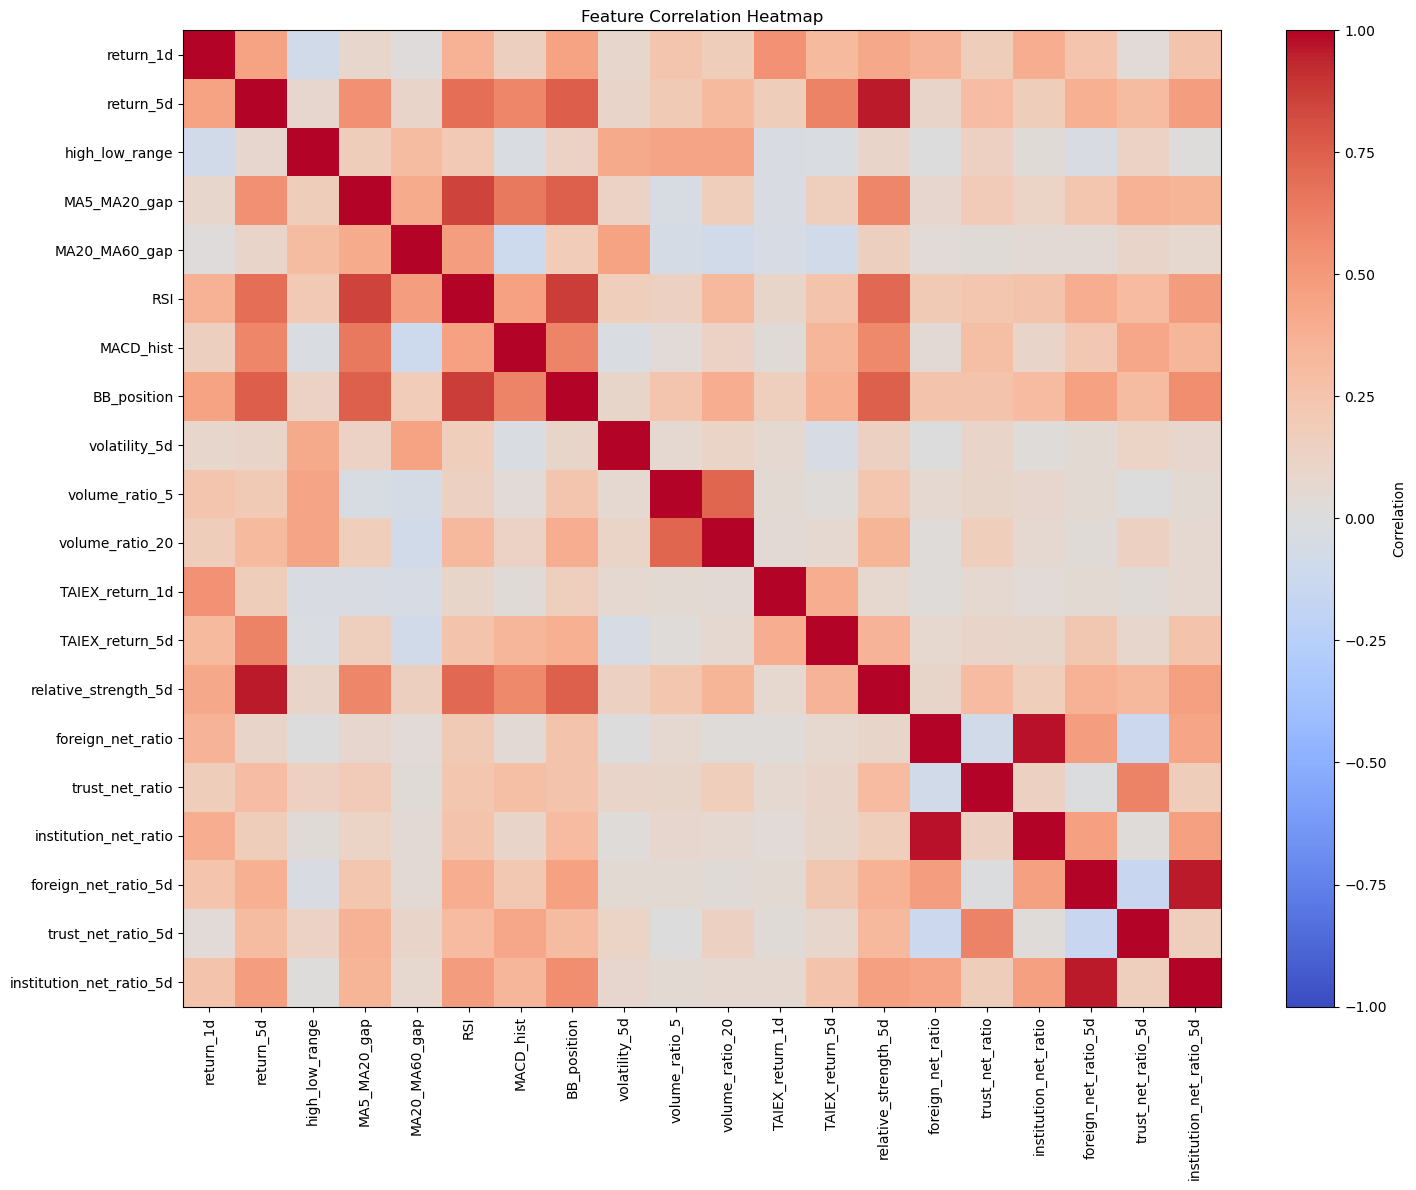

In [63]:
import matplotlib.pyplot as plt

X = model_data[FEATURES].copy()
y = model_data["target"].copy()

corr = X.corr()

plt.figure(figsize=(15, 12))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(range(len(X.columns)), X.columns, rotation=90)
plt.yticks(range(len(X.columns)), X.columns)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [64]:
import numpy as np
import pandas as pd

# 計算所有 Feature 的相關係數
corr_matrix = X.corr()

# 只取上三角，避免重複
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# 找出高度相關的 Feature pairs
high_corr_pairs = (
    upper.stack()
    .reset_index()
)

high_corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]

# 篩選 |Correlation| > 0.8
high_corr_pairs = high_corr_pairs[
    high_corr_pairs["Correlation"].abs() > 0.8
].sort_values(
    "Correlation",
    key=abs,
    ascending=False
)

high_corr_pairs

,Feature_1,Feature_2,Correlation
176,foreign_net_ratio,institution_net_ratio,0.974033
30,return_5d,relative_strength_5d,0.959817
188,foreign_net_ratio_5d,institution_net_ratio_5d,0.953515
86,RSI,BB_position,0.872986
55,MA5_MA20_gap,RSI,0.849402


In [65]:
remove_features = [
    "institution_net_ratio",
    "institution_net_ratio_5d",
    "relative_strength_5d",
    "RSI"
]

FEATURES = [
    feature
    for feature in FEATURES
    if feature not in remove_features
]

print("Feature count:", len(FEATURES))
print()

for feature in FEATURES:
    print(feature)

Feature count: 16

return_1d
return_5d
high_low_range
MA5_MA20_gap
MA20_MA60_gap
MACD_hist
BB_position
volatility_5d
volume_ratio_5
volume_ratio_20
TAIEX_return_1d
TAIEX_return_5d
foreign_net_ratio
trust_net_ratio
foreign_net_ratio_5d
trust_net_ratio_5d


## 分train、vali.、test，標準化

In [66]:
X = model_data[FEATURES].copy()
y = model_data["target"].copy()

print("X shape:", X.shape)
print("Feature count:", X.shape[1])

X shape: (415, 16)
Feature count: 16


In [67]:
# =========================
# 70 / 15 / 15 Time Split
# =========================

n = len(X)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

# Train 70%
X_train = X.iloc[:train_end].copy()
y_train = y.iloc[:train_end].copy()

# Validation 15%
X_val = X.iloc[train_end:val_end].copy()
y_val = y.iloc[train_end:val_end].copy()

# Test 15%
X_test = X.iloc[val_end:].copy()
y_test = y.iloc[val_end:].copy()

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (290, 16)
Validation: (62, 16)
Test: (63, 16)


In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Train scaled:", X_train_scaled.shape)
print("Validation scaled:", X_val_scaled.shape)
print("Test scaled:", X_test_scaled.shape)

Train scaled: (290, 16)
Validation scaled: (62, 16)
Test scaled: (63, 16)


## Logistic (compare L1 L2)

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

basic_logit = LogisticRegression(
    penalty=None,
    max_iter=1000
)

basic_logit.fit(
    X_train_scaled,
    y_train
)

basic_val_prob = basic_logit.predict_proba(
    X_val_scaled
)[:, 1]

basic_val_pred = (
    basic_val_prob >= 0.5
).astype(int)

basic_accuracy = accuracy_score(
    y_val,
    basic_val_pred
)

basic_auc = roc_auc_score(
    y_val,
    basic_val_prob
)

print("Logistic Accuracy:", round(basic_accuracy, 4))
print("Logistic AUC:", round(basic_auc, 4))

Logistic Accuracy: 0.6935
Logistic AUC: 0.7409


In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

logit_l1 = LogisticRegression(
    penalty="l1",
    C=1.0,
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

logit_l1.fit(
    X_train_scaled,
    y_train
)

# Validation probability
l1_val_prob = logit_l1.predict_proba(
    X_val_scaled
)[:, 1]

# 0.5 threshold
l1_val_pred = (
    l1_val_prob >= 0.5
).astype(int)

# Evaluation
l1_accuracy = accuracy_score(
    y_val,
    l1_val_pred
)

l1_auc = roc_auc_score(
    y_val,
    l1_val_prob
)

print("Logistic + L1 Accuracy:", round(l1_accuracy, 4))
print("Logistic + L1 AUC:", round(l1_auc, 4))

Logistic + L1 Accuracy: 0.6613
Logistic + L1 AUC: 0.7398


In [71]:
logit_l2 = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

logit_l2.fit(
    X_train_scaled,
    y_train
)

# Validation probability
l2_val_prob = logit_l2.predict_proba(
    X_val_scaled
)[:, 1]

# 0.5 threshold
l2_val_pred = (
    l2_val_prob >= 0.5
).astype(int)

# Evaluation
l2_accuracy = accuracy_score(
    y_val,
    l2_val_pred
)

l2_auc = roc_auc_score(
    y_val,
    l2_val_prob
)

print("Logistic + L2 Accuracy:", round(l2_accuracy, 4))
print("Logistic + L2 AUC:", round(l2_auc, 4))

Logistic + L2 Accuracy: 0.6774
Logistic + L2 AUC: 0.7466


In [72]:
logit_compare = pd.DataFrame({
    "Model": [
        "Basic Logistic",
        "Logistic + L1",
        "Logistic + L2"
    ],
    
    "Validation Accuracy": [
        basic_accuracy,
        l1_accuracy,
        l2_accuracy
    ],
    
    "Validation AUC": [
        basic_auc,
        l1_auc,
        l2_auc
    ]
})

logit_compare

,Model,Validation Accuracy,Validation AUC
0,Basic Logistic,0.693548,0.740909
1,Logistic + L1,0.661290,0.739773
2,Logistic + L2,0.677419,0.746591


In [73]:
C_values = [
    0.001,
    0.01,
    0.1,
    1,
    10,
    100
]

l1_tuning_results = []

for C in C_values:

    model = LogisticRegression(
        penalty="l1",
        C=C,
        solver="liblinear",
        max_iter=1000,
        random_state=42
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    val_prob = model.predict_proba(
        X_val_scaled
    )[:, 1]

    val_pred = (
        val_prob >= 0.5
    ).astype(int)

    accuracy = accuracy_score(
        y_val,
        val_pred
    )

    auc = roc_auc_score(
        y_val,
        val_prob
    )

    l1_tuning_results.append({
        "C": C,
        "Validation Accuracy": accuracy,
        "Validation AUC": auc
    })

l1_tuning_df = pd.DataFrame(l1_tuning_results)

l1_tuning_df

,C,Validation Accuracy,Validation AUC
0,0.001,0.645161,0.500000
1,0.010,0.645161,0.500000
2,0.100,0.693548,0.580682
3,1.000,0.661290,0.739773
4,10.000,0.693548,0.738636
5,100.000,0.693548,0.739773


In [74]:
C_values = [
    0.001,
    0.01,
    0.1,
    1,
    10,
    100
]

l2_tuning_results = []

for C in C_values:

    model = LogisticRegression(
        penalty="l2",
        C=C,
        solver="liblinear",
        max_iter=1000,
        random_state=42
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    val_prob = model.predict_proba(
        X_val_scaled
    )[:, 1]

    val_pred = (
        val_prob >= 0.5
    ).astype(int)

    accuracy = accuracy_score(
        y_val,
        val_pred
    )

    auc = roc_auc_score(
        y_val,
        val_prob
    )

    l2_tuning_results.append({
        "C": C,
        "Validation Accuracy": accuracy,
        "Validation AUC": auc
    })

l2_tuning_df = pd.DataFrame(l2_tuning_results)

l2_tuning_df

,C,Validation Accuracy,Validation AUC
0,0.001,0.645161,0.750000
1,0.010,0.661290,0.754545
2,0.100,0.677419,0.768182
3,1.000,0.677419,0.746591
4,10.000,0.693548,0.740909
5,100.000,0.693548,0.739773


In [75]:
logistic_final_compare = pd.DataFrame({
    "Model": [
        "Basic Logistic",
        "Best L1",
        "Best L2"
    ],

    "C": [
        None,
        100,
        100
    ],

    "Validation Accuracy": [
        basic_accuracy,
        l1_tuning_df.loc[
            l1_tuning_df["Validation AUC"].idxmax(),
            "Validation Accuracy"
        ],
        l2_tuning_df.loc[
            l2_tuning_df["Validation AUC"].idxmax(),
            "Validation Accuracy"
        ]
    ],

    "Validation AUC": [
        basic_auc,
        l1_tuning_df["Validation AUC"].max(),
        l2_tuning_df["Validation AUC"].max()
    ]
})

logistic_final_compare

,Model,C,Validation Accuracy,Validation AUC
0,Basic Logistic,NaN,0.693548,0.740909
1,Best L1,100.0,0.661290,0.739773
2,Best L2,100.0,0.677419,0.768182


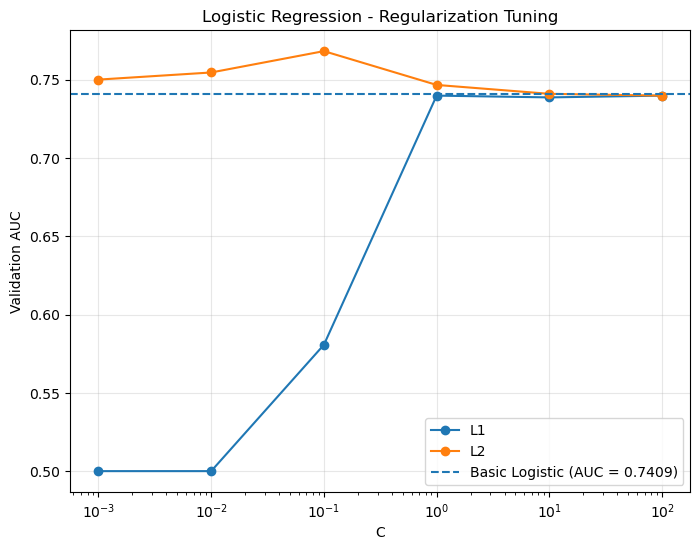

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# L1
plt.plot(
    l1_tuning_df["C"],
    l1_tuning_df["Validation AUC"],
    marker="o",
    label="L1"
)

# L2
plt.plot(
    l2_tuning_df["C"],
    l2_tuning_df["Validation AUC"],
    marker="o",
    label="L2"
)

# Basic Logistic
plt.axhline(
    y=basic_auc,
    linestyle="--",
    label=f"Basic Logistic (AUC = {basic_auc:.4f})"
)

# C 跨度很大，使用 log scale
plt.xscale("log")

plt.xlabel("C")
plt.ylabel("Validation AUC")
plt.title("Logistic Regression - Regularization Tuning")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

最後選擇 沒有L1L2的logit

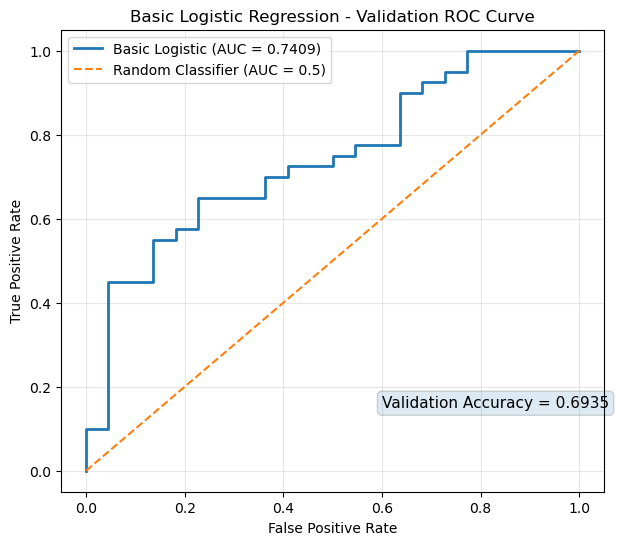

In [77]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# ROC
fpr, tpr, _ = roc_curve(
    y_val,
    basic_val_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Basic Logistic (AUC = {basic_auc:.4f})"
)

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random Classifier (AUC = 0.5)"
)

# Accuracy 顯示在圖上
plt.text(
    0.60,
    0.15,
    f"Validation Accuracy = {basic_accuracy:.4f}",
    fontsize=11,
    bbox=dict(
        boxstyle="round",
        alpha=0.15
    )
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Basic Logistic Regression - Validation ROC Curve"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## XGboost

In [78]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

basic_xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

basic_xgb.fit(
    X_train,
    y_train
)

# Validation probability
xgb_basic_val_prob = basic_xgb.predict_proba(
    X_val
)[:, 1]

# 0.5 threshold
xgb_basic_val_pred = (
    xgb_basic_val_prob >= 0.5
).astype(int)

# Accuracy
xgb_basic_accuracy = accuracy_score(
    y_val,
    xgb_basic_val_pred
)

# AUC
xgb_basic_auc = roc_auc_score(
    y_val,
    xgb_basic_val_prob
)

print(
    "XGBoost Accuracy:",
    round(xgb_basic_accuracy, 4)
)

print(
    "XGBoost AUC:",
    round(xgb_basic_auc, 4)
)

XGBoost Accuracy: 0.4355
XGBoost AUC: 0.4659


In [79]:
max_depth_values = [
    1,
    2,
    3,
    4,
    5,
    6
]

xgb_depth_results = []

for depth in max_depth_values:

    model = XGBClassifier(
        max_depth=depth,
        random_state=42,
        eval_metric="logloss"
    )

    model.fit(
        X_train,
        y_train
    )

    val_prob = model.predict_proba(
        X_val
    )[:, 1]

    val_pred = (
        val_prob >= 0.5
    ).astype(int)

    accuracy = accuracy_score(
        y_val,
        val_pred
    )

    auc = roc_auc_score(
        y_val,
        val_prob
    )

    xgb_depth_results.append({
        "max_depth": depth,
        "Validation Accuracy": accuracy,
        "Validation AUC": auc
    })

xgb_depth_df = pd.DataFrame(
    xgb_depth_results
)

xgb_depth_df

,max_depth,Validation Accuracy,Validation AUC
0,1,0.532258,0.571591
1,2,0.370968,0.396591
2,3,0.370968,0.418182
3,4,0.370968,0.420455
4,5,0.435484,0.398864
5,6,0.435484,0.465909


In [80]:
learning_rates = [
    0.01,
    0.03,
    0.05,
    0.1,
    0.2,
    0.3
]

xgb_lr_results = []

for lr in learning_rates:

    model = XGBClassifier(
        max_depth=5,
        learning_rate=lr,
        random_state=42,
        eval_metric="logloss"
    )

    model.fit(
        X_train,
        y_train
    )

    val_prob = model.predict_proba(
        X_val
    )[:, 1]

    val_pred = (
        val_prob >= 0.5
    ).astype(int)

    accuracy = accuracy_score(
        y_val,
        val_pred
    )

    auc = roc_auc_score(
        y_val,
        val_prob
    )

    xgb_lr_results.append({
        "learning_rate": lr,
        "Validation Accuracy": accuracy,
        "Validation AUC": auc
    })

xgb_lr_df = pd.DataFrame(
    xgb_lr_results
)

xgb_lr_df

,learning_rate,Validation Accuracy,Validation AUC
0,0.01,0.548387,0.586932
1,0.03,0.451613,0.479545
2,0.05,0.435484,0.519318
3,0.10,0.370968,0.445455
4,0.20,0.419355,0.460227
5,0.30,0.435484,0.398864


In [81]:
n_estimators_values = [
    20,
    50,
    100,
    200,
    300,
    500
]

xgb_n_results = []

for n in n_estimators_values:

    model = XGBClassifier(
        max_depth=5,
        learning_rate=0.3,
        n_estimators=n,
        random_state=42,
        eval_metric="logloss"
    )

    model.fit(
        X_train,
        y_train
    )

    val_prob = model.predict_proba(
        X_val
    )[:, 1]

    val_pred = (
        val_prob >= 0.5
    ).astype(int)

    accuracy = accuracy_score(
        y_val,
        val_pred
    )

    auc = roc_auc_score(
        y_val,
        val_prob
    )

    xgb_n_results.append({
        "n_estimators": n,
        "Validation Accuracy": accuracy,
        "Validation AUC": auc
    })

xgb_n_df = pd.DataFrame(xgb_n_results)

xgb_n_df

,n_estimators,Validation Accuracy,Validation AUC
0,20,0.419355,0.378409
1,50,0.419355,0.398864
2,100,0.435484,0.398864
3,200,0.500000,0.406818
4,300,0.500000,0.412500
5,500,0.500000,0.419318


In [82]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

param_grid = {
    "n_estimators": [50, 100, 200, 300, 500],
    "max_depth": [1, 2, 3, 4, 5],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2, 0.3],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

tscv = TimeSeriesSplit(
    n_splits=5
)

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=30,
    scoring="roc_auc",
    cv=tscv,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(
    X_train,
    y_train
)

print("Best Parameters:")
print(xgb_search.best_params_)

print()

print(
    "Best CV AUC:",
    round(xgb_search.best_score_, 4)
)

Best Parameters:
{'subsample': 0.8, 'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 1.0}

Best CV AUC: 0.5573


In [83]:
from sklearn.metrics import accuracy_score, roc_auc_score

# 取得 RandomizedSearchCV 找到的最佳 XGBoost
best_xgb = xgb_search.best_estimator_

# Validation 預測機率
xgb_val_prob = best_xgb.predict_proba(
    X_val
)[:, 1]

# threshold = 0.5
xgb_val_pred = (
    xgb_val_prob >= 0.5
).astype(int)

# Accuracy
xgb_val_accuracy = accuracy_score(
    y_val,
    xgb_val_pred
)

# AUC
xgb_val_auc = roc_auc_score(
    y_val,
    xgb_val_prob
)

print("Best Parameters:")
print(xgb_search.best_params_)

print()
print("XGBoost Validation Accuracy:", round(xgb_val_accuracy, 4))
print("XGBoost Validation AUC:", round(xgb_val_auc, 4))

Best Parameters:
{'subsample': 0.8, 'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 1.0}

XGBoost Validation Accuracy: 0.5323
XGBoost Validation AUC: 0.533


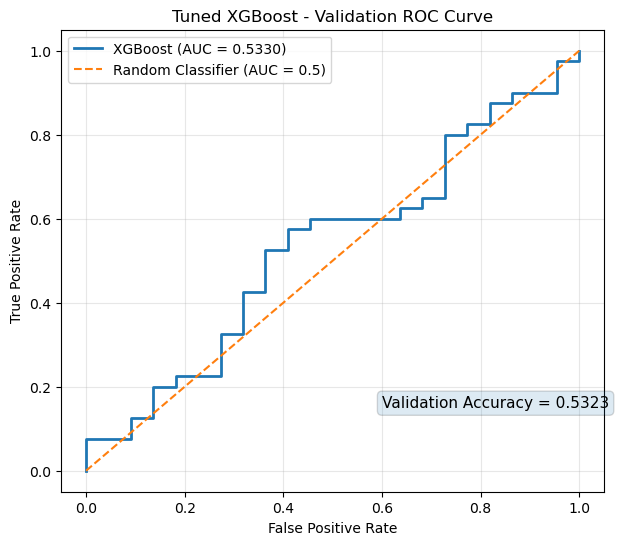

In [84]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(
    y_val,
    xgb_val_prob
)

plt.figure(figsize=(7, 6))

# XGBoost ROC
plt.plot(
    fpr_xgb,
    tpr_xgb,
    linewidth=2,
    label=f"XGBoost (AUC = {xgb_val_auc:.4f})"
)

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random Classifier (AUC = 0.5)"
)

# Accuracy
plt.text(
    0.60,
    0.15,
    f"Validation Accuracy = {xgb_val_accuracy:.4f}",
    fontsize=11,
    bbox=dict(
        boxstyle="round",
        alpha=0.15
    )
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Tuned XGBoost - Validation ROC Curve"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## GRU

In [85]:
from sklearn.preprocessing import StandardScaler

gru_scaler = StandardScaler()

# 只用目前 16 features 的 Train fit
gru_scaler.fit(X_train)

# 再轉換完整時間序列
X_all_scaled = gru_scaler.transform(
    model_data[FEATURES]
)

print("Feature count:", len(FEATURES))
print("Scaler features:", gru_scaler.n_features_in_)
print("X_all_scaled:", X_all_scaled.shape)

Feature count: 16
Scaler features: 16
X_all_scaled: (415, 16)


In [86]:
import numpy as np
import pandas as pd

sequence_length = 20

X_seq = []
y_seq = []
seq_dates = []

for i in range(sequence_length - 1, len(model_data)):

    # 過去 20 個交易日 × 16 features
    X_seq.append(
        X_all_scaled[
            i - sequence_length + 1 : i + 1
        ]
    )

    # 第 i 天對應的 target
    y_seq.append(
        model_data["target"].iloc[i]
    )

    # 保存預測日期
    seq_dates.append(
        model_data.index[i]
    )

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)
seq_dates = pd.to_datetime(seq_dates)

print("X_seq:", X_seq.shape)
print("y_seq:", y_seq.shape)

print("第一個日期:", seq_dates[0])
print("最後日期:", seq_dates[-1])

X_seq: (396, 20, 16)
y_seq: (396,)
第一個日期: 2025-02-03 00:00:00
最後日期: 2026-09-18 00:00:00


In [87]:
train_mask = seq_dates <= X_train.index.max()

val_mask = (
    (seq_dates >= X_val.index.min()) &
    (seq_dates <= X_val.index.max())
)

test_mask = (
    (seq_dates >= X_test.index.min()) &
    (seq_dates <= X_test.index.max())
)

X_train_gru = X_seq[train_mask]
y_train_gru = y_seq[train_mask]

X_val_gru = X_seq[val_mask]
y_val_gru = y_seq[val_mask]

X_test_gru = X_seq[test_mask]
y_test_gru = y_seq[test_mask]

print("GRU Train:", X_train_gru.shape, y_train_gru.shape)
print("GRU Validation:", X_val_gru.shape, y_val_gru.shape)
print("GRU Test:", X_test_gru.shape, y_test_gru.shape)

GRU Train: (271, 20, 16) (271,)
GRU Validation: (62, 20, 16) (62,)
GRU Test: (63, 20, 16) (63,)


In [88]:
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

tf.keras.backend.clear_session()
tf.random.set_seed(42)

basic_gru = Sequential([
    Input(shape=(
        X_train_gru.shape[1],
        X_train_gru.shape[2]
    )),

    GRU(32),

    Dense(
        1,
        activation="sigmoid"
    )
])

basic_gru.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

basic_gru.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,833 (18.88 KB)

 Trainable params: 4,833 (18.88 KB)

 Non-trainable params: 0 (0.00 B)

In [89]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_basic_gru = basic_gru.fit(
    X_train_gru,
    y_train_gru,

    validation_data=(
        X_val_gru,
        y_val_gru
    ),

    epochs=100,
    batch_size=16,

    shuffle=False,

    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.4649 - loss: 0.7222 - val_accuracy: 0.6774 - val_loss: 0.6727
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5904 - loss: 0.6757 - val_accuracy: 0.5645 - val_loss: 0.6570
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6273 - loss: 0.6522 - val_accuracy: 0.6774 - val_loss: 0.6497
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6827 - loss: 0.6357 - val_accuracy: 0.6613 - val_loss: 0.6448
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6974 - loss: 0.6220 - val_accuracy: 0.6613 - val_loss: 0.6407
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7122 - loss: 0.6094 - val_accuracy: 0.6613 - val_loss: 0.6377
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7269 - loss: 0.5970 - val_accuracy: 0.6613 - val_loss: 0.6359
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7306 - loss: 0.5842 - val_accuracy: 0.

In [90]:
from sklearn.metrics import accuracy_score, roc_auc_score

basic_gru_val_prob = basic_gru.predict(
    X_val_gru
).ravel()

basic_gru_val_pred = (
    basic_gru_val_prob >= 0.5
).astype(int)

basic_gru_accuracy = accuracy_score(
    y_val_gru,
    basic_gru_val_pred
)

basic_gru_auc = roc_auc_score(
    y_val_gru,
    basic_gru_val_prob
)

print(
    "Basic GRU Accuracy:",
    round(basic_gru_accuracy, 4)
)

print(
    "Basic GRU AUC:",
    round(basic_gru_auc, 4)
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 325ms/step
Basic GRU Accuracy: 0.6613
Basic GRU AUC: 0.6227


In [91]:
import tensorflow as tf
import pandas as pd

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score, roc_auc_score


configs = [
    {"units": 16, "dropout": 0.0, "lr": 0.001},
    {"units": 32, "dropout": 0.0, "lr": 0.001},
    {"units": 64, "dropout": 0.0, "lr": 0.001},

    {"units": 32, "dropout": 0.2, "lr": 0.001},
    {"units": 32, "dropout": 0.3, "lr": 0.001},

    {"units": 32, "dropout": 0.2, "lr": 0.0005},
    {"units": 32, "dropout": 0.2, "lr": 0.002}
]

gru_tuning_results = []

for config in configs:

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)

    model = Sequential([
        Input(shape=(
            X_train_gru.shape[1],
            X_train_gru.shape[2]
        )),

        GRU(config["units"]),

        Dropout(config["dropout"]),

        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=config["lr"]
        ),
        loss="binary_crossentropy"
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_gru,
        y_train_gru,

        validation_data=(
            X_val_gru,
            y_val_gru
        ),

        epochs=100,
        batch_size=16,
        shuffle=False,

        callbacks=[early_stop],
        verbose=0
    )

    val_prob = model.predict(
        X_val_gru,
        verbose=0
    ).ravel()

    val_pred = (
        val_prob >= 0.5
    ).astype(int)

    accuracy = accuracy_score(
        y_val_gru,
        val_pred
    )

    auc = roc_auc_score(
        y_val_gru,
        val_prob
    )

    gru_tuning_results.append({
        "units": config["units"],
        "dropout": config["dropout"],
        "learning_rate": config["lr"],
        "epochs": len(history.history["loss"]),
        "Validation Accuracy": accuracy,
        "Validation AUC": auc
    })


gru_tuning_df = pd.DataFrame(
    gru_tuning_results
)

gru_tuning_df = gru_tuning_df.sort_values(
    "Validation AUC",
    ascending=False
).reset_index(drop=True)

gru_tuning_df

,units,dropout,learning_rate,epochs,Validation Accuracy,Validation AUC
0,32,0.3,0.0010,37,0.661290,0.830682
1,32,0.2,0.0020,24,0.677419,0.821591
2,32,0.2,0.0010,31,0.629032,0.810227
3,32,0.2,0.0005,54,0.629032,0.807955
4,64,0.0,0.0010,28,0.677419,0.757955
5,16,0.0,0.0010,43,0.677419,0.730682
6,32,0.0,0.0010,24,0.596774,0.656818


In [92]:
seeds = [1, 21, 42, 84, 123]

gru_seed_results = []

for seed in seeds:

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    model = Sequential([
        Input(shape=(
            X_train_gru.shape[1],
            X_train_gru.shape[2]
        )),

        GRU(32),

        Dropout(0.2),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=0.002
        ),
        loss="binary_crossentropy"
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_gru,
        y_train_gru,

        validation_data=(
            X_val_gru,
            y_val_gru
        ),

        epochs=100,
        batch_size=16,
        shuffle=False,

        callbacks=[early_stop],
        verbose=0
    )

    val_prob = model.predict(
        X_val_gru,
        verbose=0
    ).ravel()

    val_pred = (
        val_prob >= 0.5
    ).astype(int)

    accuracy = accuracy_score(
        y_val_gru,
        val_pred
    )

    auc = roc_auc_score(
        y_val_gru,
        val_prob
    )

    gru_seed_results.append({
        "Seed": seed,
        "Epochs": len(history.history["loss"]),
        "Validation Accuracy": accuracy,
        "Validation AUC": auc
    })


gru_seed_df = pd.DataFrame(gru_seed_results)

gru_seed_df

,Seed,Epochs,Validation Accuracy,Validation AUC
0,1,20,0.645161,0.725000
1,21,19,0.725806,0.728409
2,42,24,0.677419,0.821591
3,84,19,0.661290,0.727273
4,123,21,0.677419,0.812500


In [93]:
gru_summary = pd.DataFrame({
    "Metric": [
        "Validation Accuracy",
        "Validation AUC"
    ],

    "Mean": [
        gru_seed_df["Validation Accuracy"].mean(),
        gru_seed_df["Validation AUC"].mean()
    ],

    "Std": [
        gru_seed_df["Validation Accuracy"].std(),
        gru_seed_df["Validation AUC"].std()
    ],

    "Min": [
        gru_seed_df["Validation Accuracy"].min(),
        gru_seed_df["Validation AUC"].min()
    ],

    "Max": [
        gru_seed_df["Validation Accuracy"].max(),
        gru_seed_df["Validation AUC"].max()
    ]
})

gru_summary

,Metric,Mean,Std,Min,Max
0,Validation Accuracy,0.677419,0.030175,0.645161,0.725806
1,Validation AUC,0.762955,0.049498,0.725000,0.821591


In [94]:
# 固定 seed = 42，重建 Tuned GRU
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

final_gru = Sequential([
    Input(shape=(
        X_train_gru.shape[1],
        X_train_gru.shape[2]
    )),

    GRU(32),

    Dropout(0.2),

    Dense(
        1,
        activation="sigmoid"
    )
])

final_gru.compile(
    optimizer=Adam(
        learning_rate=0.002
    ),
    loss="binary_crossentropy"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

final_gru.fit(
    X_train_gru,
    y_train_gru,

    validation_data=(
        X_val_gru,
        y_val_gru
    ),

    epochs=100,
    batch_size=16,
    shuffle=False,

    callbacks=[early_stop],
    verbose=0
)

# Validation probability
final_gru_val_prob = final_gru.predict(
    X_val_gru,
    verbose=0
).ravel()

final_gru_val_pred = (
    final_gru_val_prob >= 0.5
).astype(int)

final_gru_accuracy = accuracy_score(
    y_val_gru,
    final_gru_val_pred
)

final_gru_auc = roc_auc_score(
    y_val_gru,
    final_gru_val_prob
)

print("GRU Accuracy:", round(final_gru_accuracy, 4))
print("GRU AUC:", round(final_gru_auc, 4))

GRU Accuracy: 0.6774
GRU AUC: 0.8216


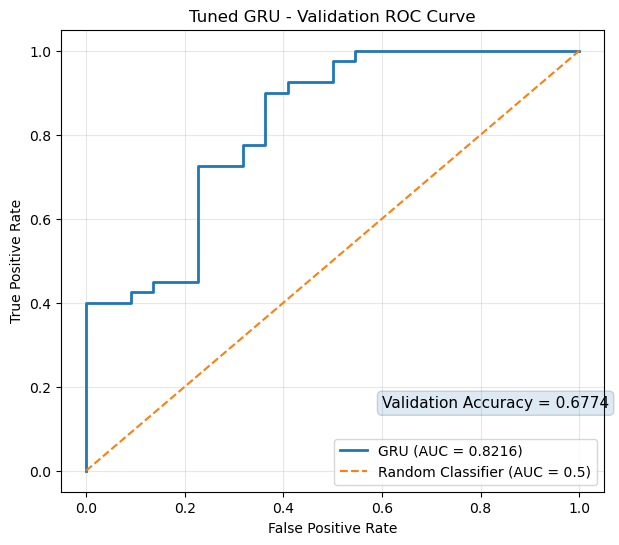

In [95]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr_gru, tpr_gru, _ = roc_curve(
    y_val_gru,
    final_gru_val_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr_gru,
    tpr_gru,
    linewidth=2,
    label=f"GRU (AUC = {final_gru_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random Classifier (AUC = 0.5)"
)

plt.text(
    0.60,
    0.15,
    f"Validation Accuracy = {final_gru_accuracy:.4f}",
    fontsize=11,
    bbox=dict(
        boxstyle="round",
        alpha=0.15
    )
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Tuned GRU - Validation ROC Curve"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## GRU + Atttention

In [96]:
import tensorflow as tf

from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    GRU,
    Dense,
    Attention,
    GlobalAveragePooling1D
)

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

# Input：20天 × 16 features
inputs = Input(
    shape=(
        X_train_gru.shape[1],
        X_train_gru.shape[2]
    )
)

# GRU 保留每一天的 hidden state
x = GRU(
    32,
    return_sequences=True
)(inputs)

# Self-Attention
x = Attention()([
    x,
    x
])

# 將20天資訊整合
x = GlobalAveragePooling1D()(x)

# 預測未來5日方向
outputs = Dense(
    1,
    activation="sigmoid"
)(x)

basic_attention = Model(
    inputs=inputs,
    outputs=outputs
)

basic_attention.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

basic_attention.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 20, 16)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 20, 32)    │      4,800 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 20, 32)    │          0 │ gru[0][0],        │
│ (Attention)         │                   │            │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │         33 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,833 (18.88 KB)

 Trainable params: 4,833 (18.88 KB)

 Non-trainable params: 0 (0.00 B)

In [97]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_attention = basic_attention.fit(
    X_train_gru,
    y_train_gru,

    validation_data=(
        X_val_gru,
        y_val_gru
    ),

    epochs=100,
    batch_size=16,
    shuffle=False,

    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.4354 - loss: 0.7180 - val_accuracy: 0.3226 - val_loss: 0.7846
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5387 - loss: 0.6903 - val_accuracy: 0.4839 - val_loss: 0.7563
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5756 - loss: 0.6768 - val_accuracy: 0.5161 - val_loss: 0.7377
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5720 - loss: 0.6678 - val_accuracy: 0.5000 - val_loss: 0.7245
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5793 - loss: 0.6608 - val_accuracy: 0.4839 - val_loss: 0.7141
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6089 - loss: 0.6549 - val_accuracy: 0.4677 - val_loss: 0.7056
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6162 - loss: 0.6495 - val_accuracy: 0.4677 - val_loss: 0.6986
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6310 - loss: 0.6444 - val_accuracy: 0.

In [98]:
from sklearn.metrics import accuracy_score, roc_auc_score

attention_val_prob = basic_attention.predict(
    X_val_gru,
    verbose=0
).ravel()

attention_val_pred = (
    attention_val_prob >= 0.5
).astype(int)

attention_val_accuracy = accuracy_score(
    y_val_gru,
    attention_val_pred
)

attention_val_auc = roc_auc_score(
    y_val_gru,
    attention_val_prob
)

print(
    "Basic GRU + Attention Accuracy:",
    round(attention_val_accuracy, 4)
)

print(
    "Basic GRU + Attention AUC:",
    round(attention_val_auc, 4)
)

Basic GRU + Attention Accuracy: 0.5323
Basic GRU + Attention AUC: 0.4807


In [99]:
import tensorflow as tf
import pandas as pd

from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    GRU,
    Dense,
    Dropout,
    Attention,
    GlobalAveragePooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score, roc_auc_score


configs = [
    {"units": 16, "dropout": 0.0, "lr": 0.001},
    {"units": 32, "dropout": 0.0, "lr": 0.001},
    {"units": 64, "dropout": 0.0, "lr": 0.001},

    {"units": 32, "dropout": 0.2, "lr": 0.001},
    {"units": 32, "dropout": 0.3, "lr": 0.001},

    {"units": 32, "dropout": 0.2, "lr": 0.0005},
    {"units": 32, "dropout": 0.2, "lr": 0.002}
]

attention_tuning_results = []

for config in configs:

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)

    inputs = Input(
        shape=(
            X_train_gru.shape[1],
            X_train_gru.shape[2]
        )
    )

    x = GRU(
        config["units"],
        return_sequences=True
    )(inputs)

    x = Dropout(
        config["dropout"]
    )(x)

    x = Attention()([
        x,
        x
    ])

    x = GlobalAveragePooling1D()(x)

    outputs = Dense(
        1,
        activation="sigmoid"
    )(x)

    model = Model(
        inputs=inputs,
        outputs=outputs
    )

    model.compile(
        optimizer=Adam(
            learning_rate=config["lr"]
        ),
        loss="binary_crossentropy"
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_gru,
        y_train_gru,

        validation_data=(
            X_val_gru,
            y_val_gru
        ),

        epochs=100,
        batch_size=16,
        shuffle=False,

        callbacks=[early_stop],
        verbose=0
    )

    val_prob = model.predict(
        X_val_gru,
        verbose=0
    ).ravel()

    val_pred = (
        val_prob >= 0.5
    ).astype(int)

    accuracy = accuracy_score(
        y_val_gru,
        val_pred
    )

    auc = roc_auc_score(
        y_val_gru,
        val_prob
    )

    attention_tuning_results.append({
        "units": config["units"],
        "dropout": config["dropout"],
        "learning_rate": config["lr"],
        "epochs": len(history.history["loss"]),
        "Validation Accuracy": accuracy,
        "Validation AUC": auc
    })


attention_tuning_df = pd.DataFrame(
    attention_tuning_results
)

attention_tuning_df = attention_tuning_df.sort_values(
    "Validation AUC",
    ascending=False
).reset_index(drop=True)

attention_tuning_df

,units,dropout,learning_rate,epochs,Validation Accuracy,Validation AUC
0,32,0.2,0.0010,40,0.661290,0.646591
1,64,0.0,0.0010,35,0.677419,0.646591
2,32,0.2,0.0020,27,0.693548,0.645455
3,32,0.3,0.0010,43,0.693548,0.634091
4,32,0.2,0.0005,62,0.612903,0.557955
5,16,0.0,0.0010,13,0.596774,0.514773
6,32,0.0,0.0010,26,0.532258,0.480682


In [100]:
best = attention_tuning_df.iloc[0]

attention_val_accuracy = best["Validation Accuracy"]
attention_val_auc = best["Validation AUC"]

print("GRU + Attention Validation Accuracy:", round(attention_val_accuracy, 4))
print("GRU + Attention Validation AUC:", round(attention_val_auc, 4))

GRU + Attention Validation Accuracy: 0.6613
GRU + Attention Validation AUC: 0.6466


In [101]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    GRU, Dense, Dropout, Attention, GlobalAveragePooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve


# ==========================================
# Best GRU + Attention Validation Result
# ==========================================

best_attention_config = attention_tuning_df.iloc[0]

attention_val_accuracy = best_attention_config["Validation Accuracy"]
attention_val_auc = best_attention_config["Validation AUC"]

print(
    "GRU + Attention Validation Accuracy:",
    round(attention_val_accuracy, 4)
)

print(
    "GRU + Attention Validation AUC:",
    round(attention_val_auc, 4)
)


# ==========================================
# Final GRU + Attention
# ==========================================

units = 16
dropout = 0.0
learning_rate = 0.001

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)


# Input
inputs = Input(
    shape=(X_train_gru.shape[1], X_train_gru.shape[2])
)


# GRU
x = GRU(
    units,
    return_sequences=True
)(inputs)

x = Dropout(dropout)(x)


# Self-Attention
x = Attention()([x, x])


# Pooling
x = GlobalAveragePooling1D()(x)


# Output
outputs = Dense(
    1,
    activation="sigmoid"
)(x)


# Final Model
final_attention = Model(
    inputs=inputs,
    outputs=outputs
)


final_attention.compile(
    optimizer=Adam(
        learning_rate=learning_rate
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# Early Stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


# Training
attention_history = final_attention.fit(
    X_train_gru,
    y_train_gru,
    validation_data=(
        X_val_gru,
        y_val_gru
    ),
    epochs=100,
    batch_size=16,
    shuffle=False,
    callbacks=[early_stop],
    verbose=0
)

GRU + Attention Validation Accuracy: 0.6613
GRU + Attention Validation AUC: 0.6466


## Transformer

In [102]:
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    MultiHeadAttention,
    Dense,
    Add,
    LayerNormalization,
    GlobalAveragePooling1D
)

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

# Input: 20 days × 16 features
inputs = Input(
    shape=(X_train_gru.shape[1], X_train_gru.shape[2])
)

# Multi-Head Self-Attention
attention_output = MultiHeadAttention(
    num_heads=2,
    key_dim=8
)(inputs, inputs)

# Residual Connection + Layer Normalization
x = Add()([inputs, attention_output])
x = LayerNormalization()(x)

# Feed Forward Network
ffn = Dense(32, activation="relu")(x)
ffn = Dense(16)(ffn)

# Residual Connection + Layer Normalization
x = Add()([x, ffn])
x = LayerNormalization()(x)

# Pooling
x = GlobalAveragePooling1D()(x)

# Output
outputs = Dense(
    1,
    activation="sigmoid"
)(x)

# Model
basic_transformer = Model(
    inputs=inputs,
    outputs=outputs
)

basic_transformer.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

basic_transformer.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 20, 16)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 16)    │      1,088 │ input_layer[0][0… │
│ (MultiHeadAttentio… │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 20, 16)    │          0 │ input_layer[0][0… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 20, 16)    │         32 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 20, 32)    │        544 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 20, 16)    │        528 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 20, 16)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 16)    │         32 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 16)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         17 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,241 (8.75 KB)

 Trainable params: 2,241 (8.75 KB)

 Non-trainable params: 0 (0.00 B)

In [103]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_transformer = basic_transformer.fit(
    X_train_gru,
    y_train_gru,

    validation_data=(
        X_val_gru,
        y_val_gru
    ),

    epochs=100,
    batch_size=16,
    shuffle=False,

    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.4760 - loss: 0.7428 - val_accuracy: 0.6452 - val_loss: 0.6358
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5498 - loss: 0.6925 - val_accuracy: 0.6452 - val_loss: 0.6319
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6310 - loss: 0.6738 - val_accuracy: 0.6452 - val_loss: 0.6320
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6458 - loss: 0.6640 - val_accuracy: 0.6452 - val_loss: 0.6319
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6716 - loss: 0.6565 - val_accuracy: 0.6452 - val_loss: 0.6314
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6753 - loss: 0.6495 - val_accuracy: 0.6452 - val_loss: 0.6306
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6568 - loss: 0.6429 - val_accuracy: 0.6452 - val_loss: 0.6298
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6605 - loss: 0.6365 - val_accuracy: 0.

In [104]:
from sklearn.metrics import accuracy_score, roc_auc_score

transformer_val_prob = basic_transformer.predict(
    X_val_gru,
    verbose=0
).ravel()

transformer_val_pred = (
    transformer_val_prob >= 0.5
).astype(int)

transformer_val_accuracy = accuracy_score(
    y_val_gru,
    transformer_val_pred
)

transformer_val_auc = roc_auc_score(
    y_val_gru,
    transformer_val_prob
)

print(
    "Transformer Accuracy:",
    round(transformer_val_accuracy, 4)
)

print(
    "Transformer AUC:",
    round(transformer_val_auc, 4)
)

Transformer Accuracy: 0.7097
Transformer AUC: 0.6443


In [105]:
transformer_configs = [
    {"heads": 1, "key_dim": 8,  "ff_dim": 16, "lr": 0.001},
    {"heads": 2, "key_dim": 8,  "ff_dim": 16, "lr": 0.001},
    {"heads": 2, "key_dim": 8,  "ff_dim": 32, "lr": 0.001},
    {"heads": 2, "key_dim": 16, "ff_dim": 32, "lr": 0.001},
    {"heads": 4, "key_dim": 8,  "ff_dim": 32, "lr": 0.001},
    {"heads": 2, "key_dim": 8,  "ff_dim": 32, "lr": 0.0005},
    {"heads": 2, "key_dim": 8,  "ff_dim": 32, "lr": 0.002}
]

transformer_tuning_results = []

for config in transformer_configs:

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)

    inputs = Input(
        shape=(
            X_train_gru.shape[1],
            X_train_gru.shape[2]
        )
    )

    # Multi-Head Attention
    attention_output = MultiHeadAttention(
        num_heads=config["heads"],
        key_dim=config["key_dim"]
    )(
        inputs,
        inputs
    )

    # Residual + LayerNorm
    x = LayerNormalization()(
        inputs + attention_output
    )

    # Feed Forward
    ffn = Dense(
        config["ff_dim"],
        activation="relu"
    )(x)

    ffn = Dense(
        X_train_gru.shape[2]
    )(ffn)

    # Residual + LayerNorm
    x = LayerNormalization()(
        x + ffn
    )

    x = GlobalAveragePooling1D()(x)

    outputs = Dense(
        1,
        activation="sigmoid"
    )(x)

    model = Model(
        inputs=inputs,
        outputs=outputs
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=config["lr"]
        ),
        loss="binary_crossentropy"
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_gru,
        y_train_gru,

        validation_data=(
            X_val_gru,
            y_val_gru
        ),

        epochs=100,
        batch_size=16,
        shuffle=False,

        callbacks=[early_stop],
        verbose=0
    )

    val_prob = model.predict(
        X_val_gru,
        verbose=0
    ).ravel()

    val_pred = (
        val_prob >= 0.5
    ).astype(int)

    accuracy = accuracy_score(
        y_val_gru,
        val_pred
    )

    auc = roc_auc_score(
        y_val_gru,
        val_prob
    )

    transformer_tuning_results.append({
        "heads": config["heads"],
        "key_dim": config["key_dim"],
        "ff_dim": config["ff_dim"],
        "learning_rate": config["lr"],
        "epochs": len(history.history["loss"]),
        "Validation Accuracy": accuracy,
        "Validation AUC": auc
    })


transformer_tuning_df = pd.DataFrame(
    transformer_tuning_results
)

transformer_tuning_df = transformer_tuning_df.sort_values(
    "Validation AUC",
    ascending=False
).reset_index(drop=True)

transformer_tuning_df

,heads,key_dim,ff_dim,learning_rate,epochs,Validation Accuracy,Validation AUC
0,4,8,32,0.0010,32,0.725806,0.677273
1,2,8,32,0.0005,62,0.709677,0.665909
2,2,8,32,0.0010,35,0.709677,0.644318
3,2,8,32,0.0020,23,0.709677,0.614773
4,2,16,32,0.0010,24,0.741935,0.611364
5,2,8,16,0.0010,24,0.693548,0.586364
6,1,8,16,0.0010,12,0.645161,0.469318


In [106]:
seeds = [1, 21, 42, 84, 123]

seed_results = []

for seed in seeds:

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    # 固定使用 tuning 第 0 組
    inputs = Input(
        shape=(X_train_gru.shape[1], X_train_gru.shape[2])
    )

    # Multi-Head Attention
    attention_output = MultiHeadAttention(
        num_heads=2,
        key_dim=8
    )(inputs, inputs)

    # Residual + LayerNorm
    x = Add()([inputs, attention_output])
    x = LayerNormalization()(x)

    # Feed Forward
    ffn = Dense(32, activation="relu")(x)
    ffn = Dense(16)(ffn)

    # Residual + LayerNorm
    x = Add()([x, ffn])
    x = LayerNormalization()(x)

    # Output
    x = GlobalAveragePooling1D()(x)
    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_gru,
        y_train_gru,
        validation_data=(X_val_gru, y_val_gru),
        epochs=100,
        batch_size=16,
        shuffle=False,
        callbacks=[early_stop],
        verbose=0
    )

    val_prob = model.predict(
        X_val_gru,
        verbose=0
    ).ravel()

    val_pred = (val_prob >= 0.5).astype(int)

    val_accuracy = accuracy_score(
        y_val_gru,
        val_pred
    )

    val_auc = roc_auc_score(
        y_val_gru,
        val_prob
    )

    seed_results.append({
        "Seed": seed,
        "Epochs": len(history.history["loss"]),
        "Validation Accuracy": val_accuracy,
        "Validation AUC": val_auc
    })

seed_df = pd.DataFrame(seed_results)

seed_df

,Seed,Epochs,Validation Accuracy,Validation AUC
0,1,12,0.645161,0.368182
1,21,45,0.612903,0.752273
2,42,35,0.709677,0.644318
3,84,14,0.645161,0.548864
4,123,12,0.677419,0.630682


In [107]:
# ==========================================
# Final Transformer
# Best config + Seed = 21
# ==========================================

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    MultiHeadAttention,
    Dense,
    Add,
    LayerNormalization,
    GlobalAveragePooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# 固定 Seed
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(21)

# Input: 20 days × 16 features
inputs = Input(
    shape=(X_train_gru.shape[1], X_train_gru.shape[2])
)

# Multi-Head Attention
attention_output = MultiHeadAttention(
    num_heads=2,
    key_dim=8
)(inputs, inputs)

# Residual + Layer Normalization
x = Add()([inputs, attention_output])
x = LayerNormalization()(x)

# Feed Forward Network
ffn = Dense(32, activation="relu")(x)
ffn = Dense(16)(ffn)

# Residual + Layer Normalization
x = Add()([x, ffn])
x = LayerNormalization()(x)

# Pooling
x = GlobalAveragePooling1D()(x)

# Output
outputs = Dense(
    1,
    activation="sigmoid"
)(x)

# Final Model
final_transformer = Model(
    inputs=inputs,
    outputs=outputs
)

final_transformer.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Early Stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Training
history_final_transformer = final_transformer.fit(
    X_train_gru,
    y_train_gru,
    validation_data=(X_val_gru, y_val_gru),
    epochs=100,
    batch_size=16,
    shuffle=False,
    callbacks=[early_stop],
    verbose=0
)

# ==========================================
# Validation
# ==========================================

transformer_val_prob = final_transformer.predict(
    X_val_gru,
    verbose=0
).ravel()

transformer_val_pred = (
    transformer_val_prob >= 0.5
).astype(int)

transformer_val_accuracy = accuracy_score(
    y_val_gru,
    transformer_val_pred
)

transformer_val_auc = roc_auc_score(
    y_val_gru,
    transformer_val_prob
)

print("Epochs:", len(history_final_transformer.history["loss"]))
print("Validation Accuracy:", round(transformer_val_accuracy, 4))
print("Validation AUC:", round(transformer_val_auc, 4))

Epochs: 45
Validation Accuracy: 0.6129
Validation AUC: 0.7523


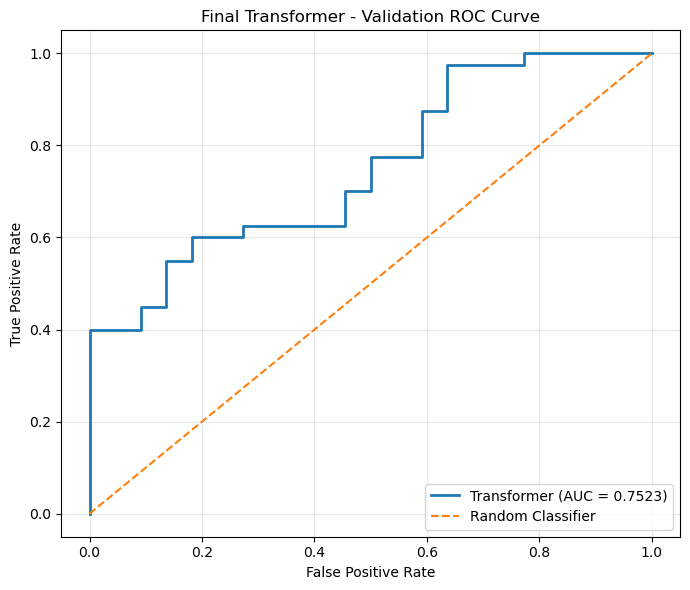

In [108]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Validation 預測機率
transformer_val_prob = final_transformer.predict(
    X_val_gru,
    verbose=0
).ravel()

# AUC
transformer_val_auc = roc_auc_score(
    y_val_gru,
    transformer_val_prob
)

# ROC
fpr, tpr, thresholds = roc_curve(
    y_val_gru,
    transformer_val_prob
)

# 畫圖
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Transformer (AUC = {transformer_val_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final Transformer - Validation ROC Curve")

plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## vali.比較

In [109]:
model_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost",
        "GRU",
        "GRU + Attention",
        "Transformer"
    ],

    "Validation Accuracy": [
        basic_accuracy,
        xgb_val_accuracy,
        final_gru_accuracy,
        attention_val_accuracy,
        transformer_val_accuracy
    ],

    "Validation AUC": [
        basic_auc,
        xgb_val_auc,
        final_gru_auc,
        attention_val_auc,
        transformer_val_auc
    ]
})

model_summary.round(4)

,Model,Validation Accuracy,Validation AUC
0,Logistic Regression,0.6935,0.7409
1,XGBoost,0.5323,0.5330
2,GRU,0.6774,0.8216
3,GRU + Attention,0.6613,0.6466
4,Transformer,0.6129,0.7523


## test

In [110]:
# Logistic Regression - Test

logistic_test_prob = basic_logit.predict_proba(
    X_test_scaled
)[:, 1]

logistic_test_pred = (
    logistic_test_prob >= 0.5
).astype(int)

logistic_test_accuracy = accuracy_score(
    y_test,
    logistic_test_pred
)

logistic_test_auc = roc_auc_score(
    y_test,
    logistic_test_prob
)

print(
    "Logistic Test Accuracy:",
    round(logistic_test_accuracy, 4)
)

print(
    "Logistic Test AUC:",
    round(logistic_test_auc, 4)
)

Logistic Test Accuracy: 0.5238
Logistic Test AUC: 0.5589


In [111]:
# XGBoost - Test

xgb_test_prob = best_xgb.predict_proba(
    X_test
)[:, 1]

xgb_test_pred = (
    xgb_test_prob >= 0.5
).astype(int)

xgb_test_accuracy = accuracy_score(
    y_test,
    xgb_test_pred
)

xgb_test_auc = roc_auc_score(
    y_test,
    xgb_test_prob
)

print(
    "XGBoost Test Accuracy:",
    round(xgb_test_accuracy, 4)
)

print(
    "XGBoost Test AUC:",
    round(xgb_test_auc, 4)
)

XGBoost Test Accuracy: 0.3968
XGBoost Test AUC: 0.5305


In [112]:
# GRU - Test

gru_test_prob = final_gru.predict(
    X_test_gru,
    verbose=0
).ravel()

gru_test_pred = (
    gru_test_prob >= 0.5
).astype(int)

gru_test_accuracy = accuracy_score(
    y_test_gru,
    gru_test_pred
)

gru_test_auc = roc_auc_score(
    y_test_gru,
    gru_test_prob
)

print(
    "GRU Test Accuracy:",
    round(gru_test_accuracy, 4)
)

print(
    "GRU Test AUC:",
    round(gru_test_auc, 4)
)

GRU Test Accuracy: 0.5238
GRU Test AUC: 0.5979


In [113]:
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# =========================
# GRU + Attention - Test
# =========================

# Test 預測機率
attention_test_prob = final_attention.predict(
    X_test_gru,
    verbose=0
).ravel()

# 0.5 threshold
attention_test_pred = (
    attention_test_prob >= 0.5
).astype(int)

# Test Accuracy
attention_test_accuracy = accuracy_score(
    y_test_gru,
    attention_test_pred
)

# Test AUC
attention_test_auc = roc_auc_score(
    y_test_gru,
    attention_test_prob
)

print("GRU + Attention Test Accuracy:", round(attention_test_accuracy, 4))
print("GRU + Attention Test AUC:", round(attention_test_auc, 4))

GRU + Attention Test Accuracy: 0.4444
GRU + Attention Test AUC: 0.4032


In [114]:
transformer_test_prob = final_transformer.predict(
    X_test_gru,
    verbose=0
).ravel()

transformer_test_pred = (
    transformer_test_prob >= 0.5
).astype(int)

transformer_test_accuracy = accuracy_score(
    y_test_gru,
    transformer_test_pred
)

transformer_test_auc = roc_auc_score(
    y_test_gru,
    transformer_test_prob
)

print(
    "Transformer Test Accuracy:",
    round(transformer_test_accuracy, 4)
)

print(
    "Transformer Test AUC:",
    round(transformer_test_auc, 4)
)

Transformer Test Accuracy: 0.4921
Transformer Test AUC: 0.7516


## test比較 最終模型

In [115]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost",
        "GRU",
        "GRU + Attention",
        "Transformer"
    ],

    "Validation Accuracy": [
        basic_accuracy,
        xgb_val_accuracy,
        final_gru_accuracy,
        attention_val_accuracy,
        transformer_val_accuracy
    ],

    "Validation AUC": [
        basic_auc,
        xgb_val_auc,
        final_gru_auc,
        attention_val_auc,
        transformer_val_auc
    ],

    "Test Accuracy": [
        logistic_test_accuracy,
        xgb_test_accuracy,
        gru_test_accuracy,
        attention_test_accuracy,
        transformer_test_accuracy
    ],

    "Test AUC": [
        logistic_test_auc,
        xgb_test_auc,
        gru_test_auc,
        attention_test_auc,
        transformer_test_auc
    ]
})

final_results.round(4)

,Model,Validation Accuracy,Validation AUC,Test Accuracy,Test AUC
0,Logistic Regression,0.6935,0.7409,0.5238,0.5589
1,XGBoost,0.5323,0.5330,0.3968,0.5305
2,GRU,0.6774,0.8216,0.5238,0.5979
3,GRU + Attention,0.6613,0.6466,0.4444,0.4032
4,Transformer,0.6129,0.7523,0.4921,0.7516


In [116]:
# =========================================================
# FINAL MODEL = Transformer
# =========================================================

FINAL_MODEL = final_transformer

FINAL_MODEL_NAME = "Transformer"

SEQ_LEN = 20
N_FEATURES = 16
PREDICTION_HORIZON = 5


print("===== FINAL MODEL =====")
print("Model       :", FINAL_MODEL_NAME)
print("Input Shape :", FINAL_MODEL.input_shape)
print("Output Shape:", FINAL_MODEL.output_shape)
print("Sequence    :", SEQ_LEN, "trading days")
print("Features    :", N_FEATURES)
print("Prediction  :", PREDICTION_HORIZON, "trading days")

print("\nValidation Accuracy:",
      round(transformer_val_accuracy, 4))

print("Validation AUC     :",
      round(transformer_val_auc, 4))

print("Test Accuracy      :",
      round(transformer_test_accuracy, 4))

print("Test AUC           :",
      round(transformer_test_auc, 4))

===== FINAL MODEL =====
Model       : Transformer
Input Shape : (None, 20, 16)
Output Shape: (None, 1)
Sequence    : 20 trading days
Features    : 16
Prediction  : 5 trading days

Validation Accuracy: 0.6129
Validation AUC     : 0.7523
Test Accuracy      : 0.4921
Test AUC           : 0.7516


# 回傳line

### data_service.py

In [164]:
%%writefile data_service.py

import pandas as pd
import requests
from io import StringIO
from datetime import datetime, timedelta

REQUEST_HEADERS = {
    "User-Agent": "Mozilla/5.0"
}


def _to_numeric(series):
    return pd.to_numeric(
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("--", "", regex=False)
        .str.strip(),
        errors="coerce"
    )


def _normalize_date(x):
    return pd.Timestamp(x).normalize()


# =========================================================
# TWSE 上市法人
# =========================================================

def get_twse_chip_data(date):
    """
    date: YYYY-MM-DD / Timestamp
    回傳指定日期 TWSE 法人資料
    """

    date = pd.Timestamp(date)
    date_str = date.strftime("%Y%m%d")

    url = "https://www.twse.com.tw/rwd/zh/fund/T86"

    params = {
        "date": date_str,
        "selectType": "ALLBUT0999",
        "response": "json"
    }

    r = requests.get(
        url,
        params=params,
        headers=REQUEST_HEADERS,
        timeout=20
    )

    r.raise_for_status()
    js = r.json()

    if "data" not in js or not js["data"]:
        return pd.DataFrame()

    fields = js.get("fields", [])
    df = pd.DataFrame(js["data"], columns=fields)

    # 代號、名稱
    symbol_col = None
    name_col = None

    for c in df.columns:
        if "證券代號" in c:
            symbol_col = c
        if "證券名稱" in c:
            name_col = c

    if symbol_col is None or name_col is None:
        return pd.DataFrame()

    # 外資買賣超
    foreign_col = None
    trust_col = None

    for c in df.columns:
        if "外陸資買賣超股數" in c:
            foreign_col = c
        if "投信買賣超股數" in c:
            trust_col = c

    if foreign_col is None or trust_col is None:
        return pd.DataFrame()

    out = pd.DataFrame({
        "date": date.normalize(),
        "證券代號": df[symbol_col].astype(str).str.strip(),
        "證券名稱": df[name_col].astype(str).str.strip(),
        "foreign_net": _to_numeric(df[foreign_col]),
        "trust_net": _to_numeric(df[trust_col]),
        "market": "TWSE"
    })

    out = out.dropna(subset=["證券代號"])

    return out.reset_index(drop=True)


# =========================================================
# TPEx 上櫃法人
# =========================================================

def get_tpex_chip_data(date):
    """
    date: YYYY-MM-DD / Timestamp
    回傳指定日期 TPEx 法人資料
    """

    date = pd.Timestamp(date)

    roc_year = date.year - 1911
    roc_date = f"{roc_year}/{date.month:02d}/{date.day:02d}"

    url = (
        "https://www.tpex.org.tw/web/stock/3insti/daily_trade/"
        "3itrade_hedge_result.php"
    )

    params = {
        "l": "zh-tw",
        "o": "htm",
        "d": roc_date,
        "s": "0,asc,0"
    }

    r = requests.get(
        url,
        params=params,
        headers=REQUEST_HEADERS,
        timeout=20
    )

    r.raise_for_status()

    tables = pd.read_html(StringIO(r.text))

    if not tables:
        return pd.DataFrame()

    df = tables[0]

    # TPEx 欄位位置
    if df.shape[1] < 14:
        return pd.DataFrame()

    out = pd.DataFrame({
        "date": date.normalize(),
        "證券代號": df.iloc[:, 0].astype(str).str.strip(),
        "證券名稱": df.iloc[:, 1].astype(str).str.strip(),
        "foreign_net": _to_numeric(df.iloc[:, 4]),
        "trust_net": _to_numeric(df.iloc[:, 13]),
        "market": "TPEx"
    })

    out = out[
        out["證券代號"].str.match(r"^\d{4}$", na=False)
    ]

    return out.reset_index(drop=True)


# =========================================================
# TAIEX 官方指數
# =========================================================

def get_twse_taiex_close(date):
    """
    指定日期抓 TWSE 官方加權指數收盤價
    """

    date = pd.Timestamp(date)
    date_str = date.strftime("%Y%m%d")

    url = "https://www.twse.com.tw/rwd/zh/afterTrading/MI_INDEX"

    params = {
        "date": date_str,
        "type": "IND"
    }

    r = requests.get(
        url,
        params=params,
        headers=REQUEST_HEADERS,
        timeout=20
    )

    r.raise_for_status()
    js = r.json()

    tables = js.get("tables", [])

    for table in tables:
        fields = table.get("fields", [])
        data = table.get("data", [])

        if not fields or not data:
            continue

        for row in data:
            row_text = " ".join(map(str, row))

            if "發行量加權股價指數" in row_text:
                # 找 row 裡第一個可轉成數字、且不像日期的值
                for value in row[1:]:
                    try:
                        x = float(
                            str(value)
                            .replace(",", "")
                            .strip()
                        )

                        if x > 1000:
                            return x

                    except:
                        continue

    return None


# =========================================================
# 三者完整性判斷
# =========================================================

def check_complete_data_date(date, verbose=False):
    """
    同一天必須：
    1. TWSE 法人有資料
    2. TPEx 法人有資料
    3. TAIEX 有收盤價

    三個都成立才算完整資料日
    """

    date = pd.Timestamp(date).normalize()

    try:
        twse = get_twse_chip_data(date)
    except Exception as e:
        if verbose:
            print("TWSE 失敗:", repr(e))
        twse = pd.DataFrame()

    try:
        tpex = get_tpex_chip_data(date)
    except Exception as e:
        if verbose:
            print("TPEx 失敗:", repr(e))
        tpex = pd.DataFrame()

    try:
        taiex = get_twse_taiex_close(date)
    except Exception as e:
        if verbose:
            print("TAIEX 失敗:", repr(e))
        taiex = None

    twse_ok = len(twse) > 100
    tpex_ok = len(tpex) > 100
    taiex_ok = taiex is not None

    if verbose:
        print(f"日期：{date.date()}")
        print(f"TWSE：{len(twse)} 筆")
        print(f"TPEx：{len(tpex)} 筆")
        print(f"TAIEX：{taiex}")
        print(
            "完整：",
            twse_ok and tpex_ok and taiex_ok
        )

    return {
        "date": date,
        "twse_ok": twse_ok,
        "tpex_ok": tpex_ok,
        "taiex_ok": taiex_ok,
        "complete": twse_ok and tpex_ok and taiex_ok,
        "twse": twse,
        "tpex": tpex,
        "taiex_close": taiex
    }


def get_latest_complete_data_date(
    start_date=None,
    lookback_days=10,
    verbose=False
):
    """
    從 start_date 往前找最近完整共同日。

    今天不完整 → 自動退回前一個完整交易日。
    """

    if start_date is None:
        start_date = pd.Timestamp.now().normalize()
    else:
        start_date = pd.Timestamp(start_date).normalize()

    for i in range(lookback_days):
        d = start_date - pd.Timedelta(days=i)

        result = check_complete_data_date(
            d,
            verbose=verbose
        )

        if result["complete"]:
            return result

    raise ValueError(
        f"最近 {lookback_days} 天找不到完整共同資料日"
    )

# =========================================================
# 單股股價下載
# =========================================================

import yfinance as yf


def get_yf_candidates(symbol, market=None):
    symbol = str(symbol).strip()

    if market == "TWSE":
        return [f"{symbol}.TW"]

    if market == "TPEx":
        return [f"{symbol}.TWO"]

    # 不知道市場時兩個都試
    return [
        f"{symbol}.TW",
        f"{symbol}.TWO"
    ]


def download_single_stock(
    symbol,
    market=None,
    period="6mo"
):
    """
    下載單一股票歷史行情。
    market 可指定 TWSE / TPEx。
    """

    candidates = get_yf_candidates(
        symbol,
        market
    )

    last_error = None

    for ticker in candidates:

        try:
            df = yf.download(
                ticker,
                period=period,
                auto_adjust=True,
                progress=False,
                threads=False
            )

            if df is None or df.empty:
                continue

            # yfinance 有時會回 MultiIndex
            if isinstance(
                df.columns,
                pd.MultiIndex
            ):
                df.columns = df.columns.get_level_values(0)

            df.index = pd.to_datetime(
                df.index
            ).tz_localize(None)

            df = df.sort_index()

            needed = [
                "Open",
                "High",
                "Low",
                "Close",
                "Volume"
            ]

            if not all(
                c in df.columns
                for c in needed
            ):
                continue

            df = df[needed].copy()

            df["symbol"] = str(symbol)
            df["ticker"] = ticker

            return df

        except Exception as e:
            last_error = e
            continue

    if last_error is not None:
        raise ValueError(
            f"{symbol} 股價下載失敗：{last_error}"
        )

    raise ValueError(
        f"{symbol} 找不到可用股價資料"
    )

def get_stock_data_on_complete_date(
    symbol,
    market=None,
    start_date=None,
    period="6mo",
    lookback_days=10
):
    """
    下載個股資料，並自動裁到最近完整共同日。

    完整共同日 =
    TWSE法人 + TPEx法人 + TAIEX
    三者同一天都有資料。
    """

    complete = get_latest_complete_data_date(
        start_date=start_date,
        lookback_days=lookback_days,
        verbose=False
    )

    complete_date = complete["date"]

    price = download_single_stock(
        symbol=symbol,
        market=market,
        period=period
    )

    # 只保留完整共同日以前的資料
    price = price[
        price.index.normalize() <= complete_date
    ].copy()

    if price.empty:
        raise ValueError(
            f"{symbol} 在 {complete_date.date()} 前沒有股價資料"
        )

    return {
        "symbol": str(symbol),
        "market": market,
        "data_date": complete_date,
        "price": price,
        "twse_chip": complete["twse"],
        "tpex_chip": complete["tpex"],
        "taiex_close": complete["taiex_close"]
    }

def get_single_stock_complete_bundle(
    symbol,
    market=None,
    start_date=None,
    period="6mo",
    lookback_days=10
):
    """
    單股完整資料包：
    - 最近完整共同日
    - 個股股價
    - 對應市場法人資料
    - TAIEX
    """

    result = get_stock_data_on_complete_date(
        symbol=symbol,
        market=market,
        start_date=start_date,
        period=period,
        lookback_days=lookback_days
    )

    data_date = result["data_date"]

    if market == "TWSE":
        chip = result["twse_chip"].copy()

    elif market == "TPEx":
        chip = result["tpex_chip"].copy()

    else:
        chip = pd.concat(
            [
                result["twse_chip"],
                result["tpex_chip"]
            ],
            ignore_index=True
        )

    chip["證券代號"] = (
        chip["證券代號"]
        .astype(str)
        .str.strip()
    )

    stock_chip = chip[
        chip["證券代號"] == str(symbol)
    ].copy()

    if stock_chip.empty:
        raise ValueError(
            f"{symbol} 在 {data_date.date()} 找不到法人資料"
        )

    stock_chip = stock_chip.iloc[0]

    return {
        "symbol": str(symbol),
        "market": stock_chip["market"],
        "name": stock_chip["證券名稱"],
        "data_date": data_date,
        "price": result["price"],
        "taiex_close": result["taiex_close"],
        "foreign_net": stock_chip["foreign_net"],
        "trust_net": stock_chip["trust_net"]
    }

# =========================================================
# chip_history 更新
# =========================================================

def update_chip_history(
    csv_path="chip_history.csv",
    start_date=None,
    lookback_days=10,
    verbose=True
):
    """
    更新法人歷史資料。

    規則：
    - TWSE + TPEx + TAIEX 同一天都完整
      → 才寫入 chip_history.csv
    - 今天不完整
      → 自動使用最近完整共同日
    - 已存在的日期不重複寫入
    """

    complete = get_latest_complete_data_date(
        start_date=start_date,
        lookback_days=lookback_days,
        verbose=False
    )

    data_date = complete["date"]

    # 合併 TWSE + TPEx
    new_chip = pd.concat(
        [
            complete["twse"],
            complete["tpex"]
        ],
        ignore_index=True
    )

    new_chip["date"] = pd.to_datetime(
        new_chip["date"]
    ).dt.normalize()

    new_chip["證券代號"] = (
        new_chip["證券代號"]
        .astype(str)
        .str.strip()
    )

    # -----------------------------
    # 讀舊資料
    # -----------------------------
    try:
        old = pd.read_csv(
            csv_path,
            dtype={
                "證券代號": str
            }
        )

        old["date"] = pd.to_datetime(
            old["date"]
        ).dt.normalize()

        old["證券代號"] = (
            old["證券代號"]
            .astype(str)
            .str.strip()
        )

    except FileNotFoundError:
        old = pd.DataFrame(
            columns=[
                "date",
                "證券代號",
                "證券名稱",
                "foreign_net",
                "trust_net",
                "market"
            ]
        )

    # -----------------------------
    # 判斷這一天是否已存在
    # -----------------------------
    existing = old[
        old["date"] == data_date
    ]

    existing_markets = set(
        existing["market"].dropna()
    )

    # 如果該日期 TWSE + TPEx 都已存在
    if {"TWSE", "TPEx"}.issubset(
        existing_markets
    ):
        if verbose:
            print(
                f"{data_date.date()} 已存在完整法人資料"
            )

        return {
            "status": "already_exists",
            "data_date": data_date,
            "rows": len(existing)
        }

    # -----------------------------
    # 如果之前只有半套資料
    # 先移除該日期再重寫完整版本
    # -----------------------------
    old = old[
        old["date"] != data_date
    ].copy()

    combined = pd.concat(
        [
            old,
            new_chip
        ],
        ignore_index=True
    )

    combined = combined.drop_duplicates(
        subset=[
            "date",
            "證券代號",
            "market"
        ],
        keep="last"
    )

    combined = combined.sort_values(
        [
            "date",
            "market",
            "證券代號"
        ]
    ).reset_index(drop=True)

    combined.to_csv(
        csv_path,
        index=False,
        encoding="utf-8-sig"
    )

    if verbose:
        print("法人歷史更新完成")
        print("資料日期：", data_date.date())
        print("TWSE：", len(complete["twse"]))
        print("TPEx：", len(complete["tpex"]))
        print("總筆數：", len(combined))

    return {
        "status": "updated",
        "data_date": data_date,
        "rows": len(new_chip)
    }

# =========================================================
# TAIEX 歷史資料
# =========================================================

import yfinance as yf


def download_taiex_history(
    period="1y",
    end_date=None
):
    """
    下載 TAIEX 歷史資料。
    Yahoo 為主，最近缺的日期再用 TWSE 官方補。
    """

    df = yf.download(
        "^TWII",
        period=period,
        auto_adjust=True,
        progress=False,
        threads=False
    )

    if df is None or df.empty:
        df = pd.DataFrame(
            columns=["Close"]
        )

    if isinstance(
        df.columns,
        pd.MultiIndex
    ):
        df.columns = df.columns.get_level_values(0)

    if not df.empty:
        df.index = pd.to_datetime(
            df.index
        ).tz_localize(None)

        df = df.sort_index()

        df = df[["Close"]].copy()

    # ---------------------------------
    # 補最近可能缺失的官方 TAIEX
    # ---------------------------------
    if end_date is None:
        end_date = pd.Timestamp.now().normalize()
    else:
        end_date = pd.Timestamp(
            end_date
        ).normalize()

    start_fill = end_date - pd.Timedelta(days=10)

    for d in pd.date_range(
        start_fill,
        end_date,
        freq="D"
    ):
        d = pd.Timestamp(d).normalize()

        if d in df.index:
            continue

        try:
            close = get_twse_taiex_close(d)
        except Exception:
            close = None

        if close is not None:
            df.loc[d, "Close"] = float(close)

    df = df.sort_index()

    return df

def get_taiex_on_complete_date(
    start_date=None,
    period="1y",
    lookback_days=10
):
    """
    取得 TAIEX 歷史資料，
    並嚴格裁到最近完整共同日。
    """

    complete = get_latest_complete_data_date(
        start_date=start_date,
        lookback_days=lookback_days,
        verbose=False
    )

    data_date = complete["date"]

    taiex = download_taiex_history(
        period=period,
        end_date=data_date
    )

    taiex = taiex[
        taiex.index.normalize() <= data_date
    ].copy()

    if taiex.empty:
        raise ValueError(
            f"{data_date.date()} 前沒有 TAIEX 歷史資料"
        )

    return {
        "data_date": data_date,
        "taiex": taiex
    }

# =========================================================
# 全市場股票池
# =========================================================

def get_stock_pool_on_complete_date(
    start_date=None,
    lookback_days=10
):
    """
    取得最近完整共同日的 TWSE + TPEx 股票池。
    只保留 4 碼股票代號。
    """

    complete = get_latest_complete_data_date(
        start_date=start_date,
        lookback_days=lookback_days,
        verbose=False
    )

    data_date = complete["date"]

    pool = pd.concat(
        [
            complete["twse"],
            complete["tpex"]
        ],
        ignore_index=True
    )

    pool["證券代號"] = (
        pool["證券代號"]
        .astype(str)
        .str.strip()
    )

    pool = pool[
        pool["證券代號"].str.match(
            r"^\d{4}$",
            na=False
        )
    ].copy()

    pool = pool[
        [
            "證券代號",
            "證券名稱",
            "market"
        ]
    ]

    pool = pool.drop_duplicates(
        subset=["證券代號"]
    )

    pool = pool.reset_index(drop=True)

    return {
        "data_date": data_date,
        "pool": pool
    }


# =========================================================
# 多股票行情下載
# =========================================================

def download_market_prices(
    stock_pool,
    data_date,
    period="1y",
    batch_size=100,
    verbose=True
):
    """
    批次下載 TWSE + TPEx 行情。

    回傳：
    {
        "2330": DataFrame,
        "5347": DataFrame,
        ...
    }

    每支股票都會裁到 data_date。
    """

    import yfinance as yf

    stock_pool = stock_pool.copy()

    stock_pool["證券代號"] = (
        stock_pool["證券代號"]
        .astype(str)
        .str.strip()
    )

    data_date = pd.Timestamp(
        data_date
    ).normalize()

    # symbol -> Yahoo ticker
    ticker_map = {}

    for _, row in stock_pool.iterrows():

        symbol = row["證券代號"]
        market = row["market"]

        if market == "TWSE":
            ticker = f"{symbol}.TW"

        elif market == "TPEx":
            ticker = f"{symbol}.TWO"

        else:
            continue

        ticker_map[ticker] = symbol

    tickers = list(ticker_map.keys())

    result = {}

    for i in range(
        0,
        len(tickers),
        batch_size
    ):

        batch = tickers[
            i:i + batch_size
        ]

        if verbose:
            print(
                f"下載 {i + 1} ~ "
                f"{min(i + batch_size, len(tickers))}"
                f" / {len(tickers)}"
            )

        try:
            raw = yf.download(
                batch,
                period=period,
                auto_adjust=True,
                progress=False,
                threads=True,
                group_by="ticker"
            )

        except Exception as e:
            if verbose:
                print(
                    "批次下載失敗：",
                    repr(e)
                )
            continue

        # -----------------------------
        # 單 ticker 特例
        # -----------------------------
        if len(batch) == 1:

            ticker = batch[0]
            symbol = ticker_map[ticker]

            df = raw.copy()

            if isinstance(
                df.columns,
                pd.MultiIndex
            ):
                df.columns = (
                    df.columns
                    .get_level_values(-1)
                )

            needed = [
                "Open",
                "High",
                "Low",
                "Close",
                "Volume"
            ]

            if all(
                c in df.columns
                for c in needed
            ):

                df = df[needed].copy()

                df.index = pd.to_datetime(
                    df.index
                ).tz_localize(None)

                df = df[
                    df.index.normalize()
                    <= data_date
                ]

                if not df.empty:
                    result[symbol] = df

            continue

        # -----------------------------
        # 多 ticker
        # -----------------------------
        for ticker in batch:

            symbol = ticker_map[ticker]

            try:
                if ticker not in raw.columns.get_level_values(0):
                    continue

                df = raw[ticker].copy()

                needed = [
                    "Open",
                    "High",
                    "Low",
                    "Close",
                    "Volume"
                ]

                if not all(
                    c in df.columns
                    for c in needed
                ):
                    continue

                df = df[needed].copy()

                df = df.dropna(
                    subset=["Close"]
                )

                df.index = pd.to_datetime(
                    df.index
                ).tz_localize(None)

                df = df[
                    df.index.normalize()
                    <= data_date
                ]

                if not df.empty:
                    result[symbol] = df

            except Exception:
                continue

    if verbose:
        print(
            f"\n成功下載：{len(result)} 檔"
        )

    return result

Overwriting data_service.py


In [165]:
import importlib
import data_service

importlib.reload(data_service)

<module 'data_service' from 'C:\\Users\\User\\Desktop\\nschool 專案\\第二次專案\\data_service.py'>

In [149]:
import importlib
import data_service

importlib.reload(data_service)

result = data_service.check_complete_data_date(
    "2026-09-29",
    verbose=True
)

日期：2026-09-29
TWSE：1333 筆
TPEx：796 筆
TAIEX：47631.96
完整： True


In [150]:
latest = data_service.get_latest_complete_data_date(
    "2026-09-30",
    lookback_days=7,
    verbose=True
)

print("\n最新完整共同日：", latest["date"].date())

日期：2026-09-30
TWSE：0 筆
TPEx：0 筆
TAIEX：None
完整： False
日期：2026-09-29
TWSE：1333 筆
TPEx：796 筆
TAIEX：47631.96
完整： True

最新完整共同日： 2026-09-29


In [151]:
df_5347 = data_service.download_single_stock(
    "5347",
    market="TPEx",
    period="6mo"
)

print(df_5347.tail())
print("\n最後日期：", df_5347.index.max().date())
print("筆數：", len(df_5347))

Price        Open   High    Low  Close    Volume symbol    ticker
2026-09-22  175.0  181.5  172.0  173.0  31958978   5347  5347.TWO
2026-09-23  175.5  176.5  170.5  173.0  12619461   5347  5347.TWO
2026-09-24  172.5  173.5  168.0  170.5  10757853   5347  5347.TWO
2026-09-29  172.5  182.5  170.5  178.5  33763957   5347  5347.TWO
2026-09-30  184.5  185.0  179.0  180.0  12104192   5347  5347.TWO

最後日期： 2026-09-30
筆數： 127


In [152]:
result_5347 = data_service.get_stock_data_on_complete_date(
    "5347",
    market="TPEx",
    start_date="2026-09-30",
    period="6mo"
)

print("完整資料日：", result_5347["data_date"].date())
print("股價最後日期：", result_5347["price"].index.max().date())
print("TAIEX：", result_5347["taiex_close"])

print(
    result_5347["price"].tail()
)

完整資料日： 2026-09-29
股價最後日期： 2026-09-29
TAIEX： 47631.96
Price        Open   High    Low  Close    Volume symbol    ticker
2026-09-21  172.5  174.0  166.5  172.0  15833691   5347  5347.TWO
2026-09-22  175.0  181.5  172.0  173.0  31958978   5347  5347.TWO
2026-09-23  175.5  176.5  170.5  173.0  12619461   5347  5347.TWO
2026-09-24  172.5  173.5  168.0  170.5  10757853   5347  5347.TWO
2026-09-29  172.5  182.5  170.5  178.5  33763957   5347  5347.TWO


In [153]:
bundle_5347 = data_service.get_single_stock_complete_bundle(
    "5347",
    market="TPEx",
    start_date="2026-09-30"
)

print("股票：", bundle_5347["symbol"])
print("名稱：", bundle_5347["name"])
print("市場：", bundle_5347["market"])
print("資料日：", bundle_5347["data_date"].date())
print("股價最後日：", bundle_5347["price"].index.max().date())
print("外資：", bundle_5347["foreign_net"])
print("投信：", bundle_5347["trust_net"])
print("TAIEX：", bundle_5347["taiex_close"])

股票： 5347
名稱： 世界
市場： TPEx
資料日： 2026-09-29
股價最後日： 2026-09-29
外資： 3573522.0
投信： 76000.0
TAIEX： 47631.96


In [154]:
import pandas as pd

chip = pd.read_csv("chip_history.csv")

print("欄位：")
print(chip.columns.tolist())

print("\n筆數：", len(chip))

print("\n前 5 筆：")
display(chip.head())

print("\n最後 5 筆：")
display(chip.tail())

欄位：
['date', '證券代號', '證券名稱', 'foreign_net', 'trust_net', 'market']

筆數： 280051

前 5 筆：


,date,證券代號,證券名稱,foreign_net,trust_net,market
0,2026-03-30,006201,元大富櫃50,0.0,33000.0,TPEx
1,2026-03-30,00679B,元大美債20年,17551388.0,0.0,TPEx
2,2026-03-30,00687B,國泰20年美債,16184000.0,0.0,TPEx
3,2026-03-30,00687C,國泰20年美債+櫃U,0.0,0.0,TPEx
4,2026-03-30,00694B,富邦美債1-3,363000.0,0.0,TPEx



最後 5 筆：


,date,證券代號,證券名稱,foreign_net,trust_net,market
280046,2026-09-29,9944,新麗,-4000.0,0.0,TWSE
280047,2026-09-29,9945,潤泰新,-1484000.0,0.0,TWSE
280048,2026-09-29,9946,三發地產,-25000.0,0.0,TWSE
280049,2026-09-29,9955,佳龍,-42000.0,0.0,TWSE
280050,2026-09-29,9958,世紀鋼,198605.0,0.0,TWSE


In [155]:
chip["date"] = pd.to_datetime(chip["date"])

print("最早日期：", chip["date"].min())
print("最新日期：", chip["date"].max())

print("\n最新日期市場筆數：")
print(
    chip[
        chip["date"] == chip["date"].max()
    ]["market"].value_counts()
)

最早日期： 2026-03-30 00:00:00
最新日期： 2026-09-29 00:00:00

最新日期市場筆數：
market
TWSE    1329
TPEx     917
Name: count, dtype: int64


In [156]:
update_result = data_service.update_chip_history(
    csv_path="chip_history.csv",
    start_date="2026-09-30",
    lookback_days=7
)

print(update_result)

2026-09-29 已存在完整法人資料
{'status': 'already_exists', 'data_date': Timestamp('2026-09-29 00:00:00'), 'rows': 2246}


In [157]:
taiex = data_service.download_taiex_history(
    period="1y",
    end_date="2026-09-30"
)

print(taiex.tail(10))
print("\n最後日期：", taiex.index.max().date())
print("最後收盤：", taiex.iloc[-1]["Close"])

Price              Close
2026-09-15  45511.488281
2026-09-16  45848.898438
2026-09-17  46288.000000
2026-09-18  47180.750000
2026-09-21  47718.839844
2026-09-22  47800.171875
2026-09-23  48157.289062
2026-09-24  48024.601562
2026-09-29  47631.960938
2026-09-30  48246.140625

最後日期： 2026-09-30
最後收盤： 48246.140625


In [158]:
taiex_result = data_service.get_taiex_on_complete_date(
    start_date="2026-09-30",
    period="1y"
)

taiex = taiex_result["taiex"]

print("完整共同日：", taiex_result["data_date"].date())
print("TAIEX 最後日期：", taiex.index.max().date())
print("TAIEX 最後收盤：", taiex.iloc[-1]["Close"])

print(taiex.tail())

完整共同日： 2026-09-29
TAIEX 最後日期： 2026-09-29
TAIEX 最後收盤： 47631.9609375
Price              Close
2026-09-21  47718.839844
2026-09-22  47800.171875
2026-09-23  48157.289062
2026-09-24  48024.601562
2026-09-29  47631.960938


In [166]:
pool_result = data_service.get_stock_pool_on_complete_date(
    start_date="2026-09-30"
)

pool = pool_result["pool"]
data_date = pool_result["data_date"]

print("資料日期：", data_date.date())
print("股票數：", len(pool))

print(
    pool["market"].value_counts()
)

display(pool.head())

資料日期： 2026-09-29
股票數： 1879
market
TWSE    1083
TPEx     796
Name: count, dtype: int64


,證券代號,證券名稱,market
0,1303,南亞,TWSE
1,2409,友達,TWSE
2,6505,台塑化,TWSE
3,6770,力積電,TWSE
4,4958,臻鼎-KY,TWSE


In [167]:
test_pool = pool[
    pool["證券代號"].isin(
        ["2330", "3715", "5347"]
    )
].copy()

test_prices = data_service.download_market_prices(
    stock_pool=test_pool,
    data_date=data_date,
    period="1y",
    batch_size=20
)

for symbol, df in test_prices.items():

    print(
        symbol,
        "最後日期：",
        df.index.max().date(),
        "Close：",
        df.iloc[-1]["Close"]
    )

下載 1 ~ 3 / 3

成功下載：3 檔
3715 最後日期： 2026-09-29 Close： 124.5
2330 最後日期： 2026-09-29 Close： 2475.0
5347 最後日期： 2026-09-29 Close： 178.5


### predictor.py

In [189]:
%%writefile predictor.py

import numpy as np
import pandas as pd
import joblib
import tensorflow as tf

import data_service


MODEL_PATH = "final_transformer.keras"
SCALER_PATH = "scaler.pkl"

SEQ_LEN = 20

FEATURES = [
    "return_1d",
    "return_5d",
    "high_low_range",
    "MA5_MA20_gap",
    "MA20_MA60_gap",
    "MACD_hist",
    "BB_position",
    "volatility_5d",
    "volume_ratio_5",
    "volume_ratio_20",
    "TAIEX_return_1d",
    "TAIEX_return_5d",
    "foreign_net_ratio",
    "trust_net_ratio",
    "foreign_net_ratio_5d",
    "trust_net_ratio_5d",
]


model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

scaler = joblib.load(
    SCALER_PATH
)


def create_features(
    price,
    taiex,
    chip_stock
):
    df = price.copy()

    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    # =========================
    # 價格特徵
    # =========================

    df["return_1d"] = df["Close"].pct_change()

    df["return_5d"] = df["Close"].pct_change(5)

    df["high_low_range"] = (
        df["High"] - df["Low"]
    ) / df["Close"]

    ma5 = df["Close"].rolling(5).mean()
    ma20 = df["Close"].rolling(20).mean()
    ma60 = df["Close"].rolling(60).mean()

    df["MA5_MA20_gap"] = (
        ma5 - ma20
    ) / ma20

    df["MA20_MA60_gap"] = (
        ma20 - ma60
    ) / ma60

    # =========================
    # MACD
    # =========================

    ema12 = df["Close"].ewm(
        span=12,
        adjust=False
    ).mean()

    ema26 = df["Close"].ewm(
        span=26,
        adjust=False
    ).mean()

    macd = ema12 - ema26

    signal = macd.ewm(
        span=9,
        adjust=False
    ).mean()

    df["MACD_hist"] = (
        macd - signal
    ) / df["Close"]

    # =========================
    # Bollinger Band
    # =========================

    bb_mid = df["Close"].rolling(20).mean()

    bb_std = df["Close"].rolling(20).std()

    bb_upper = bb_mid + 2 * bb_std
    bb_lower = bb_mid - 2 * bb_std

    df["BB_position"] = (
        df["Close"] - bb_lower
    ) / (
        bb_upper - bb_lower
    )

    # =========================
    # 波動 / 成交量
    # =========================

    df["volatility_5d"] = (
        df["return_1d"]
        .rolling(5)
        .std()
    )

    vol_ma5 = df["Volume"].rolling(5).mean()
    vol_ma20 = df["Volume"].rolling(20).mean()

    df["volume_ratio_5"] = (
        df["Volume"] / vol_ma5
    )

    df["volume_ratio_20"] = (
        df["Volume"] / vol_ma20
    )

    # =========================
    # TAIEX
    # =========================

    taiex = taiex.copy()

    taiex.index = pd.to_datetime(
        taiex.index
    )

    taiex = taiex.sort_index()

    taiex["TAIEX_return_1d"] = (
        taiex["Close"].pct_change()
    )

    taiex["TAIEX_return_5d"] = (
        taiex["Close"].pct_change(5)
    )

    df = df.join(
        taiex[
            [
                "TAIEX_return_1d",
                "TAIEX_return_5d"
            ]
        ],
        how="left"
    )

    # =========================
    # 法人歷史
    # =========================

    chip_stock = chip_stock.copy()

    chip_stock["date"] = pd.to_datetime(
        chip_stock["date"]
    )

    chip_stock = (
        chip_stock
        .set_index("date")
        .sort_index()
    )

    df = df.join(
        chip_stock[
            [
                "foreign_net",
                "trust_net"
            ]
        ],
        how="left"
    )

    # 用成交量做法人買賣超比例
    df["foreign_net_ratio"] = (
        df["foreign_net"] /
        df["Volume"].replace(0, np.nan)
    )

    df["trust_net_ratio"] = (
        df["trust_net"] /
        df["Volume"].replace(0, np.nan)
    )

    df["foreign_net_ratio_5d"] = (
        df["foreign_net"]
        .rolling(5)
        .sum()
        /
        df["Volume"]
        .rolling(5)
        .sum()
    )

    df["trust_net_ratio_5d"] = (
        df["trust_net"]
        .rolling(5)
        .sum()
        /
        df["Volume"]
        .rolling(5)
        .sum()
    )

    df = df.replace(
        [np.inf, -np.inf],
        np.nan
    )

    df = df.dropna(
        subset=FEATURES
    )

    return df


def predict_single_stock(
    symbol,
    market,
    start_date=None,
    chip_history_path="chip_history.csv"
):

    # =========================
    # 完整共同日
    # =========================

    bundle = (
        data_service
        .get_single_stock_complete_bundle(
            symbol=symbol,
            market=market,
            start_date=start_date,
            period="1y"
        )
    )

    data_date = bundle["data_date"]

    # =========================
    # TAIEX 歷史
    # =========================

    taiex_result = (
        data_service
        .get_taiex_on_complete_date(
            start_date=start_date,
            period="1y"
        )
    )

    taiex = taiex_result["taiex"]

    # =========================
    # 法人歷史
    # =========================

    chip = pd.read_csv(
        chip_history_path,
        dtype={
            "證券代號": str
        }
    )

    chip["date"] = pd.to_datetime(
        chip["date"]
    )

    chip["證券代號"] = (
        chip["證券代號"]
        .astype(str)
        .str.strip()
    )

    chip_stock = chip[
        chip["證券代號"] == str(symbol)
    ].copy()

    chip_stock = chip_stock[
        chip_stock["date"] <= data_date
    ]

    if chip_stock.empty:
        raise ValueError(
            f"{symbol} 無法人歷史資料"
        )

    # =========================
    # Feature
    # =========================

    feature_df = create_features(
        price=bundle["price"],
        taiex=taiex,
        chip_stock=chip_stock
    )

    feature_df = feature_df[
        feature_df.index <= data_date
    ]

    if len(feature_df) < SEQ_LEN:
        raise ValueError(
            f"{symbol} 有效特徵資料不足："
            f"{len(feature_df)}"
        )

    latest = feature_df[
        FEATURES
    ].tail(SEQ_LEN)

    # =========================
    # Scale
    # =========================

    scaled = scaler.transform(
        latest
    )

    X = scaled.reshape(
        1,
        SEQ_LEN,
        len(FEATURES)
    )

    # =========================
    # Predict
    # =========================

    prob_up = float(
        model.predict(
            X,
            verbose=0
        )[0][0]
    )

    prob_down = 1 - prob_up

    if prob_up >= 0.70:
        direction = "LONG"

    elif prob_up <= 0.30:
        direction = "SHORT"

    else:
        direction = "NEUTRAL"

    return {
        "symbol": str(symbol),
        "name": bundle["name"],
        "market": bundle["market"],
        "data_date": data_date,
        "prob_up": prob_up,
        "prob_down": prob_down,
        "direction": direction,
        "close": float(
            bundle["price"]
            .loc[data_date, "Close"]
        ),
        "feature_rows": len(feature_df)
    }

def predict_all_market(
    stock_pool,
    market_prices,
    taiex,
    chip_history,
    data_date
):
    """
    全市場預測
    """

    results = []

    data_date = pd.Timestamp(
        data_date
    ).normalize()

    chip_history = chip_history.copy()

    chip_history["date"] = pd.to_datetime(
        chip_history["date"]
    )

    chip_history["證券代號"] = (
        chip_history["證券代號"]
        .astype(str)
        .str.strip()
    )

    for _, row in stock_pool.iterrows():

        symbol = str(
            row["證券代號"]
        ).strip()

        name = row["證券名稱"]
        market = row["market"]

        if symbol not in market_prices:
            continue

        try:

            price = market_prices[symbol].copy()

            chip_stock = chip_history[
                chip_history["證券代號"]
                == symbol
            ].copy()

            chip_stock = chip_stock[
                chip_stock["date"] <= data_date
            ]

            if chip_stock.empty:
                continue

            feature_df = create_features(
                price=price,
                taiex=taiex,
                chip_stock=chip_stock
            )

            feature_df = feature_df[
                feature_df.index <= data_date
            ]

            if len(feature_df) < SEQ_LEN:
                continue

            latest = feature_df[
                FEATURES
            ].tail(SEQ_LEN)

            scaled = scaler.transform(
                latest
            )

            X = scaled.reshape(
                1,
                SEQ_LEN,
                len(FEATURES)
            )

            prob_up = float(
                model.predict(
                    X,
                    verbose=0
                )[0][0]
            )

            prob_down = 1 - prob_up

            if prob_up >= 0.70:
                direction = "LONG"

            elif prob_up <= 0.30:
                direction = "SHORT"

            else:
                direction = "NEUTRAL"

            close = float(
                price.loc[
                    price.index.normalize()
                    == data_date,
                    "Close"
                ].iloc[-1]
            )

            results.append({
                "symbol": symbol,
                "name": name,
                "market": market,
                "data_date": data_date,
                "close": close,
                "prob_up": prob_up,
                "prob_down": prob_down,
                "direction": direction
            })

        except Exception:
            continue

    return pd.DataFrame(results)


def get_top_signals(
    predictions,
    top_n=5
):
    """
    做多 Top N / 做空 Top N
    """

    long_df = (
        predictions[
            predictions["direction"]
            == "LONG"
        ]
        .sort_values(
            "prob_up",
            ascending=False
        )
        .head(top_n)
        .copy()
    )

    short_df = (
        predictions[
            predictions["direction"]
            == "SHORT"
        ]
        .sort_values(
            "prob_down",
            ascending=False
        )
        .head(top_n)
        .copy()
    )

    return long_df, short_df

# =========================================================
# ATR / 進場 / 停損 / 停利
# =========================================================

ATR_PERIOD = 14
ATR_MULTIPLIER = 1.5
ENTRY_ATR_OFFSET = 0.5
RISK_REWARD = 2.0


def calculate_atr(price, period=ATR_PERIOD):

    df = price.copy()

    prev_close = df["Close"].shift(1)

    tr1 = df["High"] - df["Low"]

    tr2 = (
        df["High"] - prev_close
    ).abs()

    tr3 = (
        df["Low"] - prev_close
    ).abs()

    true_range = pd.concat(
        [tr1, tr2, tr3],
        axis=1
    ).max(axis=1)

    atr = true_range.rolling(
        period
    ).mean()

    return atr


def add_trade_levels(
    predictions,
    market_prices,
    data_date
):

    result = predictions.copy()

    data_date = pd.Timestamp(
        data_date
    ).normalize()

    entries = []
    stops = []
    takes = []
    atrs = []

    for _, row in result.iterrows():

        symbol = row["symbol"]
        direction = row["direction"]

        try:
            price = market_prices[
                symbol
            ].copy()

            price = price[
                price.index.normalize()
                <= data_date
            ]

            atr_series = calculate_atr(
                price
            )

            atr = float(
                atr_series.dropna().iloc[-1]
            )

            close = float(
                price.iloc[-1]["Close"]
            )

            if direction == "LONG":

                entry = (
                    close
                    - ENTRY_ATR_OFFSET * atr
                )

                risk = (
                    ATR_MULTIPLIER * atr
                )

                stop = entry - risk

                take = (
                    entry
                    + RISK_REWARD * risk
                )

            elif direction == "SHORT":

                entry = (
                    close
                    + ENTRY_ATR_OFFSET * atr
                )

                risk = (
                    ATR_MULTIPLIER * atr
                )

                stop = entry + risk

                take = (
                    entry
                    - RISK_REWARD * risk
                )

            else:

                entry = np.nan
                stop = np.nan
                take = np.nan

            atrs.append(atr)
            entries.append(entry)
            stops.append(stop)
            takes.append(take)

        except Exception:

            atrs.append(np.nan)
            entries.append(np.nan)
            stops.append(np.nan)
            takes.append(np.nan)

    result["ATR"] = atrs
    result["entry"] = entries
    result["stop_loss"] = stops
    result["take_profit"] = takes

    return result

def add_single_trade_levels(result, price):
    """
    單股預測結果加入：
    entry / stop_loss / take_profit / ATR
    """

    df = price.copy()

    atr_series = calculate_atr(df)

    atr = float(
        atr_series.dropna().iloc[-1]
    )

    close = float(result["close"])
    direction = result["direction"]

    if direction == "LONG":

        entry = close - ENTRY_ATR_OFFSET * atr

        risk = ATR_MULTIPLIER * atr

        stop_loss = entry - risk

        take_profit = (
            entry + RISK_REWARD * risk
        )

    elif direction == "SHORT":

        entry = close + ENTRY_ATR_OFFSET * atr

        risk = ATR_MULTIPLIER * atr

        stop_loss = entry + risk

        take_profit = (
            entry - RISK_REWARD * risk
        )

    else:

        entry = None
        stop_loss = None
        take_profit = None

    result = result.copy()

    result["ATR"] = atr
    result["entry"] = entry
    result["stop_loss"] = stop_loss
    result["take_profit"] = take_profit

    return result

Overwriting predictor.py


In [190]:
import importlib
import predictor

importlib.reload(predictor)

<module 'predictor' from 'C:\\Users\\User\\Desktop\\nschool 專案\\第二次專案\\predictor.py'>

In [161]:
result = predictor.predict_single_stock(
    symbol="5347",
    market="TPEx",
    start_date="2026-09-30"
)

result

{'symbol': '5347',
 'name': '世界',
 'market': 'TPEx',
 'data_date': Timestamp('2026-09-29 00:00:00'),
 'prob_up': 0.42218610644340515,
 'prob_down': 0.5778138935565948,
 'direction': 'NEUTRAL',
 'close': 178.5,
 'feature_rows': 117}

In [162]:
import joblib

scaler = joblib.load("scaler.pkl")

print("Scaler feature names:")
print(list(scaler.feature_names_in_))

print("\nScaler mean:")
for name, value in zip(
    scaler.feature_names_in_,
    scaler.mean_
):
    print(f"{name:25s} {value:.8f}")

Scaler feature names:
['return_1d', 'return_5d', 'high_low_range', 'MA5_MA20_gap', 'MA20_MA60_gap', 'MACD_hist', 'BB_position', 'volatility_5d', 'volume_ratio_5', 'volume_ratio_20', 'TAIEX_return_1d', 'TAIEX_return_5d', 'foreign_net_ratio', 'trust_net_ratio', 'foreign_net_ratio_5d', 'trust_net_ratio_5d']

Scaler mean:
return_1d                 0.00787312
return_5d                 0.04184707
high_low_range            0.05004616
MA5_MA20_gap              0.05381974
MA20_MA60_gap             0.12995764
MACD_hist                 0.04771523
BB_position               0.66358401
volatility_5d             0.03776975
volume_ratio_5            1.03372113
volume_ratio_20           1.14255567
TAIEX_return_1d           0.00132512
TAIEX_return_5d           0.00705064
foreign_net_ratio         0.00326040
trust_net_ratio           -0.00010277
foreign_net_ratio_5d      0.00218867
trust_net_ratio_5d        0.00041429


In [163]:
# 重新取得目前 5347 的 feature dataframe

bundle = data_service.get_single_stock_complete_bundle(
    "5347",
    market="TPEx",
    start_date="2026-09-30",
    period="1y"
)

taiex_result = data_service.get_taiex_on_complete_date(
    start_date="2026-09-30",
    period="1y"
)

chip = pd.read_csv(
    "chip_history.csv",
    dtype={"證券代號": str}
)

chip["date"] = pd.to_datetime(chip["date"])

chip_5347 = chip[
    chip["證券代號"].astype(str).str.strip() == "5347"
].copy()

features_5347 = predictor.create_features(
    price=bundle["price"],
    taiex=taiex_result["taiex"],
    chip_stock=chip_5347
)

print("最後日期：", features_5347.index[-1])

display(
    features_5347[
        predictor.FEATURES
    ].tail(1).T
)

最後日期： 2026-09-24 00:00:00


,2026-09-24
return_1d,-0.014451
return_5d,0.030211
high_low_range,0.032258
MA5_MA20_gap,0.080691
MA20_MA60_gap,-0.006501
MACD_hist,0.011871
BB_position,0.822087
volatility_5d,0.019984
volume_ratio_5,0.520957
volume_ratio_20,0.737195


In [170]:
chip = pd.read_csv(
    "chip_history.csv",
    dtype={"證券代號": str}
)

chip["date"] = pd.to_datetime(
    chip["date"]
)

taiex_result = data_service.get_taiex_on_complete_date(
    start_date="2026-09-30",
    period="1y"
)

test_predictions = predictor.predict_all_market(
    stock_pool=test_pool,
    market_prices=test_prices,
    taiex=taiex_result["taiex"],
    chip_history=chip,
    data_date=data_date
)

display(test_predictions)

,symbol,name,market,data_date,close,prob_up,prob_down,direction
0,3715,定穎投控,TWSE,2026-09-29,124.5,0.930608,0.069392,LONG
1,2330,台積電,TWSE,2026-09-29,2475.0,0.486316,0.513684,NEUTRAL
2,5347,世界,TPEx,2026-09-29,178.5,0.422186,0.577814,NEUTRAL


In [171]:
market_prices = data_service.download_market_prices(
    stock_pool=pool,
    data_date=data_date,
    period="1y",
    batch_size=100,
    verbose=True
)

下載 1 ~ 100 / 1879
下載 101 ~ 200 / 1879
下載 201 ~ 300 / 1879
下載 301 ~ 400 / 1879
下載 401 ~ 500 / 1879
下載 501 ~ 600 / 1879
下載 601 ~ 700 / 1879
下載 701 ~ 800 / 1879
下載 801 ~ 900 / 1879
下載 901 ~ 1000 / 1879
下載 1001 ~ 1100 / 1879
下載 1101 ~ 1200 / 1879
下載 1201 ~ 1300 / 1879
下載 1301 ~ 1400 / 1879
下載 1401 ~ 1500 / 1879
下載 1501 ~ 1600 / 1879
下載 1601 ~ 1700 / 1879
下載 1701 ~ 1800 / 1879
下載 1801 ~ 1879 / 1879

成功下載：1879 檔


In [172]:
print("股票池：", len(pool))
print("成功行情：", len(market_prices))

股票池： 1879
成功行情： 1879


In [173]:
all_predictions = predictor.predict_all_market(
    stock_pool=pool,
    market_prices=market_prices,
    taiex=taiex_result["taiex"],
    chip_history=chip,
    data_date=data_date
)

print("成功預測：", len(all_predictions))

print("\n方向分布：")
print(
    all_predictions["direction"]
    .value_counts()
)

成功預測： 1837

方向分布：
direction
LONG       817
NEUTRAL    697
SHORT      323
Name: count, dtype: int64


In [174]:
long_top5, short_top5 = predictor.get_top_signals(
    all_predictions,
    top_n=5
)

print("做多 Top 5")
display(
    long_top5[
        [
            "symbol",
            "name",
            "close",
            "prob_up"
        ]
    ]
)

print("做空 Top 5")
display(
    short_top5[
        [
            "symbol",
            "name",
            "close",
            "prob_down"
        ]
    ]
)

做多 Top 5


,symbol,name,close,prob_up
1191,3357,臺慶科,203.00,0.989822
1069,2327,國巨*,548.00,0.985476
1503,6138,茂達,278.50,0.984898
1190,3354,律勝,29.25,0.983197
338,8114,振樺電,179.00,0.982813


做空 Top 5


,symbol,name,close,prob_down
825,2851,中再保,47.049999,0.987030
12,2883,凱基金,38.950001,0.981682
173,6743,安普新,31.100000,0.981414
896,6214,精誠,189.000000,0.980300
71,2352,佳世達,29.000000,0.979696


In [177]:
all_predictions_levels = predictor.add_trade_levels(
    predictions=all_predictions,
    market_prices=market_prices,
    data_date=data_date
)

In [178]:
long_top5, short_top5 = predictor.get_top_signals(
    all_predictions_levels,
    top_n=5
)

In [179]:
print("做多 Top 5")

display(
    long_top5[
        [
            "symbol",
            "name",
            "close",
            "prob_up",
            "entry",
            "stop_loss",
            "take_profit"
        ]
    ]
)

print("做空 Top 5")

display(
    short_top5[
        [
            "symbol",
            "name",
            "close",
            "prob_down",
            "entry",
            "stop_loss",
            "take_profit"
        ]
    ]
)

做多 Top 5


,symbol,name,close,prob_up,entry,stop_loss,take_profit
1191,3357,臺慶科,203.00,0.989822,199.642857,189.571429,219.785714
1069,2327,國巨*,548.00,0.985476,534.428571,493.714286,615.857143
1503,6138,茂達,278.50,0.984898,274.767857,263.571429,297.160714
1190,3354,律勝,29.25,0.983197,28.198214,25.042857,34.508929
338,8114,振樺電,179.00,0.982813,176.982143,170.928571,189.089286


做空 Top 5


,symbol,name,close,prob_down,entry,stop_loss,take_profit
825,2851,中再保,47.049999,0.987030,47.719642,49.728572,43.701784
12,2883,凱基金,38.950001,0.981682,39.530358,41.271429,36.048216
173,6743,安普新,31.100000,0.981414,31.507143,32.728572,29.064286
896,6214,精誠,189.000000,0.980300,190.785714,196.142857,180.071429
71,2352,佳世達,29.000000,0.979696,29.300000,30.200000,27.500000


In [191]:
result_5347 = predictor.predict_single_stock(
    symbol="5347",
    market="TPEx",
    start_date="2026-09-30"
)

bundle_5347 = data_service.get_single_stock_complete_bundle(
    symbol="5347",
    market="TPEx",
    start_date="2026-09-30",
    period="1y"
)

result_5347 = predictor.add_single_trade_levels(
    result=result_5347,
    price=bundle_5347["price"]
)

result_5347

{'symbol': '5347',
 'name': '世界',
 'market': 'TPEx',
 'data_date': Timestamp('2026-09-29 00:00:00'),
 'prob_up': 0.42218610644340515,
 'prob_down': 0.5778138935565948,
 'direction': 'NEUTRAL',
 'close': 178.5,
 'feature_rows': 117,
 'ATR': 7.678571428571429,
 'entry': None,
 'stop_loss': None,
 'take_profit': None}

In [192]:
single_msg = line_service.format_single_stock_message(
    result_5347
)

print(single_msg)

5347 世界

模型方向：建議觀望
模型走多：42.22%
模型走空：57.78%

目前價：178.50

資料日期：2026-09-29


## line_service.py

In [183]:
%%writefile line_service.py

import requests


def format_price(x):
    if x is None:
        return "-"

    return f"{float(x):.2f}"


def format_percent(x):
    if x is None:
        return "-"

    return f"{float(x) * 100:.2f}%"


def format_daily_line_message(
    long_top5,
    short_top5,
    data_date
):
    """
    做多 Top 5 + 做空 Top 5
    """

    lines = []

    lines.append("每日短線量化 Top 5")
    lines.append("")

    # =========================
    # 做多
    # =========================

    lines.append("【做多 Top 5】")

    for _, row in long_top5.iterrows():

        lines.append(
            f"{row['symbol']} {row['name']}"
        )

        lines.append(
            f"目前價：{format_price(row['close'])}"
        )

        lines.append(
            f"模型走多：{format_percent(row['prob_up'])}"
        )

        lines.append(
            f"進場：{format_price(row['entry'])}"
        )

        lines.append(
            f"停損：{format_price(row['stop_loss'])}"
        )

        lines.append(
            f"停利：{format_price(row['take_profit'])}"
        )

        lines.append("")

    # =========================
    # 做空
    # =========================

    lines.append("【做空 Top 5】")

    for _, row in short_top5.iterrows():

        lines.append(
            f"{row['symbol']} {row['name']}"
        )

        lines.append(
            f"目前價：{format_price(row['close'])}"
        )

        lines.append(
            f"模型走空：{format_percent(row['prob_down'])}"
        )

        lines.append(
            f"進場：{format_price(row['entry'])}"
        )

        lines.append(
            f"停損：{format_price(row['stop_loss'])}"
        )

        lines.append(
            f"停利：{format_price(row['take_profit'])}"
        )

        lines.append("")

    lines.append(
        f"資料日期：{data_date.strftime('%Y-%m-%d')}"
    )

    return "\n".join(lines)


def format_single_stock_message(result):
    """
    單股查詢格式
    """

    lines = []

    lines.append(
        f"{result['symbol']} {result['name']}"
    )

    lines.append("")

    if result["direction"] == "LONG":

        lines.append("模型方向：建議做多")
        lines.append(
            f"模型走多：{format_percent(result['prob_up'])}"
        )

    elif result["direction"] == "SHORT":

        lines.append("模型方向：建議做空")
        lines.append(
            f"模型走空：{format_percent(result['prob_down'])}"
        )

    else:

        lines.append("模型方向：建議觀望")
        lines.append(
            f"模型走多：{format_percent(result['prob_up'])}"
        )
        lines.append(
            f"模型走空：{format_percent(result['prob_down'])}"
        )

    lines.append("")

    lines.append(
        f"目前價：{format_price(result['close'])}"
    )

    if result["direction"] != "NEUTRAL":

        lines.append(
            f"進場：{format_price(result['entry'])}"
        )

        lines.append(
            f"停損：{format_price(result['stop_loss'])}"
        )

        lines.append(
            f"停利：{format_price(result['take_profit'])}"
        )

    lines.append("")

    lines.append(
        f"資料日期：{result['data_date'].strftime('%Y-%m-%d')}"
    )

    return "\n".join(lines)

import os
import requests


def _get_line_token():
    token = os.getenv("LINE_CHANNEL_ACCESS_TOKEN")

    if not token:
        raise ValueError(
            "找不到 LINE_CHANNEL_ACCESS_TOKEN"
        )

    return token


def broadcast_line_message(message):
    """
    LINE Broadcast
    用於每日 Top 5 推播
    """

    token = _get_line_token()

    url = (
        "https://api.line.me/v2/bot/message/broadcast"
    )

    headers = {
        "Authorization": f"Bearer {token}",
        "Content-Type": "application/json"
    }

    payload = {
        "messages": [
            {
                "type": "text",
                "text": message
            }
        ]
    }

    response = requests.post(
        url,
        headers=headers,
        json=payload,
        timeout=20
    )

    if response.status_code != 200:
        raise RuntimeError(
            f"LINE Broadcast 失敗："
            f"{response.status_code} "
            f"{response.text}"
        )

    return True


def reply_line_message(
    reply_token,
    message
):
    """
    LINE Reply
    用於手動輸入股票代號
    """

    token = _get_line_token()

    url = (
        "https://api.line.me/v2/bot/message/reply"
    )

    headers = {
        "Authorization": f"Bearer {token}",
        "Content-Type": "application/json"
    }

    payload = {
        "replyToken": reply_token,
        "messages": [
            {
                "type": "text",
                "text": message
            }
        ]
    }

    response = requests.post(
        url,
        headers=headers,
        json=payload,
        timeout=20
    )

    if response.status_code != 200:
        raise RuntimeError(
            f"LINE Reply 失敗："
            f"{response.status_code} "
            f"{response.text}"
        )

    return True

Overwriting line_service.py


In [184]:
import importlib
import line_service

importlib.reload(line_service)

<module 'line_service' from 'C:\\Users\\User\\Desktop\\nschool 專案\\第二次專案\\line_service.py'>

In [182]:
msg = line_service.format_daily_line_message(
    long_top5=long_top5,
    short_top5=short_top5,
    data_date=data_date
)

print(msg)

每日短線量化 Top 5

【做多 Top 5】
3357 臺慶科
目前價：203.00
模型走多：98.98%
進場：199.64
停損：189.57
停利：219.79

2327 國巨*
目前價：548.00
模型走多：98.55%
進場：534.43
停損：493.71
停利：615.86

6138 茂達
目前價：278.50
模型走多：98.49%
進場：274.77
停損：263.57
停利：297.16

3354 律勝
目前價：29.25
模型走多：98.32%
進場：28.20
停損：25.04
停利：34.51

8114 振樺電
目前價：179.00
模型走多：98.28%
進場：176.98
停損：170.93
停利：189.09

【做空 Top 5】
2851 中再保
目前價：47.05
模型走空：98.70%
進場：47.72
停損：49.73
停利：43.70

2883 凱基金
目前價：38.95
模型走空：98.17%
進場：39.53
停損：41.27
停利：36.05

6743 安普新
目前價：31.10
模型走空：98.14%
進場：31.51
停損：32.73
停利：29.06

6214 精誠
目前價：189.00
模型走空：98.03%
進場：190.79
停損：196.14
停利：180.07

2352 佳世達
目前價：29.00
模型走空：97.97%
進場：29.30
停損：30.20
停利：27.50

資料日期：2026-09-29


In [185]:
import os

token = os.getenv(
    "LINE_CHANNEL_ACCESS_TOKEN"
)

print(
    "LINE Token：",
    "已設定" if token else "未設定"
)

LINE Token： 未設定


In [186]:
import os

## os.environ["LINE_CHANNEL_ACCESS_TOKEN"] = ""

In [187]:
token = os.getenv("LINE_CHANNEL_ACCESS_TOKEN")

print(
    "LINE Token：",
    "已設定" if token else "未設定"
)

LINE Token： 已設定


In [188]:
msg = line_service.format_daily_line_message(
    long_top5=long_top5,
    short_top5=short_top5,
    data_date=data_date
)

line_service.broadcast_line_message(msg)

print("Top 5 LINE 測試推播完成")

Top 5 LINE 測試推播完成


## cloud_storage.py and line_security.py

In [193]:
%%writefile cloud_storage.py

import os
from google.cloud import storage


def get_bucket_name():
    return os.getenv("GCS_BUCKET_NAME")


def download_file(
    blob_name,
    local_path
):
    """
    從 GCS 下載檔案。
    沒有設定 GCS_BUCKET_NAME 時不執行。
    """

    bucket_name = get_bucket_name()

    if not bucket_name:
        return False

    client = storage.Client()
    bucket = client.bucket(bucket_name)
    blob = bucket.blob(blob_name)

    if not blob.exists():
        return False

    blob.download_to_filename(local_path)

    print(
        f"GCS 下載完成：{blob_name}"
    )

    return True


def upload_file(
    local_path,
    blob_name
):
    """
    上傳檔案到 GCS。
    """

    bucket_name = get_bucket_name()

    if not bucket_name:
        return False

    client = storage.Client()
    bucket = client.bucket(bucket_name)
    blob = bucket.blob(blob_name)

    blob.upload_from_filename(local_path)

    print(
        f"GCS 上傳完成：{blob_name}"
    )

    return True

Overwriting cloud_storage.py


In [194]:
%%writefile line_security.py

import os
import hmac
import hashlib
import base64


def verify_line_signature(
    body,
    signature
):
    """
    驗證 LINE Webhook Signature
    """

    channel_secret = os.getenv(
        "LINE_CHANNEL_SECRET"
    )

    if not channel_secret:
        raise ValueError(
            "找不到 LINE_CHANNEL_SECRET"
        )

    digest = hmac.new(
        channel_secret.encode("utf-8"),
        body,
        hashlib.sha256
    ).digest()

    expected = base64.b64encode(
        digest
    ).decode("utf-8")

    return hmac.compare_digest(
        expected,
        signature
    )

Overwriting line_security.py


In [195]:
import importlib
import cloud_storage
import line_security

importlib.reload(cloud_storage)
importlib.reload(line_security)

print("cloud_storage.py OK")
print("line_security.py OK")

cloud_storage.py OK
line_security.py OK


## main.py

In [215]:
%%writefile main.py

import os
import re
import pandas as pd

from fastapi import FastAPI, Request, HTTPException
from fastapi.responses import JSONResponse

import data_service
import predictor
import line_service
import cloud_storage
import line_security


app = FastAPI()


CHIP_HISTORY_LOCAL = "chip_history.csv"
CHIP_HISTORY_GCS = "chip_history.csv"


def load_chip_history():
    """
    Cloud Run 優先從 GCS 下載。
    Jupyter / 本機若沒有 GCS_BUCKET_NAME，
    就直接使用本地 chip_history.csv。
    """

    bucket_name = os.getenv("GCS_BUCKET_NAME")

    if bucket_name:
        cloud_storage.download_file(
            CHIP_HISTORY_GCS,
            CHIP_HISTORY_LOCAL
        )

    if not os.path.exists(CHIP_HISTORY_LOCAL):
        raise FileNotFoundError(
            "找不到 chip_history.csv"
        )

    chip = pd.read_csv(
        CHIP_HISTORY_LOCAL,
        dtype={
            "證券代號": str
        }
    )

    chip["date"] = pd.to_datetime(
        chip["date"]
    )

    chip["證券代號"] = (
        chip["證券代號"]
        .astype(str)
        .str.strip()
    )

    return chip


def update_chip_history_and_upload():
    """
    Daily 更新法人歷史。

    Cloud Run：
    先從 GCS 下載舊 chip_history.csv
    → 再加入最新完整共同日
    → 再上傳回 GCS

    避免把歷史資料覆蓋成只有一天。
    """

    bucket_name = os.getenv("GCS_BUCKET_NAME")

    # 先取得 GCS 既有歷史資料
    if bucket_name:
        cloud_storage.download_file(
            CHIP_HISTORY_GCS,
            CHIP_HISTORY_LOCAL
        )

    # 再更新最新完整共同日
    result = data_service.update_chip_history(
        csv_path=CHIP_HISTORY_LOCAL,
        start_date=None,
        lookback_days=10,
        verbose=True
    )

    # 更新後再同步回 GCS
    if (
        bucket_name
        and os.path.exists(CHIP_HISTORY_LOCAL)
    ):
        cloud_storage.upload_file(
            CHIP_HISTORY_LOCAL,
            CHIP_HISTORY_GCS
        )

    return result

def get_symbol_info(
    symbol,
    start_date=None
):
    """
    由最近完整共同日的 TWSE + TPEx 法人資料
    判斷股票市場與名稱。
    """

    complete = (
        data_service
        .get_latest_complete_data_date(
            start_date=start_date,
            lookback_days=10,
            verbose=False
        )
    )

    pool = pd.concat(
        [
            complete["twse"],
            complete["tpex"]
        ],
        ignore_index=True
    )

    pool["證券代號"] = (
        pool["證券代號"]
        .astype(str)
        .str.strip()
    )

    row = pool[
        pool["證券代號"] == str(symbol)
    ]

    if row.empty:
        raise ValueError(
            f"{symbol} 找不到股票資料"
        )

    row = row.iloc[0]

    return {
        "symbol": str(symbol),
        "name": row["證券名稱"],
        "market": row["market"],
        "data_date": complete["date"]
    }


def run_single_stock_analysis(
    symbol
):
    """
    LINE 手動輸入股票代號
    """

    symbol = str(symbol).strip()

    # =====================================
    # Cloud Run 必須先從 GCS 取得法人歷史
    # =====================================
    load_chip_history()

    info = get_symbol_info(symbol)

    result = predictor.predict_single_stock(
        symbol=symbol,
        market=info["market"],
        start_date=None,
        chip_history_path=CHIP_HISTORY_LOCAL
    )

    bundle = (
        data_service
        .get_single_stock_complete_bundle(
            symbol=symbol,
            market=info["market"],
            start_date=None,
            period="1y"
        )
    )

    result = predictor.add_single_trade_levels(
        result=result,
        price=bundle["price"]
    )

    return result


def run_daily_analysis():
    """
    每日 Top 5：

    1. 更新 chip_history
    2. 找最近完整共同日
    3. 建股票池
    4. 全市場行情
    5. Transformer
    6. 交易價位
    7. Long / Short Top 5
    8. LINE Broadcast

    注意：
    今天資料不完整時，
    自動退回最近完整共同日，
    不直接 skip。
    """

    print("=" * 60)
    print("每日全市場分析")

    update_result = (
        update_chip_history_and_upload()
    )

    pool_result = (
        data_service
        .get_stock_pool_on_complete_date(
            start_date=None,
            lookback_days=10
        )
    )

    data_date = pool_result["data_date"]
    pool = pool_result["pool"]

    print(
        "使用完整共同日：",
        data_date.date()
    )

    print(
        "股票池：",
        len(pool)
    )

    taiex_result = (
        data_service
        .get_taiex_on_complete_date(
            start_date=None,
            period="1y",
            lookback_days=10
        )
    )

    chip = load_chip_history()

    market_prices = (
        data_service
        .download_market_prices(
            stock_pool=pool,
            data_date=data_date,
            period="1y",
            batch_size=100,
            verbose=True
        )
    )

    print(
        "成功行情：",
        len(market_prices)
    )

    predictions = (
        predictor
        .predict_all_market(
            stock_pool=pool,
            market_prices=market_prices,
            taiex=taiex_result["taiex"],
            chip_history=chip,
            data_date=data_date
        )
    )

    print(
        "成功預測：",
        len(predictions)
    )

    predictions = (
        predictor
        .add_trade_levels(
            predictions=predictions,
            market_prices=market_prices,
            data_date=data_date
        )
    )

    long_top5, short_top5 = (
        predictor
        .get_top_signals(
            predictions,
            top_n=5
        )
    )

    message = (
        line_service
        .format_daily_line_message(
            long_top5=long_top5,
            short_top5=short_top5,
            data_date=data_date
        )
    )

    line_service.broadcast_line_message(
        message
    )

    print("LINE Top 5 推播完成")

    return {
        "status": "ok",
        "data_date": str(
            data_date.date()
        ),
        "chip_update_status": (
            update_result["status"]
        ),
        "stock_pool": len(pool),
        "market_prices": len(
            market_prices
        ),
        "predictions": len(
            predictions
        ),
        "long_count": len(
            long_top5
        ),
        "short_count": len(
            short_top5
        )
    }


@app.get("/")
def root():
    return {
        "status": "ok",
        "service": "stock-quant"
    }


@app.post("/daily")
def daily():
    try:
        result = run_daily_analysis()

        return result

    except Exception as e:
        print(
            "Daily 分析失敗：",
            repr(e)
        )

        return JSONResponse(
            status_code=500,
            content={
                "status": "error",
                "error": repr(e)
            }
        )


@app.post("/webhook")
async def webhook(
    request: Request
):
    body = await request.body()

    signature = request.headers.get(
        "x-line-signature"
    )

    if not signature:
        raise HTTPException(
            status_code=400,
            detail="Missing LINE signature"
        )

    if not line_security.verify_line_signature(
        body=body,
        signature=signature
    ):
        raise HTTPException(
            status_code=400,
            detail="Invalid LINE signature"
        )

    payload = await request.json()

    events = payload.get(
        "events",
        []
    )

    for event in events:

        if event.get("type") != "message":
            continue

        message = event.get(
            "message",
            {}
        )

        if message.get("type") != "text":
            continue

        text = (
            message.get(
                "text",
                ""
            )
            .strip()
        )

        reply_token = event.get(
            "replyToken"
        )

        if not re.fullmatch(
            r"\d{4}",
            text
        ):
            line_service.reply_line_message(
                reply_token,
                "請輸入 4 碼股票代號，例如：2330"
            )
            continue

        try:
            result = (
                run_single_stock_analysis(
                    text
                )
            )

            reply_text = (
                line_service
                .format_single_stock_message(
                    result
                )
            )

        except Exception as e:

            print(
                f"{text} 分析失敗：",
                repr(e)
            )

            reply_text = (
                f"{text} 分析失敗\n"
                f"請稍後再試"
            )

        line_service.reply_line_message(
            reply_token,
            reply_text
        )

    return {
        "status": "ok"
    }

Overwriting main.py


In [216]:
import importlib
import main

importlib.reload(main)

print("main.py OK")

main.py OK


In [198]:
test_single = main.run_single_stock_analysis(
    "5347"
)

print(
    line_service.format_single_stock_message(
        test_single
    )
)

5347 世界

模型方向：建議觀望
模型走多：42.22%
模型走空：57.78%

目前價：178.50

資料日期：2026-09-29


In [199]:
original_broadcast = (
    line_service.broadcast_line_message
)

line_service.broadcast_line_message = (
    lambda msg: print(
        "\n===== DAILY LINE PREVIEW =====\n",
        msg
    )
)

daily_result = main.run_daily_analysis()

print("\n===== DAILY RESULT =====")
print(daily_result)

line_service.broadcast_line_message = (
    original_broadcast
)

每日全市場分析
2026-09-29 已存在完整法人資料
使用完整共同日： 2026-09-29
股票池： 1879
下載 1 ~ 100 / 1879
下載 101 ~ 200 / 1879
下載 201 ~ 300 / 1879
下載 301 ~ 400 / 1879
下載 401 ~ 500 / 1879
下載 501 ~ 600 / 1879
下載 601 ~ 700 / 1879
下載 701 ~ 800 / 1879
下載 801 ~ 900 / 1879
下載 901 ~ 1000 / 1879
下載 1001 ~ 1100 / 1879
下載 1101 ~ 1200 / 1879
下載 1201 ~ 1300 / 1879
下載 1301 ~ 1400 / 1879
下載 1401 ~ 1500 / 1879
下載 1501 ~ 1600 / 1879
下載 1601 ~ 1700 / 1879
下載 1701 ~ 1800 / 1879
下載 1801 ~ 1879 / 1879

成功下載：1879 檔
成功行情： 1879
成功預測： 1837

===== DAILY LINE PREVIEW =====
 每日短線量化 Top 5

【做多 Top 5】
3357 臺慶科
目前價：203.00
模型走多：98.98%
進場：199.64
停損：189.57
停利：219.79

2327 國巨*
目前價：548.00
模型走多：98.55%
進場：534.43
停損：493.71
停利：615.86

6138 茂達
目前價：278.50
模型走多：98.49%
進場：274.77
停損：263.57
停利：297.16

3354 律勝
目前價：29.25
模型走多：98.32%
進場：28.20
停損：25.04
停利：34.51

8114 振樺電
目前價：179.00
模型走多：98.28%
進場：176.98
停損：170.93
停利：189.09

【做空 Top 5】
2851 中再保
目前價：47.05
模型走空：98.70%
進場：47.72
停損：49.73
停利：43.70

2883 凱基金
目前價：38.95
模型走空：98.17%
進場：39.53
停損：41.27
停利：36.05

6743 安普新
目前價：

## requirements.txt and Dockerfile

In [200]:
%%writefile requirements.txt

fastapi
uvicorn[standard]
pandas
numpy
requests
yfinance
tensorflow-cpu
scikit-learn==1.7.2
joblib
google-cloud-storage
lxml

Overwriting requirements.txt


In [201]:
%%writefile Dockerfile

FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt

COPY data_service.py .
COPY predictor.py .
COPY line_service.py .
COPY cloud_storage.py .
COPY line_security.py .
COPY main.py .

COPY final_transformer.keras .
COPY scaler.pkl .

ENV PORT=8080

CMD exec uvicorn main:app \
    --host 0.0.0.0 \
    --port ${PORT} \
    --workers 1

Overwriting Dockerfile


In [202]:
import subprocess
import textwrap

code = r'''
import main
import line_service

print("=== COLD START TEST ===")

result = main.run_single_stock_analysis("5347")

print(
    line_service.format_single_stock_message(
        result
    )
)

print("=== SINGLE OK ===")
'''

result = subprocess.run(
    ["python", "-c", code],
    capture_output=True,
    text=True,
    timeout=300
)

print("STDOUT:")
print(result.stdout)

print("\nSTDERR:")
print(result.stderr)

print("\nRETURN CODE:", result.returncode)

STDOUT:
=== COLD START TEST ===
5347 世界

模型方向：建議觀望
模型走多：42.22%
模型走空：57.78%

目前價：178.50

資料日期：2026-09-29
=== SINGLE OK ===


STDERR:
I0000 00:00:1790739507.078388    1980 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790739517.442179    1980 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790739527.967051    1980 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropr

In [203]:
import subprocess

code = r'''
import main
import line_service

line_service.broadcast_line_message = (
    lambda msg: print(
        "\n=== LINE PREVIEW ===\n",
        msg
    )
)

print("=== DAILY COLD START TEST ===")

result = main.run_daily_analysis()

print("\n=== DAILY RESULT ===")
print(result)
'''

result = subprocess.run(
    ["python", "-c", code],
    capture_output=True,
    text=True,
    timeout=1200
)

print("STDOUT:")
print(result.stdout)

print("\nSTDERR:")
print(result.stderr)

print("\nRETURN CODE:", result.returncode)

STDOUT:
=== DAILY COLD START TEST ===
每日全市場分析
2026-09-29 已存在完整法人資料
使用完整共同日： 2026-09-29
股票池： 1879
下載 1 ~ 100 / 1879
下載 101 ~ 200 / 1879
下載 201 ~ 300 / 1879
下載 301 ~ 400 / 1879
下載 401 ~ 500 / 1879
下載 501 ~ 600 / 1879
下載 601 ~ 700 / 1879
下載 701 ~ 800 / 1879
下載 801 ~ 900 / 1879
下載 901 ~ 1000 / 1879
下載 1001 ~ 1100 / 1879
下載 1101 ~ 1200 / 1879
下載 1201 ~ 1300 / 1879
下載 1301 ~ 1400 / 1879
下載 1401 ~ 1500 / 1879
下載 1501 ~ 1600 / 1879
下載 1601 ~ 1700 / 1879
下載 1701 ~ 1800 / 1879
下載 1801 ~ 1879 / 1879

成功下載：1879 檔
成功行情： 1879
成功預測： 1837

=== LINE PREVIEW ===
 每日短線量化 Top 5

【做多 Top 5】
3357 臺慶科
目前價：203.00
模型走多：98.98%
進場：199.64
停損：189.57
停利：219.79

2327 國巨*
目前價：548.00
模型走多：98.55%
進場：534.43
停損：493.71
停利：615.86

6138 茂達
目前價：278.50
模型走多：98.49%
進場：274.77
停損：263.57
停利：297.16

3354 律勝
目前價：29.25
模型走多：98.32%
進場：28.20
停損：25.04
停利：34.51

8114 振樺電
目前價：179.00
模型走多：98.28%
進場：176.98
停損：170.93
停利：189.09

【做空 Top 5】
2851 中再保
目前價：47.05
模型走空：98.70%
進場：47.72
停損：49.73
停利：43.70

2883 凱基金
目前價：38.95
模型走空：98.17%
進場：39.53
停損：4

In [204]:
import os
import zipfile

files = [
    "main.py",
    "data_service.py",
    "predictor.py",
    "line_service.py",
    "cloud_storage.py",
    "line_security.py",
    "final_transformer.keras",
    "scaler.pkl",
    "requirements.txt",
    "Dockerfile",
]

zip_name = "stock_quant_REBUILD_20260930.zip"

with zipfile.ZipFile(
    zip_name,
    "w",
    zipfile.ZIP_DEFLATED
) as z:
    for f in files:
        z.write(f)

print("ZIP 建立完成：", zip_name)

with zipfile.ZipFile(zip_name, "r") as z:
    print("\nZIP 內容：")
    for info in z.infolist():
        print(
            info.filename,
            round(info.file_size / 1024, 2),
            "KB"
        )

ZIP 建立完成： stock_quant_REBUILD_20260930.zip

ZIP 內容：
main.py 9.0 KB
data_service.py 23.79 KB
predictor.py 14.45 KB
line_service.py 5.36 KB
cloud_storage.py 1.05 KB
line_security.py 0.62 KB
final_transformer.keras 94.7 KB
scaler.pkl 1.48 KB
requirements.txt 0.13 KB
Dockerfile 0.41 KB


In [205]:
import hashlib

for f in files:
    with open(f, "rb") as fp:
        h = hashlib.sha256(
            fp.read()
        ).hexdigest()

    print(h, f)

28a2490340e7889a6f17cdf67dc7d88adf1fbb2a3f071b75a5c41eda1f4eb3f7 main.py
91e026f1c91310421d28bdd3c7c03df434965967b221dce3eae78f702971f285 data_service.py
ccc3933a14614ed8b95d81fc1de43c8a799d53af027a8ffbd2a2d06abcc9e72f predictor.py
8f1b7a8f5d253b8441d5d9a1c8ba62e5dc430e267abfa71403262971387e2890 line_service.py
897d3294b1a736b907efdac9ee56454796ee5966eb558466fe85e4ee226e3006 cloud_storage.py
ad7067cc7c62827ead07cfc8b5f1772cfa5ccc511a479fdc26bc5379c2fb7fb1 line_security.py
c772633524101c361d8326e75e5d8e513edaf931fda38da38582a84ed5c32b13 final_transformer.keras
37841ccad6ceb617d5fc270a4ad00a50a678748c81ddba21411e4c92fb70188e scaler.pkl
b42b4ecb7c458f6fc681ea4b62c53db70fc39013b5558a477d514b906759fc29 requirements.txt
41aa6d53614d551d27a7e6388b44c7187d31d63b9ad3ab7bad2b93e72651d372 Dockerfile


In [208]:
import importlib
import main

importlib.reload(main)

result = main.run_single_stock_analysis("5347")

print(result)

{'symbol': '5347', 'name': '世界', 'market': 'TPEx', 'data_date': Timestamp('2026-09-29 00:00:00'), 'prob_up': 0.42218610644340515, 'prob_down': 0.5778138935565948, 'direction': 'NEUTRAL', 'close': 178.5, 'feature_rows': 117, 'ATR': 7.678571428571429, 'entry': None, 'stop_loss': None, 'take_profit': None}


In [209]:
import os
import shutil

# 先備份本地 chip_history.csv
if os.path.exists("chip_history.csv"):
    shutil.move(
        "chip_history.csv",
        "chip_history_backup.csv"
    )

print("本地 chip_history.csv 已暫時移開")

本地 chip_history.csv 已暫時移開


In [210]:
import importlib
import main

importlib.reload(main)

try:
    result = main.run_single_stock_analysis("5347")
    print(result)

except Exception as e:
    print("ERROR:", repr(e))

ERROR: FileNotFoundError('找不到 chip_history.csv')


In [211]:
import os
import shutil

if os.path.exists("chip_history_backup.csv"):
    shutil.move(
        "chip_history_backup.csv",
        "chip_history.csv"
    )

print("chip_history.csv 已還原")

chip_history.csv 已還原


In [212]:
print(os.path.exists("chip_history.csv"))

True


In [213]:
import zipfile

files = [
    "main.py",
    "data_service.py",
    "predictor.py",
    "line_service.py",
    "cloud_storage.py",
    "line_security.py",
    "final_transformer.keras",
    "scaler.pkl",
    "requirements.txt",
    "Dockerfile",
]

zip_name = "stock_quant_REBUILD2_20260930.zip"

with zipfile.ZipFile(
    zip_name,
    "w",
    zipfile.ZIP_DEFLATED
) as z:
    for f in files:
        z.write(f)

print("完成：", zip_name)

完成： stock_quant_REBUILD2_20260930.zip


In [214]:
print(
    "load_chip_history() 是否存在：",
    "load_chip_history()" in open(
        "main.py",
        encoding="utf-8"
    ).read()
)

load_chip_history() 是否存在： True


In [217]:
import zipfile

files = [
    "main.py",
    "data_service.py",
    "predictor.py",
    "line_service.py",
    "cloud_storage.py",
    "line_security.py",
    "final_transformer.keras",
    "scaler.pkl",
    "requirements.txt",
    "Dockerfile",
]

zip_name = "stock_quant_REBUILD3_20260930.zip"

with zipfile.ZipFile(
    zip_name,
    "w",
    zipfile.ZIP_DEFLATED
) as z:
    for f in files:
        z.write(f)

print("完成：", zip_name)

完成： stock_quant_REBUILD3_20260930.zip


# else

### 用anaconda prompt執行fast api，jupyter會一直跑其他程式碼就不能執行

!uvicorn api:app --reload --host 127.0.0.1 --port 8000

### 歷史資料

In [ ]:
stock = api.Contracts.Stocks["2344"]

kbars = api.kbars(
    contract=stock,
    start="2026-06-15",
    end="2026-07-01"
)

df = pd.DataFrame({
    "ts": kbars.ts,
    "Open": kbars.Open,
    "High": kbars.High,
    "Low": kbars.Low,
    "Close": kbars.Close,
    "Volume": kbars.Volume
})

df["ts"] = pd.to_datetime(df["ts"])
df.set_index("ts", inplace=True)

df.head()

In [ ]:
df.tail()

In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.describe()

### 線型

In [ ]:
ticker = "2344.TW"

df = yf.download(
    ticker,
    start="2026-03-01",
    auto_adjust=False
)

# 如果欄位是 MultiIndex
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df.head()

In [ ]:
mpf.plot(
    df,
    type='candle',
    volume=True,
    mav=(5, 20),
    title='2344 K Line',
    style='yahoo',
    figsize=(14,8)
)

In [ ]:
mc = mpf.make_marketcolors(
    up='red',
    down='green',
    edge='inherit',
    wick='inherit',
    volume='inherit'
)

s = mpf.make_mpf_style(
    marketcolors=mc,
    gridstyle='--',
    gridcolor='lightgray',
    facecolor='white',
    figcolor='white',
    y_on_right=False
)

mpf.plot(
    df,
    type='candle',
    style=s,
    volume=True,
    mav=(5, 20),
    figsize=(16, 9),
    ylabel='Price',
    ylabel_lower='Volume',
    tight_layout=True,
    figratio=(16, 9),
    datetime_format='%Y-%m-%d',
    xrotation=15
)

In [ ]:
df

In [ ]:
features = [
    "RSI",
    "DIF",
    "OSC",
    "MA5",
    "MA20"
]

In [ ]:
df["Future_Return"] = (
    df["Close"].shift(-5) / df["Close"] - 1
)

In [ ]:
df["Target"] = (
    df["Future_Return"] > 0
).astype(int)

In [ ]:
df[["Close","Future_Return","Target"]].tail(10)

In [ ]:
corr = df[
    features + ["Future_Return"]
].corr()

print(
    corr["Future_Return"]
    .sort_values(ascending=False)
)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    "RSI",
    "DIF",
    "MACD",
    "OSC",
    "MA5",
    "MA20",
    "Future_Return"
]

corr = df[cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlGn",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df["RSI_Group"] = pd.cut(
    df["RSI"],
    bins=[0,30,50,70,100]
)

df.groupby("RSI_Group")["Future_Return"].mean()

In [ ]:
df["Buy_Signal"] = (
    df["RSI"] > 50
).astype(int)

In [ ]:
df["Buy_Signal"].sum()

In [ ]:
signal_df = df[df["Buy_Signal"] == 1]

win_rate = (
    signal_df["Future_Return"] > 0
).mean()

print(f"勝率: {win_rate:.2%}")

In [ ]:
signal_df["Future_Return"].mean()

In [ ]:
df["Buy_Signal"] = (
    (df["RSI"] > 50) &
    (df["DIF"] > df["MACD"])
)

In [ ]:
signal_df = df[df["Buy_Signal"]]

print("訊號數量:", len(signal_df))

print(
    "勝率:",
    (signal_df["Future_Return"] > 0).mean()
)

print(
    "平均報酬:",
    signal_df["Future_Return"].mean()
)